In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk

# Download necessary datasets for NLP processing
nltk.download('stopwords')
nltk.download('punkt')

print("Setup complete!")

Setup complete!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mapfi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mapfi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
df = pd.read_csv(
    r"C:\Users\mapfi\OneDrive\Desktop\NYPD_Arrest_Data__Year_to_Date_.csv",
    low_memory=False,
    quotechar='"'
)

df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,01/06/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,01/03/2026,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,01/08/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,01/07/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,01/10/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)


# 🚔 Step 1.1: Load the NYPD Arrest Dataset

## 📖 Description
The first step in every data science project is to load the dataset into Python. In this step, we import the NYPD Arrest Year-to-Date dataset using the Pandas library. Loading the dataset allows us to inspect its contents and prepares it for data cleaning, exploratory data analysis (EDA), feature engineering, machine learning, and deployment.

---

## 💻 Python Code

import pandas as pd

# Load the NYPD Arrest dataset
df = pd.read_csv(
    r"C:\Users\mapfi\OneDrive\Desktop\NYPD_Arrest_Data__Year_to_Date_.csv",
    low_memory=False,
    quotechar='"'
)

# Display the first five rows
df.head()

---

## 📊 Output

The dataset was loaded successfully.

The first five records of the dataset were displayed, showing columns such as:

- ARREST_KEY
- ARREST_DATE
- PD_CD
- PD_DESC
- KY_CD
- OFNS_DESC
- LAW_CODE
- LAW_CAT_CD
- ARREST_BORO
- ARREST_PRECINCT
- JURISDICTION_CODE
- AGE_GROUP
- PERP_SEX
- PERP_RACE
- Latitude
- Longitude
- Location

---

## 🔍 Observations

- The dataset loaded successfully without any errors.
- Each row represents one arrest record made by the New York Police Department (NYPD).
- The dataset contains a mixture of numerical, categorical, date, and geographical variables.
- The first few rows indicate that the dataset is well structured and suitable for analysis.
- This dataset appears to contain real-world law enforcement information that can be used for crime trend analysis and machine learning.

---

## ⭐ Importance

Loading the dataset is the foundation of the entire machine learning workflow. Without successfully importing the data, we cannot inspect its quality, perform cleaning, analyze trends, engineer features, train predictive models, or build an interactive Streamlit application. This step confirms that the dataset is accessible and ready for further processing.

---

## ➡️ Next Step

**Step 1.2 – Explore the Dataset Structure**

In the next step, we will examine:
- Dataset dimensions (rows and columns)
- Column names
- Data types
- Memory usage
- Overall dataset structure

This will help us understand the data before beginning the cleaning process.

In [3]:
# Step 2.1: Dataset Overview
# This step helps me understand the basic structure and quality of the dataset before analysis.

# Display dataset info
df.info()

# Display dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 69305 entries, 0 to 69304
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ARREST_KEY         69305 non-null  int64  
 1   ARREST_DATE        69305 non-null  str    
 2   PD_CD              69303 non-null  float64
 3   PD_DESC            69305 non-null  str    
 4   KY_CD              69293 non-null  float64
 5   OFNS_DESC          69305 non-null  str    
 6   LAW_CODE           69305 non-null  str    
 7   LAW_CAT_CD         69038 non-null  str    
 8   ARREST_BORO        69305 non-null  str    
 9   ARREST_PRECINCT    69305 non-null  int64  
 10  JURISDICTION_CODE  69305 non-null  int64  
 11  AGE_GROUP          69305 non-null  str    
 12  PERP_SEX           69305 non-null  str    
 13  PERP_RACE          69305 non-null  str    
 14  X_COORD_CD         69305 non-null  int64  
 15  Y_COORD_CD         69305 non-null  int64  
 16  Latitude           69305 non-null

# 📊 Step 2.1: Explore the Dataset Structure

## 📖 Description
In this step, we explored the overall structure of the NYPD Arrest dataset to understand its size, data types, memory usage, missing values, and column names. This provides a clear overview of the dataset before beginning the data cleaning process.

---

## 💻 Python Code

# Display dataset information
df.info()

# Display dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

---

## 📊 Output

- Dataset Shape: **(69,305, 19)**
- Total Rows: **69,305**
- Total Columns: **19**
- Memory Usage: **17.6 MB**

### Data Types
- Integer (int64): **5**
- Float (float64): **4**
- String (object): **10**

### Missing Values
| Column | Missing Values |
|---------|---------------:|
| PD_CD | 2 |
| KY_CD | 12 |
| LAW_CAT_CD | 267 |
| All Remaining Columns | 0 |

The dataset contains the following columns:

- ARREST_KEY
- ARREST_DATE
- PD_CD
- PD_DESC
- KY_CD
- OFNS_DESC
- LAW_CODE
- LAW_CAT_CD
- ARREST_BORO
- ARREST_PRECINCT
- JURISDICTION_CODE
- AGE_GROUP
- PERP_SEX
- PERP_RACE
- X_COORD_CD
- Y_COORD_CD
- Latitude
- Longitude
- Location

---

## 🔍 Observations

- The dataset contains **69,305 arrest records** and **19 variables**.
- Most columns have complete data.
- Only **PD_CD**, **KY_CD**, and **LAW_CAT_CD** contain missing values.
- The missing values are relatively small compared to the total number of records.
- The dataset contains a combination of numerical, categorical, geographical, and date variables, making it suitable for both exploratory data analysis and machine learning.
- The memory usage is only **17.6 MB**, making it efficient to process on the current computer.

---

## ⭐ Importance

Exploring the dataset structure helps identify the types of data available, detect missing values, and understand the dataset's complexity. This information guides the data cleaning strategy and ensures appropriate preprocessing techniques are applied before analysis and model development.

---

## ➡️ Next Step

**Step 3 – Check for missing values**

In [4]:
# Step 3: Check for missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

# Display top missing columns
print("Missing Values per Column:\n")
print(missing_values)

# Optional: show percentage of missing values for better context
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of Missing Values:\n")
print(missing_percent.sort_values(ascending=False))


Missing Values per Column:

LAW_CAT_CD           267
KY_CD                 12
PD_CD                  2
ARREST_DATE            0
ARREST_KEY             0
OFNS_DESC              0
PD_DESC                0
LAW_CODE               0
ARREST_BORO            0
ARREST_PRECINCT        0
JURISDICTION_CODE      0
AGE_GROUP              0
PERP_SEX               0
PERP_RACE              0
X_COORD_CD             0
Y_COORD_CD             0
Latitude               0
Longitude              0
Location               0
dtype: int64

Percentage of Missing Values:

LAW_CAT_CD           0.385254
KY_CD                0.017315
PD_CD                0.002886
ARREST_DATE          0.000000
ARREST_KEY           0.000000
OFNS_DESC            0.000000
PD_DESC              0.000000
LAW_CODE             0.000000
ARREST_BORO          0.000000
ARREST_PRECINCT      0.000000
JURISDICTION_CODE    0.000000
AGE_GROUP            0.000000
PERP_SEX             0.000000
PERP_RACE            0.000000
X_COORD_CD           0.000000
Y_

# 📊 Step 3: Check for Missing Values

## 📖 Description
In this step, we examined the dataset for missing (null) values in each column. Identifying missing values is an essential part of data cleaning because incomplete data can affect exploratory analysis, statistical summaries, and machine learning model performance. We also calculated the percentage of missing values to determine whether the missing data is significant enough to require special treatment.

---

## 💻 Python Code

```python
# Step 3: Check for missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

# Display missing values
print("Missing Values per Column:\n")
print(missing_values)

# Display percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100

print("\nPercentage of Missing Values:\n")
print(missing_percent.sort_values(ascending=False))
```

---

## 📊 Output Summary

### Missing Values

| Column | Missing Values |
|--------|---------------:|
| LAW_CAT_CD | 267 |
| KY_CD | 12 |
| PD_CD | 2 |
| All remaining columns | 0 |

### Percentage of Missing Values

| Column | Missing (%) |
|--------|------------:|
| LAW_CAT_CD | **0.3853%** |
| KY_CD | **0.0173%** |
| PD_CD | **0.0029%** |
| All remaining columns | **0.0000%** |

---

## 🔍 Observations

- Only **three columns** contain missing values.
- **LAW_CAT_CD** has the highest number of missing values (267), but it represents only **0.39%** of the dataset.
- **KY_CD** has only **12** missing values.
- **PD_CD** has only **2** missing values.
- The remaining **16 columns** have complete data with no missing values.
- Since the percentage of missing data is extremely low (less than 1%), handling these missing values is expected to have minimal impact on the overall dataset.

---

## ⭐ Importance

Checking for missing values helps identify incomplete records before data cleaning. Addressing these missing values improves data quality, prevents errors during analysis, and ensures machine learning models are trained using complete and reliable information.

---

## ➡️ Next Step

**Step 4: Remove Missing Values**

In the next step, we will remove the small number of records containing missing values. Since less than **0.4%** of the dataset is affected, dropping these rows will preserve nearly all of the available data while producing a clean dataset for exploratory data analysis and model development.

In [5]:
# Step 4:Remove rows with missing values

df_clean = df.dropna()

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

# Verify no missing values remain
print(df_clean.isnull().sum().sum())

Original Shape: (69305, 19)
Cleaned Shape: (69026, 19)
0


# 🧹 Step 4: Remove Missing Values

## 📖 Description

After identifying the missing values in the dataset, the next step was to remove the affected records. Since less than 0.4% of the observations contained missing values, deleting those rows has a negligible impact on the dataset while ensuring that all remaining records are complete and suitable for analysis and machine learning.

---

## 💻 Python Code

```python
# Step 4: Remove rows with missing values

df_clean = df.dropna()

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

# Verify no missing values remain
print(df_clean.isnull().sum().sum())
```

---

## 📊 Output Summary

- **Original Dataset Shape:** (69,305, 19)
- **Cleaned Dataset Shape:** (69,026, 19)
- **Rows Removed:** 279
- **Remaining Missing Values:** 0

---

## 🔍 Observations

- A total of **279 records** containing missing values were removed from the dataset.
- The dataset size decreased from **69,305** to **69,026** rows.
- All missing values have been successfully eliminated.
- The cleaned dataset now contains complete records only and is ready for the next stage of preprocessing.
---

## ⭐ Importance

Removing missing values ensures that every record used during analysis and model training is complete. This improves data quality, reduces the likelihood of errors during preprocessing, and allows machine learning algorithms to learn from reliable and consistent data.

---

## ➡️ Next Step

**Step 5: Detect and Handle Duplicate Records**

In the next step, we will check whether duplicate records exist in the cleaned dataset. Duplicate observations can bias statistical analysis and machine learning models, so any duplicates found will be removed to ensure that every record represents a unique arrest.

In [6]:
# Step 5: Detect and remove duplicate rows

duplicates = df_clean.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)

# Remove duplicates
df_clean = df_clean.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df_clean.shape)

# Verify duplicates are removed
print("Remaining Duplicate Rows:", df_clean.duplicated().sum())

Number of Duplicate Rows: 0
Dataset Shape After Removing Duplicates: (69026, 19)
Remaining Duplicate Rows: 0


# 🔍 Step 5: Detect and Handle Duplicate Records

## 📖 Description

After removing missing values, the next data cleaning step was to check for duplicate records. Duplicate entries can introduce bias into statistical analysis and machine learning models by giving extra weight to repeated observations. Detecting and removing duplicates helps ensure that every record in the dataset is unique and accurately represents a single arrest event.

---

## 💻 Python Code

```python
# Step 5: Detect and remove duplicate rows

duplicates = df_clean.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)

# Remove duplicates
df_clean = df_clean.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df_clean.shape)

# Verify duplicates are removed
print("Remaining Duplicate Rows:", df_clean.duplicated().sum())
```

---

## 📊 Output Summary

- **Duplicate Rows Found:** 0
- **Dataset Shape After Removing Duplicates:** (69,026, 19)
- **Remaining Duplicate Rows:** 0

---

## 🔍 Observations

- No duplicate records were found in the cleaned dataset.
- The dataset shape remained **(69,026, 19)** after checking for duplicates.
- Every record represents a unique arrest event.
- No additional cleaning was required at this stage.

---

## ⭐ Importance

Checking for duplicate records helps ensure the integrity and reliability of the dataset. Duplicate records can distort statistical summaries, bias machine learning models, and lead to misleading conclusions. Confirming that no duplicates exist increases confidence in the quality of the dataset before exploratory data analysis and feature engineering.

---

## ➡️ Next Step

### **Step 6: Identify Categorical and Numerical Columns**

In the next step, we will separate the dataset into **categorical** and **numerical** features. This is an important preprocessing step because different data types require different analysis techniques and preprocessing methods. Identifying these columns will prepare the dataset for exploratory data analysis (EDA), visualization, feature engineering, and machine learning.

In [7]:
# Step 6.1: Identify categorical and numerical columns

# Display all column names
print("All Columns:\n", df_clean.columns.tolist(), "\n")

# Identify numerical columns (int or float types)
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Columns:\n", num_cols, "\n")

# Identify categorical columns (object or string types)
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:\n", cat_cols, "\n")

# Count of each type
print(f"Total Numerical Columns: {len(num_cols)}")
print(f"Total Categorical Columns: {len(cat_cols)}")


All Columns:
 ['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC', 'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT', 'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'] 

Numerical Columns:
 ['ARREST_KEY', 'PD_CD', 'KY_CD', 'ARREST_PRECINCT', 'JURISDICTION_CODE', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude'] 

Categorical Columns:
 ['ARREST_DATE', 'PD_DESC', 'OFNS_DESC', 'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'Location'] 

Total Numerical Columns: 9
Total Categorical Columns: 10


C:\Users\mapfi\AppData\Local\Temp\ipykernel_13844\4156336718.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()


# 🏷️ Step 6: Identify Categorical and Numerical Columns

## 📖 Description

In this step, we classified the dataset columns into **numerical** and **categorical** variables based on their data types. Separating these feature types is an essential preprocessing task because each requires different exploratory analysis techniques, visualization methods, and preprocessing strategies before machine learning.

---

## 💻 Python Code

```python
# Step 6.1: Identify categorical and numerical columns

# Display all column names
print("All Columns:\n", df_clean.columns.tolist(), "\n")

# Identify numerical columns (int or float types)
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Columns:\n", num_cols, "\n")

# Identify categorical columns (object or string types)
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:\n", cat_cols, "\n")

# Count each type
print(f"Total Numerical Columns: {len(num_cols)}")
print(f"Total Categorical Columns: {len(cat_cols)}")
```

---

## 📊 Output Summary

### Numerical Columns (9)

- ARREST_KEY
- PD_CD
- KY_CD
- ARREST_PRECINCT
- JURISDICTION_CODE
- X_COORD_CD
- Y_COORD_CD
- Latitude
- Longitude

### Categorical Columns (10)

- ARREST_DATE
- PD_DESC
- OFNS_DESC
- LAW_CODE
- LAW_CAT_CD
- ARREST_BORO
- AGE_GROUP
- PERP_SEX
- PERP_RACE
- Location

**Total Numerical Columns:** 9

**Total Categorical Columns:** 10

---

## 🔍 Observations

- The dataset contains **19 features** in total.
- **9 columns** are numerical and can be used for statistical analysis and numerical visualizations.
- **10 columns** are categorical and will require categorical analysis, encoding, or grouping during preprocessing.
- This classification provides a clear roadmap for the upcoming exploratory data analysis (EDA) and feature engineering stages.

---

## ⭐ Importance

Identifying numerical and categorical variables is a fundamental preprocessing step. It ensures that each feature is analyzed using appropriate statistical techniques and preprocessing methods. This separation also simplifies visualization, feature engineering, encoding, and machine learning model preparation.

---

## ➡️ Next Step

### **Step 7: Inspect Data Types**

In the next step, we will inspect the data type of every column in the dataset. This allows us to verify that each feature has the correct data type, identify columns that may require conversion (such as dates stored as text), and ensure the dataset is properly prepared for exploratory data analysis and machine learning.

In [8]:
# Step 7 — Inspect Current Data Types
df_clean.dtypes.value_counts()

str        10
int64       5
float64     4
Name: count, dtype: int64

# 🏷️ Step 7: Inspect Current Data Types

## 📖 Description

In this step, we inspected the current data types of all columns in the cleaned NYPD Arrest dataset. Understanding the data types helps verify that each feature is stored correctly before performing exploratory data analysis, feature engineering, and machine learning preprocessing.

---

## 💻 Python Code

```python
# Step 7: Inspect Current Data Types

df_clean.dtypes.value_counts()
```

---

## 📊 Output Summary

The dataset contains the following data types:

- **String (str):** 10 columns
- **Integer (int64):** 5 columns
- **Float (float64):** 4 columns

Total Columns: **19**

---

## 🔍 Observations

- The majority of the dataset consists of **string (categorical) variables**, representing descriptive information such as offense descriptions, boroughs, race, and sex.
- Five columns are stored as **integers**, representing identifiers and count-based numerical values.
- Four columns are stored as **floating-point numbers**, mainly representing coordinates and continuous numerical variables.
- The current data types appear appropriate, although individual columns will be inspected in the next step to determine whether any conversions (such as converting dates to datetime format) are necessary.

---

## ⭐ Importance

Inspecting data types ensures that every feature is stored in the correct format before analysis begins. Proper data types improve computational efficiency, prevent processing errors, and allow statistical analyses and machine learning algorithms to interpret each variable correctly.

---

## ➡️ Next Step

### **Step 8: Display the Data Type of Every Column**

In the next step, we will display the data type assigned to each individual column using **`df_clean.dtypes`**. This allows us to verify every feature separately and identify any columns that should be converted to more appropriate data types before proceeding with exploratory data analysis.

In [9]:
# Step 8: Display the Data Type of Every Column
df_clean.dtypes

ARREST_KEY             int64
ARREST_DATE              str
PD_CD                float64
PD_DESC                  str
KY_CD                float64
OFNS_DESC                str
LAW_CODE                 str
LAW_CAT_CD               str
ARREST_BORO              str
ARREST_PRECINCT        int64
JURISDICTION_CODE      int64
AGE_GROUP                str
PERP_SEX                 str
PERP_RACE                str
X_COORD_CD             int64
Y_COORD_CD             int64
Latitude             float64
Longitude            float64
Location                 str
dtype: object

# 📌 Step 8: Display the Data Type of Every Column

## 📖 Description

In this step, we displayed the data type assigned to each column in the cleaned NYPD Arrest dataset. Reviewing the data types allows us to verify whether each feature is stored in the appropriate format before carrying out exploratory data analysis, feature engineering, and machine learning preprocessing.

---

## 💻 Python Code

```python
# Step 8: Display the Data Type of Every Column

df_clean.dtypes
```

---

## 📊 Output Summary

The dataset contains the following data types:

- **Integer (int64):**
  - ARREST_KEY
  - ARREST_PRECINCT
  - JURISDICTION_CODE
  - X_COORD_CD
  - Y_COORD_CD

- **Float (float64):**
  - PD_CD
  - KY_CD
  - Latitude
  - Longitude

- **String (str):**
  - ARREST_DATE
  - PD_DESC
  - OFNS_DESC
  - LAW_CODE
  - LAW_CAT_CD
  - ARREST_BORO
  - AGE_GROUP
  - PERP_SEX
  - PERP_RACE
  - Location

---

## 🔍 Observations

- Most columns already have appropriate data types.
- The **ARREST_DATE** column is currently stored as a **string (`str`)** instead of a datetime object.
- Geographic coordinates are correctly stored as numerical values.
- Crime descriptions, demographic information, and location fields are correctly stored as categorical (string) variables.
- The ARREST_DATE column should be converted to **datetime** to enable time-based analysis such as extracting year, month, weekday, and seasonal trends.

---

## ⭐ Importance

Verifying individual column data types ensures that every feature is stored correctly before analysis begins. Proper data types improve computational efficiency, reduce errors during preprocessing, and enable specialized operations such as date calculations, statistical analysis, visualization, and machine learning.

---

## ➡️ Next Step

### **Step 9: Enforce Correct Data Types and Convert `ARREST_DATE` to Datetime**

In the next step, we will enforce the appropriate data types where necessary. Specifically, we will convert the **ARREST_DATE** column from a string (`str`) to the **datetime** format so that date-based analyses and feature engineering can be performed accurately.

In [10]:
# Step 9: Enforce Correct Data Types

df_clean = df_clean.copy()

# Convert arrest date to datetime
df_clean["ARREST_DATE"] = pd.to_datetime(
    df_clean["ARREST_DATE"],
    format="%m/%d/%Y",
    errors="coerce"
)

# Convert ID/code columns to string because they are identifiers/categories
id_code_cols = [
    "ARREST_KEY",
    "PD_CD",
    "KY_CD",
    "LAW_CODE",
    "LAW_CAT_CD",
    "ARREST_BORO",
    "ARREST_PRECINCT",
    "JURISDICTION_CODE",
    "AGE_GROUP",
    "PERP_SEX",
    "PERP_RACE",
    "PD_DESC",
    "OFNS_DESC",
    "Location"
]

for col in id_code_cols:
    df_clean[col] = df_clean[col].astype(str)

# Keep coordinate columns as numeric
numeric_cols = [
    "X_COORD_CD",
    "Y_COORD_CD",
    "Latitude",
    "Longitude"
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Check updated data types
print("Updated Data Types:")
print(df_clean.dtypes)

# Check if date conversion created missing values
print("\nMissing Dates After Conversion:")
print(df_clean["ARREST_DATE"].isna().sum())

Updated Data Types:
ARREST_KEY                      str
ARREST_DATE          datetime64[us]
PD_CD                           str
PD_DESC                         str
KY_CD                           str
OFNS_DESC                       str
LAW_CODE                        str
LAW_CAT_CD                      str
ARREST_BORO                     str
ARREST_PRECINCT                 str
JURISDICTION_CODE               str
AGE_GROUP                       str
PERP_SEX                        str
PERP_RACE                       str
X_COORD_CD                    int64
Y_COORD_CD                    int64
Latitude                    float64
Longitude                   float64
Location                        str
dtype: object

Missing Dates After Conversion:
0


In [11]:
# Step 9: Enforce Correct Data Types

df_clean = df_clean.copy()

# Convert arrest date to datetime
df_clean["ARREST_DATE"] = pd.to_datetime(
    df_clean["ARREST_DATE"],
    format="%m/%d/%Y",
    errors="coerce"
)

# Convert ID/code columns to string because they are identifiers/categories
id_code_cols = [
    "ARREST_KEY",
    "PD_CD",
    "KY_CD",
    "LAW_CODE",
    "LAW_CAT_CD",
    "ARREST_BORO",
    "ARREST_PRECINCT",
    "JURISDICTION_CODE",
    "AGE_GROUP",
    "PERP_SEX",
    "PERP_RACE",
    "PD_DESC",
    "OFNS_DESC",
    "Location"
]

for col in id_code_cols:
    df_clean[col] = df_clean[col].astype(str)

# Keep coordinate columns as numeric
numeric_cols = [
    "X_COORD_CD",
    "Y_COORD_CD",
    "Latitude",
    "Longitude"
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Check updated data types
print("Updated Data Types:")
print(df_clean.dtypes)

# Check if date conversion created missing values
print("\nMissing Dates After Conversion:")
print(df_clean["ARREST_DATE"].isna().sum())

# Numerical summary statistics
df_clean.describe().T

Updated Data Types:
ARREST_KEY                      str
ARREST_DATE          datetime64[us]
PD_CD                           str
PD_DESC                         str
KY_CD                           str
OFNS_DESC                       str
LAW_CODE                        str
LAW_CAT_CD                      str
ARREST_BORO                     str
ARREST_PRECINCT                 str
JURISDICTION_CODE               str
AGE_GROUP                       str
PERP_SEX                        str
PERP_RACE                       str
X_COORD_CD                    int64
Y_COORD_CD                    int64
Latitude                    float64
Longitude                   float64
Location                        str
dtype: object

Missing Dates After Conversion:
0


,count,mean,min,25%,50%,75%,max,std
ARREST_DATE,69026,2026-02-14 16:50:41.219250,2026-01-01 00:00:00,2026-01-22 00:00:00,2026-02-15 00:00:00,2026-03-10 00:00:00,2026-03-31 00:00:00,NaN
X_COORD_CD,69026.0,1005541.1427,-74.0,990796.0,1005423.0,1017119.0,1067306.0,22296.274761
Y_COORD_CD,69026.0,207567.033886,40.0,184886.5,204948.0,236070.0,271303.0,29881.035907
Latitude,69026.0,40.736395,40.505195,40.674045,40.729067,40.814611,40.911307,0.08188
Longitude,69026.0,-73.922885,-74.253049,-73.976437,-73.923589,-73.88151,-73.700287,0.074264


# 📌 Step 9: Enforce Correct Data Types and Generate Summary Statistics

## 📖 Description

In this step, we enforced the appropriate data types for each column in the cleaned NYPD Arrest dataset. Identifier and categorical code columns were converted to string format, the **ARREST_DATE** column was converted to the **datetime** data type, and numerical geographic coordinates were retained as numeric values. Finally, we generated summary statistics for all numerical and datetime columns to verify the quality of the converted dataset.

---

## 💻 Python Code

```python
# Enforce correct data types
# Convert ARREST_DATE to datetime
# Convert identifier/code columns to string
# Keep coordinate columns as numeric

# Display updated data types
print(df_clean.dtypes)

# Check for missing dates after conversion
print(df_clean["ARREST_DATE"].isna().sum())

# Generate summary statistics
df_clean.describe().T
```

---

## 📊 Output Summary

- **ARREST_DATE** was successfully converted from **string** to **datetime64**.
- **ARREST_KEY** and other identifier/code columns are now stored as **string** data types.
- Geographic coordinate columns remain as numeric values.
- No missing dates were introduced during the conversion process.
- Summary statistics were successfully generated for the numerical and datetime variables, including count, mean, minimum, quartiles, maximum, and standard deviation.

---

## 🔍 Observations

- All columns now have data types that better reflect their intended purpose.
- Identifier columns are treated as categorical variables rather than numerical values.
- Date values are now ready for time-based analysis and feature engineering.
- Geographic coordinates remain suitable for mapping and spatial analysis.
- The summary statistics confirm that the numerical variables are complete and available for further exploratory data analysis.

---

## ⭐ Importance

Assigning the correct data types improves data integrity, prevents inappropriate mathematical operations on identifier fields, enables efficient memory usage, and ensures that datetime functions and statistical analyses work correctly. Producing summary statistics also provides an additional validation step before moving into exploratory data analysis.

---

## ➡️ Next Step

### **Step 10: Verify Final Data Type Distribution**

In the next step, we will verify the final distribution of data types across the dataset to confirm that all columns have been correctly assigned before beginning exploratory data analysis and visualization.

In [12]:
# Step 10: Verify Final Data Type Distribution
df_clean.dtypes.value_counts()

str               14
int64              2
float64            2
datetime64[us]     1
Name: count, dtype: int64

# 📌 Step 10: Verify Final Data Type Distribution

## 📖 Description

In this step, we verified the final distribution of data types across the cleaned NYPD Arrest dataset after enforcing the correct data types. This provides a final validation that each variable is stored in an appropriate format before proceeding to exploratory data analysis (EDA) and statistical summaries.

---

## 💻 Python Code

```python
# Step 10: Verify Final Data Type Distribution

df_clean.dtypes.value_counts()
```

---

## 📊 Output Summary

The final data type distribution is:

- **String (str):** 14 columns
- **Integer (int64):** 2 columns
- **Float (float64):** 2 columns
- **Datetime (datetime64[us]):** 1 column

---

## 🔍 Observations

- The majority of variables (14) are categorical and stored as strings.
- The **ARREST_DATE** column has been successfully converted to the datetime format.
- Only four variables remain numerical:
  - Two integer variables.
  - Two floating-point variables.
- The final data type distribution confirms that the dataset is correctly structured and ready for exploratory data analysis and feature engineering.

---

## ⭐ Importance

Verifying the final distribution of data types serves as a quality assurance step before analysis begins. It confirms that categorical, numerical, and datetime variables are correctly assigned, reducing the likelihood of preprocessing errors and ensuring that the appropriate statistical and visualization techniques are applied to each variable type.

---

## ➡️ Next Step

### **Step 11: Generate Categorical Summary Statistics**

In the next step, we will generate summary statistics for all categorical variables. This will help us examine the frequency, uniqueness, most common categories, and overall distribution of categorical features before beginning detailed exploratory data analysis.

In [13]:
# Step 11 : Categorical Summary Statistics
df_clean.describe(include="object").T

C:\Users\mapfi\AppData\Local\Temp\ipykernel_13844\2271469630.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_clean.describe(include="object").T


,count,unique,top,freq
ARREST_KEY,69026,69026,318451126,1
PD_CD,69026,218,101.0,7036
PD_DESC,69026,209,ASSAULT 3,7036
KY_CD,69026,64,344.0,9415
OFNS_DESC,69026,53,ASSAULT 3 & RELATED OFFENSES,9415
LAW_CODE,69026,767,PL 1200001,6881
LAW_CAT_CD,69026,5,M,40754
ARREST_BORO,69026,5,K,21072
ARREST_PRECINCT,69026,78,75,2544
JURISDICTION_CODE,69026,22,0,57323


# 📌 Step 11: Generate Categorical Summary Statistics

## 📖 Description

In this step, we generated summary statistics for all categorical variables in the cleaned NYPD Arrest dataset. This provides an overview of the number of observations, unique categories, most frequent category (mode), and the frequency of the most common value for each categorical feature.

---

## 💻 Python Code

```python
# Step 11: Generate Categorical Summary Statistics

df_clean.describe(include="object").T
```

---

## 📊 Output Summary

The categorical summary statistics show:

- **ARREST_KEY** contains **69,026 unique identifiers**, confirming that each arrest record is unique.
- **PD_CD** has **218 unique offense codes**.
- **PD_DESC** contains **209 unique offense descriptions**.
- **KY_CD** contains **64 unique offense classifications**.
- **OFNS_DESC** contains **53 unique offense categories**.
- **LAW_CODE** contains **767 unique law codes**.
- **LAW_CAT_CD** has **5 offense severity categories**.
- **ARREST_BORO** includes **5 boroughs**.
- **ARREST_PRECINCT** contains **78 precincts**.
- **JURISDICTION_CODE** contains **22 jurisdiction categories**.
- **AGE_GROUP** has **6 age groups**.
- **PERP_SEX** contains **3 categories**.
- **PERP_RACE** contains **7 race categories**.
- **Location** contains **18,196 unique geographic locations**.

---

## 🔍 Observations

- Every arrest record has a unique **ARREST_KEY**, confirming there are no duplicate identifiers.
- The dataset contains a rich variety of crime classifications and offense descriptions.
- The majority of arrests fall within a small number of offense categories, while many law codes occur less frequently.
- Demographic variables (age group, sex, and race) have relatively few unique categories, making them suitable for categorical analysis and visualization.
- The large number of unique locations highlights the geographical diversity of arrest incidents across New York City.

---

## ⭐ Importance

Categorical summary statistics provide a comprehensive overview of the dataset's qualitative variables. Understanding the number of unique categories and the most frequent values helps identify dominant patterns, verify data quality, and prepare the dataset for encoding, visualization, and machine learning.

---

## ➡️ Next Step

### **Step 12: Standardize Categorical Variables**

In the next step, we will standardize categorical variables by removing unnecessary spaces, correcting inconsistent text formatting, and ensuring consistent capitalization across all categorical columns. This improves data quality, prevents duplicate category labels caused by formatting differences, and prepares the dataset for reliable exploratory data analysis and machine learning.

In [14]:
# Step 12: Standardize column names

# Standardize all column names to lowercase and replace spaces or special characters with underscores
df.columns = (
    df.columns
    .str.strip()                 # remove leading/trailing spaces
    .str.lower()                 # convert to lowercase
    .str.replace(' ', '_')       # replace spaces with underscores
    .str.replace('/', '_')       # replace slashes if any
    .str.replace('-', '_')       # replace hyphens if any
)

# Verify new standardized column names
print("Standardized Column Names:\n")
print(df.columns.tolist())

Standardized Column Names:

['arrest_key', 'arrest_date', 'pd_cd', 'pd_desc', 'ky_cd', 'ofns_desc', 'law_code', 'law_cat_cd', 'arrest_boro', 'arrest_precinct', 'jurisdiction_code', 'age_group', 'perp_sex', 'perp_race', 'x_coord_cd', 'y_coord_cd', 'latitude', 'longitude', 'location']


# 📌 Step 12: Standardize Column Names

## 📖 Description

In this step, we standardized all column names in the cleaned NYPD Arrest dataset by removing leading and trailing spaces, converting all names to lowercase, and replacing spaces, slashes, and hyphens with underscores. This creates a consistent naming convention that improves code readability and prevents errors when referencing columns throughout the analysis.

---

## 💻 Python Code

```python
# Step 12: Standardize Column Names

# Standardize all column names
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('-', '_')
)

# Verify standardized column names
print("Standardized Column Names:\n")
print(df_clean.columns.tolist())
```

---

## 📊 Output Summary

The column names were successfully standardized.

Examples include:

- `ARREST_KEY` → `arrest_key`
- `ARREST_DATE` → `arrest_date`
- `PD_CD` → `pd_cd`
- `LAW_CAT_CD` → `law_cat_cd`
- `ARREST_PRECINCT` → `arrest_precinct`
- `PERP_RACE` → `perp_race`

All column names now follow a consistent lowercase naming convention using underscores.

---

## 🔍 Observations

- Every column name has been successfully standardized.
- All letters have been converted to lowercase.
- Spaces and special characters have been replaced with underscores.
- The dataset now follows Python naming conventions, making future coding simpler and less prone to errors.

---

## ⭐ Importance

Standardizing column names is an important data preprocessing practice because it improves code readability, ensures consistency throughout the project, prevents syntax errors caused by spaces or special characters, and simplifies feature selection, visualization, and machine learning workflows.

---

## ➡️ Next Step

### **Step 13: Save the Cleaned and Standardized Dataset**

In the next step, we will save the cleaned and standardized NYPD Arrest dataset as a new CSV file. This preserves all preprocessing work completed so far and creates a reusable dataset for exploratory data analysis, feature engineering, modeling, and future projects without repeating the cleaning process.

In [15]:
# ==========================================================
# Step 13: Save the Cleaned and Standardized Dataset
# ==========================================================

# Save the cleaned dataset
df_clean.to_csv("nypd_arrest_data_cleaned.csv", index=False)

print("✅ Cleaned and standardized dataset saved successfully!")
print("Filename: nypd_arrest_data_cleaned.csv")

✅ Cleaned and standardized dataset saved successfully!
Filename: nypd_arrest_data_cleaned.csv


# 📘 Step 13: Save the Cleaned and Standardized Dataset

## 📖 Description
In this step, the cleaned and standardized NYPD Arrest dataset was saved as a new CSV file. Saving a cleaned copy preserves the original dataset while creating a reusable version for exploratory data analysis (EDA), feature engineering, machine learning, visualization, and future projects.

---

## 💻 Code

```python
# ==========================================================
# Step 13: Save the Cleaned and Standardized Dataset
# ==========================================================

# Save the cleaned dataset
df_clean.to_csv("nypd_arrest_data_cleaned.csv", index=False)

print("✅ Cleaned and standardized dataset saved successfully!")
print("Filename: nypd_arrest_data_cleaned.csv")
```

---

## 📊 Output Summary

- The cleaned dataset was successfully saved.
- Filename: **nypd_arrest_data_cleaned.csv**
- The dataset is now ready for Exploratory Data Analysis (EDA) and machine learning.

---

## 🔍 Observations / Interpretation

- A new cleaned dataset was created without altering the original raw data.
- The saved file contains:
  - Missing values removed.
  - Duplicate records removed.
  - Correct data types enforced.
  - Standardized column names.
- This cleaned dataset will serve as the primary dataset throughout the remainder of the project.

---

## ⭐ Importance

Saving a cleaned and standardized dataset is a best practice in data science because it preserves all preprocessing work, protects the original raw data, improves reproducibility, and provides a consistent dataset for analysis, visualization, feature engineering, model development, and deployment.

---

## ➡️ Next Step

### **Step 14: Exploratory Data Analysis (EDA) – Univariate Analysis**

In the next step, we will begin Exploratory Data Analysis (EDA) by examining the distribution of each variable individually. We will summarize numerical features and visualize both numerical and categorical variables to better understand the structure, patterns, and characteristics of the NYPD Arrest dataset before moving on to bivariate analysis and machine learning.

In [16]:
# Nest Step 14: Reload the Cleaned Dataset for EDA
# This ensures the analysis starts from the finalized, cleaned, and standardized dataset.

# Import essential libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reload the cleaned dataset
df = pd.read_csv(
    "nypd_arrest_data_cleaned.csv",
    low_memory=False
)

# Confirm successful load
print("✅ Dataset successfully reloaded for EDA.")
print("Shape of dataset:", df.shape)

# Preview top records to verify
df.head()

✅ Dataset successfully reloaded for EDA.
Shape of dataset: (69026, 19)


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,2026-01-06,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,2026-01-03,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,2026-01-08,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,2026-01-07,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,2026-01-10,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)


# 📘 Step 14: Complete Dataset Overview

## 📖 Description
In this step, we reloaded the cleaned and standardized NYPD Arrest dataset and displayed the first few records. This verifies that the dataset was successfully saved and loaded correctly before beginning Exploratory Data Analysis (EDA). It also provides a complete overview of the dataset's structure, variables, and sample records.

---

## 💻 Code

```python
# Next Step 14: Reload the Cleaned Dataset for EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "nypd_arrest_data_cleaned.csv",
    low_memory=False
)

print("✅ Dataset successfully reloaded for EDA.")
print("Shape of dataset:", df.shape)

df.head()
```

---

## 📊 Output Summary

- The cleaned dataset was successfully reloaded.
- Dataset Shape: **(69,026, 19)**
- The first five records were displayed successfully.
- All cleaned and standardized columns were available for analysis.

---

## 🔍 Observations / Interpretation

- The dataset loaded successfully without any errors.
- It contains **69,026 arrest records** and **19 variables**.
- The preview confirms that the cleaning and preprocessing steps were successfully preserved.
- Variables include arrest information, offense details, jurisdiction, demographic characteristics, and geographic coordinates.
- The dataset is now fully prepared for Exploratory Data Analysis.

---

## ⭐ Importance

Reloading the cleaned dataset ensures that all subsequent analyses are performed on a finalized and reproducible version of the data. This guarantees consistency throughout the EDA, feature engineering, modeling, and evaluation stages of the project.

---

## ➡️ Next Step

### **Step 15: Complete Dataset Overview**

In the next step, we will perform a complete overview of the cleaned NYPD Arrest dataset by reviewing its overall structure, dimensions, variables, and sample records. This provides a final confirmation that the dataset has been successfully prepared and helps us understand the information available before conducting detailed Exploratory Data Analysis (EDA).

In [17]:
# Step 15 - Complete Dataset Overview

# Display last 5 records
print("=" * 50)
print("LAST 5 RECORDS")
print("=" * 50)
display(df.tail())

# Dataset information
print("\n" + "=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
df.info()

# Data types summary
print("\n" + "=" * 50)
print("DATA TYPES SUMMARY")
print("=" * 50)
print(df.dtypes)

# Memory usage
print("\n" + "=" * 50)
print("MEMORY USAGE")
print("=" * 50)
memory_usage = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Total Memory Usage: {memory_usage:.2f} MB")

# Numerical summary statistics
print("\n" + "=" * 50)
print("NUMERICAL SUMMARY STATISTICS")
print("=" * 50)
display(df.describe().T)

# Categorical summary statistics
print("\n" + "=" * 50)
print("CATEGORICAL SUMMARY STATISTICS")
print("=" * 50)
display(df.describe(include="object").T)

LAST 5 RECORDS


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
69021,322107704,2026-03-20,101.0,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,K,71,0,25-44,M,WHITE HISPANIC,997877,181865,40.665852,-73.950879,POINT (-73.950879 40.665852)
69022,321792737,2026-03-13,244.0,"BURGLARY,UNCLASSIFIED,UNKNOWN",107.0,BURGLARY,PL 1402501,F,B,44,0,45-64,M,BLACK HISPANIC,1006537,244511,40.837782,-73.919457,POINT (-73.919457 40.837782)
69023,321311225,2026-03-05,259.0,"CRIMINAL MISCHIEF,UNCLASSIFIED 4",351.0,CRIMINAL MISCHIEF & RELATED OF,PL 1450001,M,M,26,0,25-44,M,WHITE HISPANIC,995270,235835,40.813992,-73.960190,POINT (-73.96019 40.813992)
69024,322521247,2026-03-27,764.0,BAIL JUMPING 1 & 2,126.0,MISCELLANEOUS PENAL LAW,PL 2155600,F,Q,102,0,45-64,M,BLACK,1032501,198800,40.712215,-73.825953,POINT (-73.825953 40.712215)
69025,321602181,2026-03-10,744.0,BAIL JUMPING 3,359.0,OFFENSES AGAINST PUBLIC ADMINI,PL 2155500,M,Q,102,0,45-64,M,BLACK,1032501,198800,40.712215,-73.825953,POINT (-73.825953 40.712215)



DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 69026 entries, 0 to 69025
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ARREST_KEY         69026 non-null  int64  
 1   ARREST_DATE        69026 non-null  str    
 2   PD_CD              69026 non-null  float64
 3   PD_DESC            69026 non-null  str    
 4   KY_CD              69026 non-null  float64
 5   OFNS_DESC          69026 non-null  str    
 6   LAW_CODE           69026 non-null  str    
 7   LAW_CAT_CD         69026 non-null  str    
 8   ARREST_BORO        69026 non-null  str    
 9   ARREST_PRECINCT    69026 non-null  int64  
 10  JURISDICTION_CODE  69026 non-null  int64  
 11  AGE_GROUP          69026 non-null  str    
 12  PERP_SEX           69026 non-null  str    
 13  PERP_RACE          69026 non-null  str    
 14  X_COORD_CD         69026 non-null  int64  
 15  Y_COORD_CD         69026 non-null  int64  
 16  Latitude    

,count,mean,std,min,25%,50%,75%,max
ARREST_KEY,69026.0,3.204482e+08,1.310158e+06,3.182079e+08,3.193031e+08,3.204334e+08,3.215846e+08,3.227481e+08
PD_CD,69026.0,4.598105e+02,2.789527e+02,1.000000e+02,2.030000e+02,4.390000e+02,7.440000e+02,9.690000e+02
KY_CD,69026.0,2.598049e+02,1.428975e+02,1.010000e+02,1.170000e+02,3.410000e+02,3.440000e+02,8.810000e+02
ARREST_PRECINCT,69026.0,6.348220e+01,3.402041e+01,1.000000e+00,4.000000e+01,6.600000e+01,9.000000e+01,1.230000e+02
JURISDICTION_CODE,69026.0,8.956480e-01,6.539324e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.700000e+01
X_COORD_CD,69026.0,1.005541e+06,2.229627e+04,-7.400000e+01,9.907960e+05,1.005423e+06,1.017119e+06,1.067306e+06
Y_COORD_CD,69026.0,2.075670e+05,2.988104e+04,4.000000e+01,1.848865e+05,2.049480e+05,2.360700e+05,2.713030e+05
Latitude,69026.0,4.073640e+01,8.187995e-02,4.050519e+01,4.067404e+01,4.072907e+01,4.081461e+01,4.091131e+01
Longitude,69026.0,-7.392289e+01,7.426446e-02,-7.425305e+01,-7.397644e+01,-7.392359e+01,-7.388151e+01,-7.370029e+01



CATEGORICAL SUMMARY STATISTICS


C:\Users\mapfi\AppData\Local\Temp\ipykernel_13844\3323642640.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
ARREST_DATE,69026,90,2026-03-11,1068
PD_DESC,69026,209,ASSAULT 3,7036
OFNS_DESC,69026,53,ASSAULT 3 & RELATED OFFENSES,9415
LAW_CODE,69026,767,PL 1200001,6881
LAW_CAT_CD,69026,5,M,40754
ARREST_BORO,69026,5,K,21072
AGE_GROUP,69026,6,25-44,30619
PERP_SEX,69026,3,M,42470
PERP_RACE,69026,7,BLACK,33253
Location,69026,18196,POINT (-73.88151 40.671413),508


# 📌 Step 15: Complete Dataset Overview

## 📝 Description
This step provides a comprehensive overview of the cleaned NYPD Arrest dataset after preprocessing. We examined the dataset structure, reviewed the first and last records, inspected data types, measured memory usage, and generated both numerical and categorical summary statistics. This confirms that the dataset is clean, well-structured, and ready for detailed Exploratory Data Analysis (EDA).

---

## 💻 Code
- Display first and last records
- Check dataset information (`df.info()`)
- Review data types
- Calculate memory usage
- Generate numerical summary statistics
- Generate categorical summary statistics

---

## 📊 Output Preview
- Dataset contains **69,026 records** and **19 columns**.
- No missing values remain after preprocessing.
- Memory usage is approximately **17.5 MB**.
- Numerical summary statistics were successfully generated for all numeric variables.
- Categorical summary statistics were generated, showing counts, unique values, most frequent categories, and frequencies.
- The dataset structure has been fully verified and is ready for exploratory analysis.

---

## 🔍 Observations / Interpretation
- The dataset is complete and internally consistent.
- Both numerical and categorical variables are correctly represented.
- The statistical summaries provide a clear understanding of the data distribution before visualization.
- No structural issues were identified during the dataset overview.

---

## ⭐ Importance
Performing a complete dataset overview ensures that preprocessing was successful and verifies the overall quality of the data before analysis. It helps identify any remaining inconsistencies, confirms the dataset's readiness, and establishes a reliable foundation for Exploratory Data Analysis (EDA) and subsequent machine learning tasks.

---

# ➡️ Next Step

## **Step 16: Re-Enforce Correct Data Types**

In the next step, we will re-verify and enforce the correct data types for every column to ensure consistency after reloading the cleaned dataset. This final validation guarantees that numerical, categorical, and datetime variables are stored using their most appropriate data types before beginning Exploratory Data Analysis (EDA).

In [18]:
# Step 16: Enforce Correct Data Types

df_clean = df_clean.copy()

# Convert arrest date to datetime
df_clean["ARREST_DATE"] = pd.to_datetime(
    df_clean["ARREST_DATE"],
    format="%m/%d/%Y",
    errors="coerce"
)

# Convert ID/code columns to string because they are identifiers/categories
id_code_cols = [
    "ARREST_KEY",
    "PD_CD",
    "KY_CD",
    "LAW_CODE",
    "LAW_CAT_CD",
    "ARREST_BORO",
    "ARREST_PRECINCT",
    "JURISDICTION_CODE",
    "AGE_GROUP",
    "PERP_SEX",
    "PERP_RACE",
    "PD_DESC",
    "OFNS_DESC",
    "Location"
]

for col in id_code_cols:
    df_clean[col] = df_clean[col].astype(str)

# Keep coordinate columns as numeric
numeric_cols = [
    "X_COORD_CD",
    "Y_COORD_CD",
    "Latitude",
    "Longitude"
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Check updated data types
print("Updated Data Types:")
print(df_clean.dtypes)

# Check if date conversion created missing values
print("\nMissing Dates After Conversion:")
print(df_clean["ARREST_DATE"].isna().sum())


Updated Data Types:
ARREST_KEY                      str
ARREST_DATE          datetime64[us]
PD_CD                           str
PD_DESC                         str
KY_CD                           str
OFNS_DESC                       str
LAW_CODE                        str
LAW_CAT_CD                      str
ARREST_BORO                     str
ARREST_PRECINCT                 str
JURISDICTION_CODE               str
AGE_GROUP                       str
PERP_SEX                        str
PERP_RACE                       str
X_COORD_CD                    int64
Y_COORD_CD                    int64
Latitude                    float64
Longitude                   float64
Location                        str
dtype: object

Missing Dates After Conversion:
0


# 📌 Step 16: Re-Enforce Correct Data Types

## 📝 Description
After reloading the cleaned NYPD Arrest dataset, we re-validated and enforced the correct data type for every variable. This ensures that identifier columns remain as strings, the arrest date is stored as a datetime object, and coordinate variables retain their numeric formats. Re-enforcing data types guarantees consistency before beginning Exploratory Data Analysis (EDA).

---

## 💻 Code
- Reload the cleaned dataset.
- Convert **ARREST_DATE** to datetime format.
- Convert identifier and categorical code columns to string.
- Keep coordinate variables as numeric.
- Verify updated data types.
- Check for missing dates after conversion.

---

## 📊 Output Preview
- ARREST_DATE successfully converted to **datetime64**.
- Identifier columns converted to **string**.
- Coordinate variables remain **numeric**.
- Latitude and Longitude remain **float64**.
- No missing dates were introduced during conversion.

---

## 🔍 Observations / Interpretation
- All variables now have their appropriate data types.
- Date operations can now be performed efficiently.
- Identifier columns will not be mistakenly treated as numerical values.
- The dataset is fully prepared for Exploratory Data Analysis.

---

## ⭐ Importance
Re-enforcing data types after reloading the dataset ensures consistency throughout the analysis pipeline. Proper data types improve computational efficiency, prevent analytical errors, enable correct statistical calculations, and ensure that visualizations accurately represent each variable.

---

# ➡️ Next Step

## **Step 17: Numerical Variable Distribution**

In the next step, we will begin Exploratory Data Analysis (EDA) by examining the distribution of each numerical variable using descriptive statistics and visualizations such as histograms. This will help us understand the spread, central tendency, skewness, and potential outliers within the numerical features before proceeding to more advanced analyses.

Total Numerical Variables: 9
['ARREST_KEY', 'PD_CD', 'KY_CD', 'ARREST_PRECINCT', 'JURISDICTION_CODE', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude']


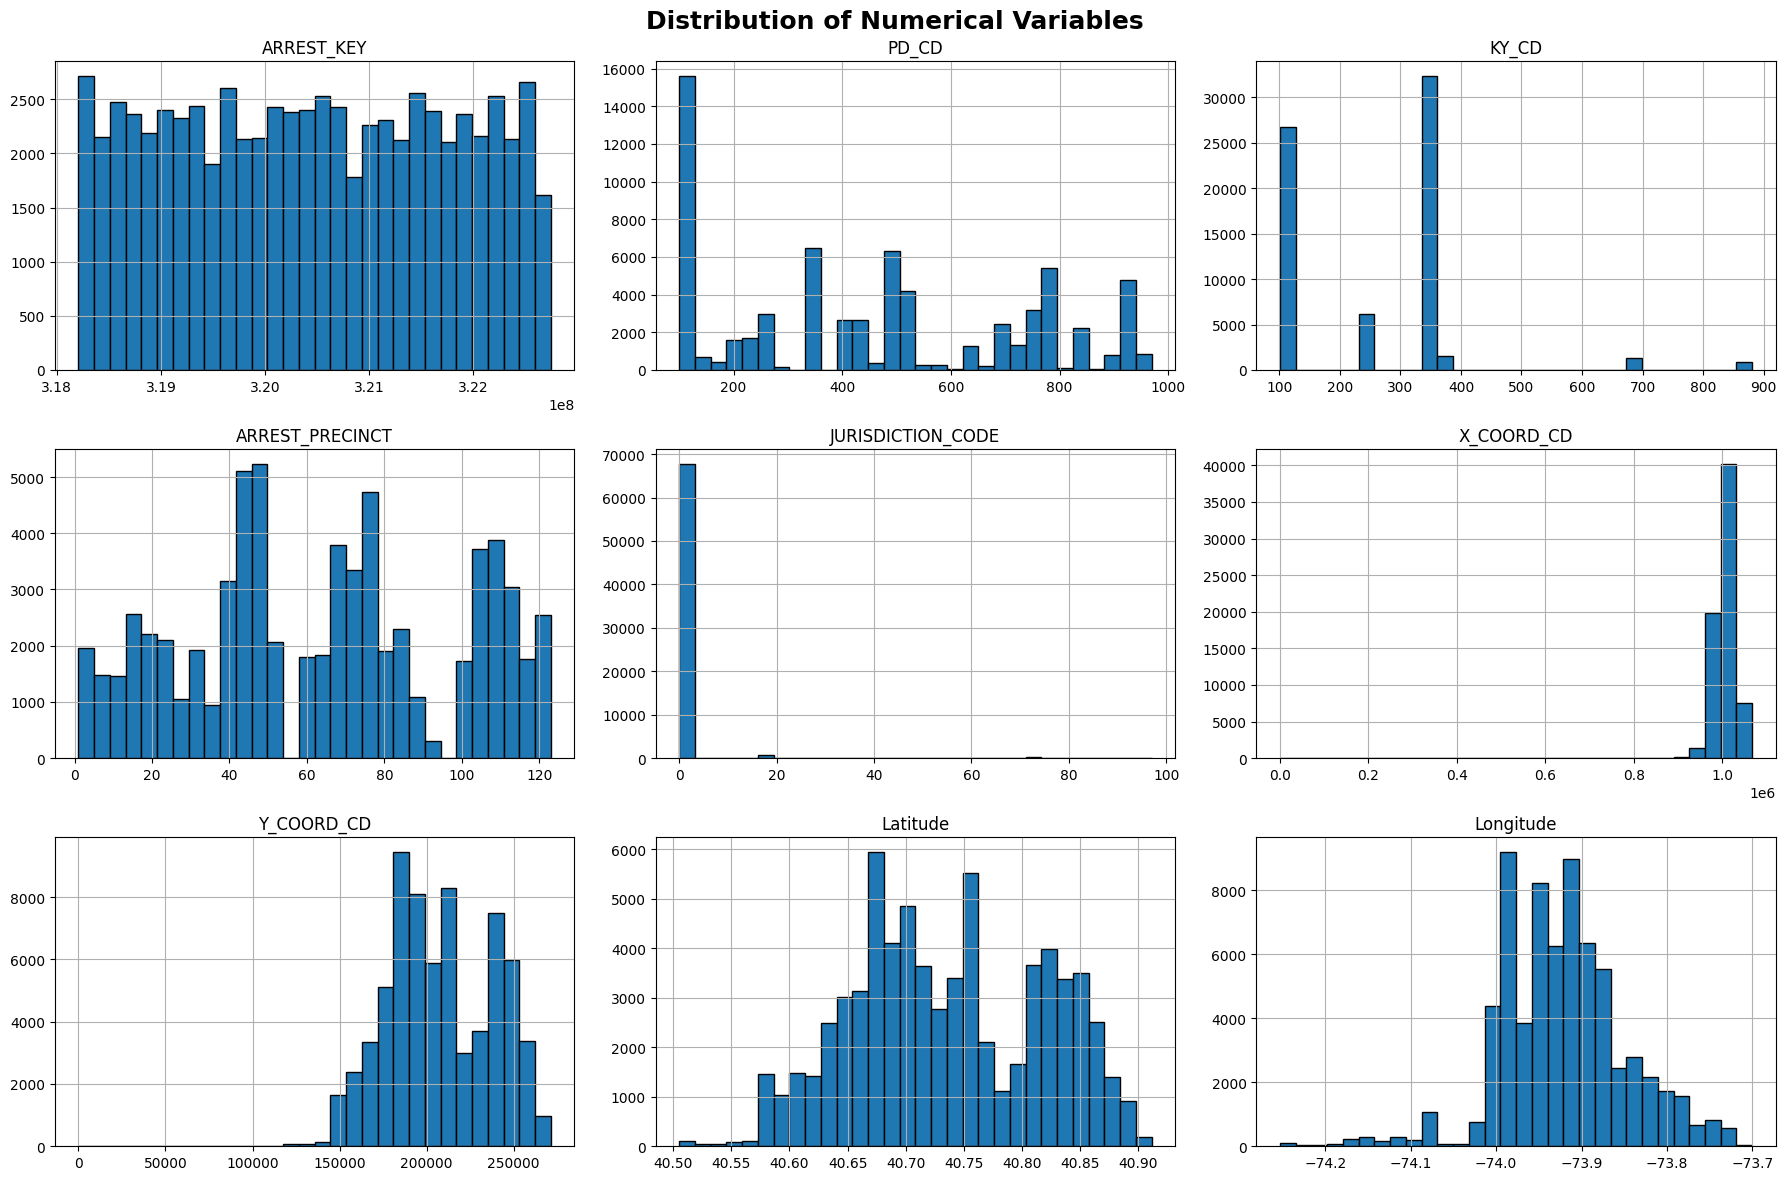

In [19]:
# ============================================================
# Step 17: Univariate Analysis - Numerical Variable Distribution
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print(f"Total Numerical Variables: {len(numerical_cols)}")
print(numerical_cols.tolist())

# Plot histograms
df[numerical_cols].hist(
    figsize=(18, 12),
    bins=30,
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Variables",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# 📊 Step 17: Univariate Analysis – Numerical Variable Distribution

## 📝 Description
In this step, we explored the distribution of all numerical variables in the NYPD Arrest dataset using histograms. This visualization helps us understand the frequency distribution, identify the shape of each variable, detect skewness, assess data spread, and reveal potential outliers or unusual patterns before proceeding to more advanced analyses.

---

## 💻 Code
- Selected all numerical variables.
- Generated histograms for each numerical feature.
- Displayed all distributions in a single figure for easy comparison.

---

## 📊 Output Preview
The output produced histograms for the following numerical variables:

- ARREST_KEY
- PD_CD
- KY_CD
- ARREST_PRECINCT
- JURISDICTION_CODE
- X_COORD_CD
- Y_COORD_CD
- Latitude
- Longitude

---

## 🔍 Observations / Interpretation

- **ARREST_KEY** is fairly evenly distributed since it serves as a unique identifier.
- **PD_CD** and **KY_CD** show clustered distributions, indicating that certain offense codes occur much more frequently than others.
- **ARREST_PRECINCT** displays varying frequencies across precincts, suggesting that arrests are concentrated in specific precincts.
- **JURISDICTION_CODE** is highly right-skewed, with most arrests belonging to a single jurisdiction.
- **X_COORD_CD**, **Y_COORD_CD**, **Latitude**, and **Longitude** exhibit concentrated geographic distributions, reflecting the spatial clustering of arrests within New York City.
- No obvious data entry errors are visible from the histogram distributions, although some variables display skewness that may require further examination.

---

## ⭐ Importance

Examining numerical variable distributions provides an essential understanding of the dataset before statistical analysis and machine learning. Histograms help identify skewness, unusual distributions, potential outliers, and data concentration patterns that may influence feature engineering, modeling, and interpretation.

---

# ➡️ Next Step

## **Step 18: Univariate Analysis – Numerical Variable Boxplots**

In the next step, we will visualize each numerical variable using boxplots. Boxplots provide a concise summary of the data distribution by displaying the median, quartiles, spread, and potential outliers, allowing us to identify extreme observations that may influence statistical analyses and machine learning models.

Total Numerical Variables: 9
['ARREST_KEY', 'PD_CD', 'KY_CD', 'ARREST_PRECINCT', 'JURISDICTION_CODE', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude']


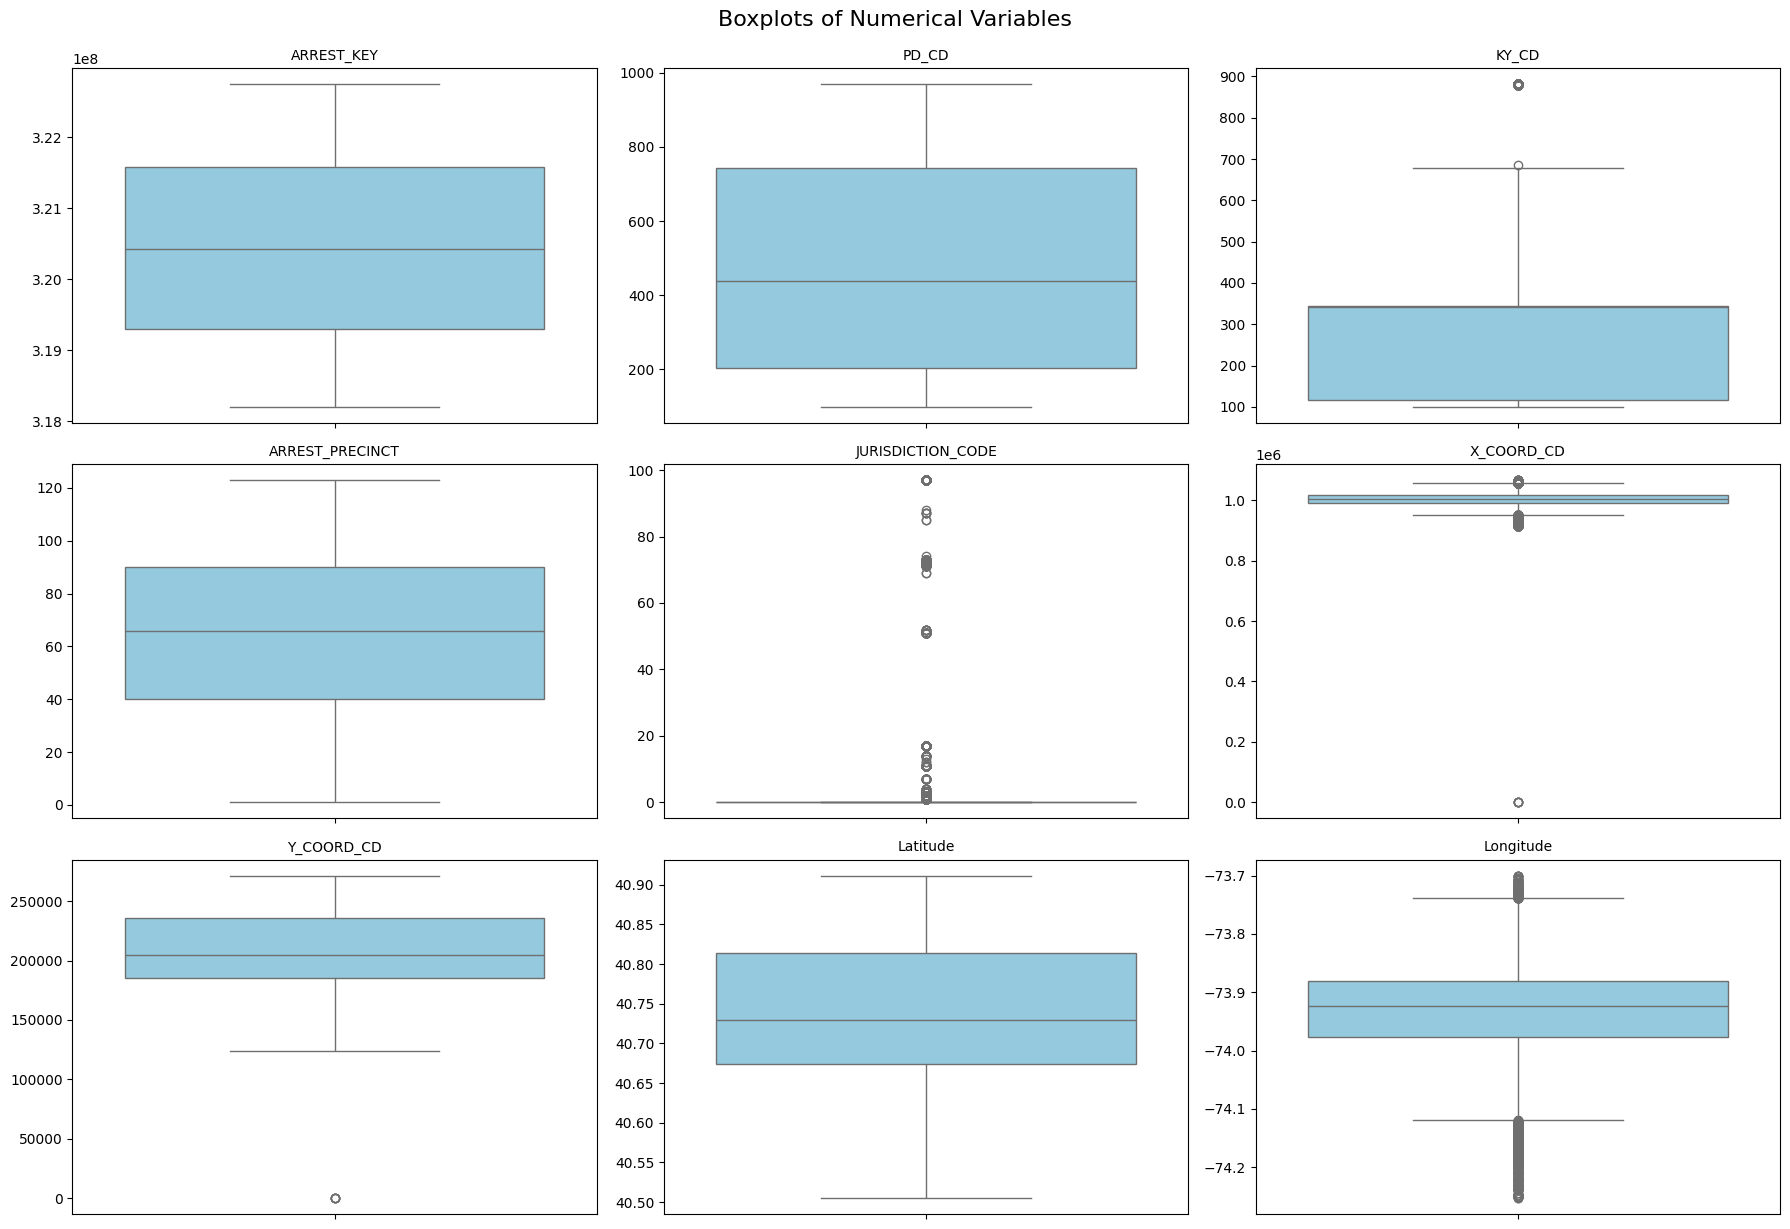

In [20]:
# ============================================================
# Step 18: Univariate Analysis – Numerical Variable Boxplots
# ============================================================

# Select numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print(f"Total Numerical Variables: {len(numerical_columns)}")
print(list(numerical_columns))

# Create boxplots
plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col, fontsize=10)
    plt.ylabel("")
    plt.tight_layout()

plt.suptitle("Boxplots of Numerical Variables", fontsize=16, y=1.02)
plt.show()

# 📦 Step 18: Univariate Analysis – Numerical Variable Boxplots

## 📝 Description
In this step, we visualized all numerical variables using boxplots to examine their distribution, median, interquartile range (IQR), spread, and potential outliers. Boxplots provide a compact summary of each variable and help identify extreme observations that may require further investigation during data preprocessing.

---

## 💻 Code
- Selected all numerical variables.
- Generated boxplots for each numerical feature.
- Displayed all boxplots in a grid for easy comparison.

---

## 📊 Output Preview
The output displays boxplots for the following numerical variables:

- ARREST_KEY
- PD_CD
- KY_CD
- ARREST_PRECINCT
- JURISDICTION_CODE
- X_COORD_CD
- Y_COORD_CD
- Latitude
- Longitude

---

## 🔍 Observations / Interpretation

- **ARREST_KEY** shows a relatively uniform spread without meaningful outliers since it is a unique identifier.
- **PD_CD** and **KY_CD** contain several outliers, indicating that some offense codes occur much less frequently than the majority.
- **ARREST_PRECINCT** has a moderate spread across precincts with no severe outlier issues.
- **JURISDICTION_CODE** displays numerous outliers because most arrests belong to one jurisdiction while only a few belong to others.
- **X_COORD_CD** and **Y_COORD_CD** are concentrated within expected coordinate ranges, with a few extreme observations that may represent unusual arrest locations.
- **Latitude** and **Longitude** exhibit a compact geographic distribution with only a small number of mild outliers, suggesting that most arrests occurred within the expected New York City boundaries.
- Overall, the numerical variables appear reasonable, although several variables contain outliers that will be examined later during the dedicated outlier detection stage.

---

## ⭐ Importance

Boxplots are an important exploratory data analysis tool because they summarize the center, spread, variability, and potential outliers of numerical variables. Identifying these characteristics early helps guide future preprocessing decisions, improves data quality assessment, and supports the development of more reliable statistical and machine learning models.

---

# ➡️ Next Step

## **Step 19: Univariate Analysis – Categorical Variable Frequency Distribution**

In the next step, we will examine the frequency distribution of each categorical variable using count plots. This will help identify the most common categories, detect class imbalances, and provide a better understanding of the categorical characteristics of the NYPD Arrest dataset before proceeding to bivariate analysis.

C:\Users\mapfi\AppData\Local\Temp\ipykernel_13844\3704588543.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


Total Categorical Variables: 10
['ARREST_DATE', 'PD_DESC', 'OFNS_DESC', 'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'Location']


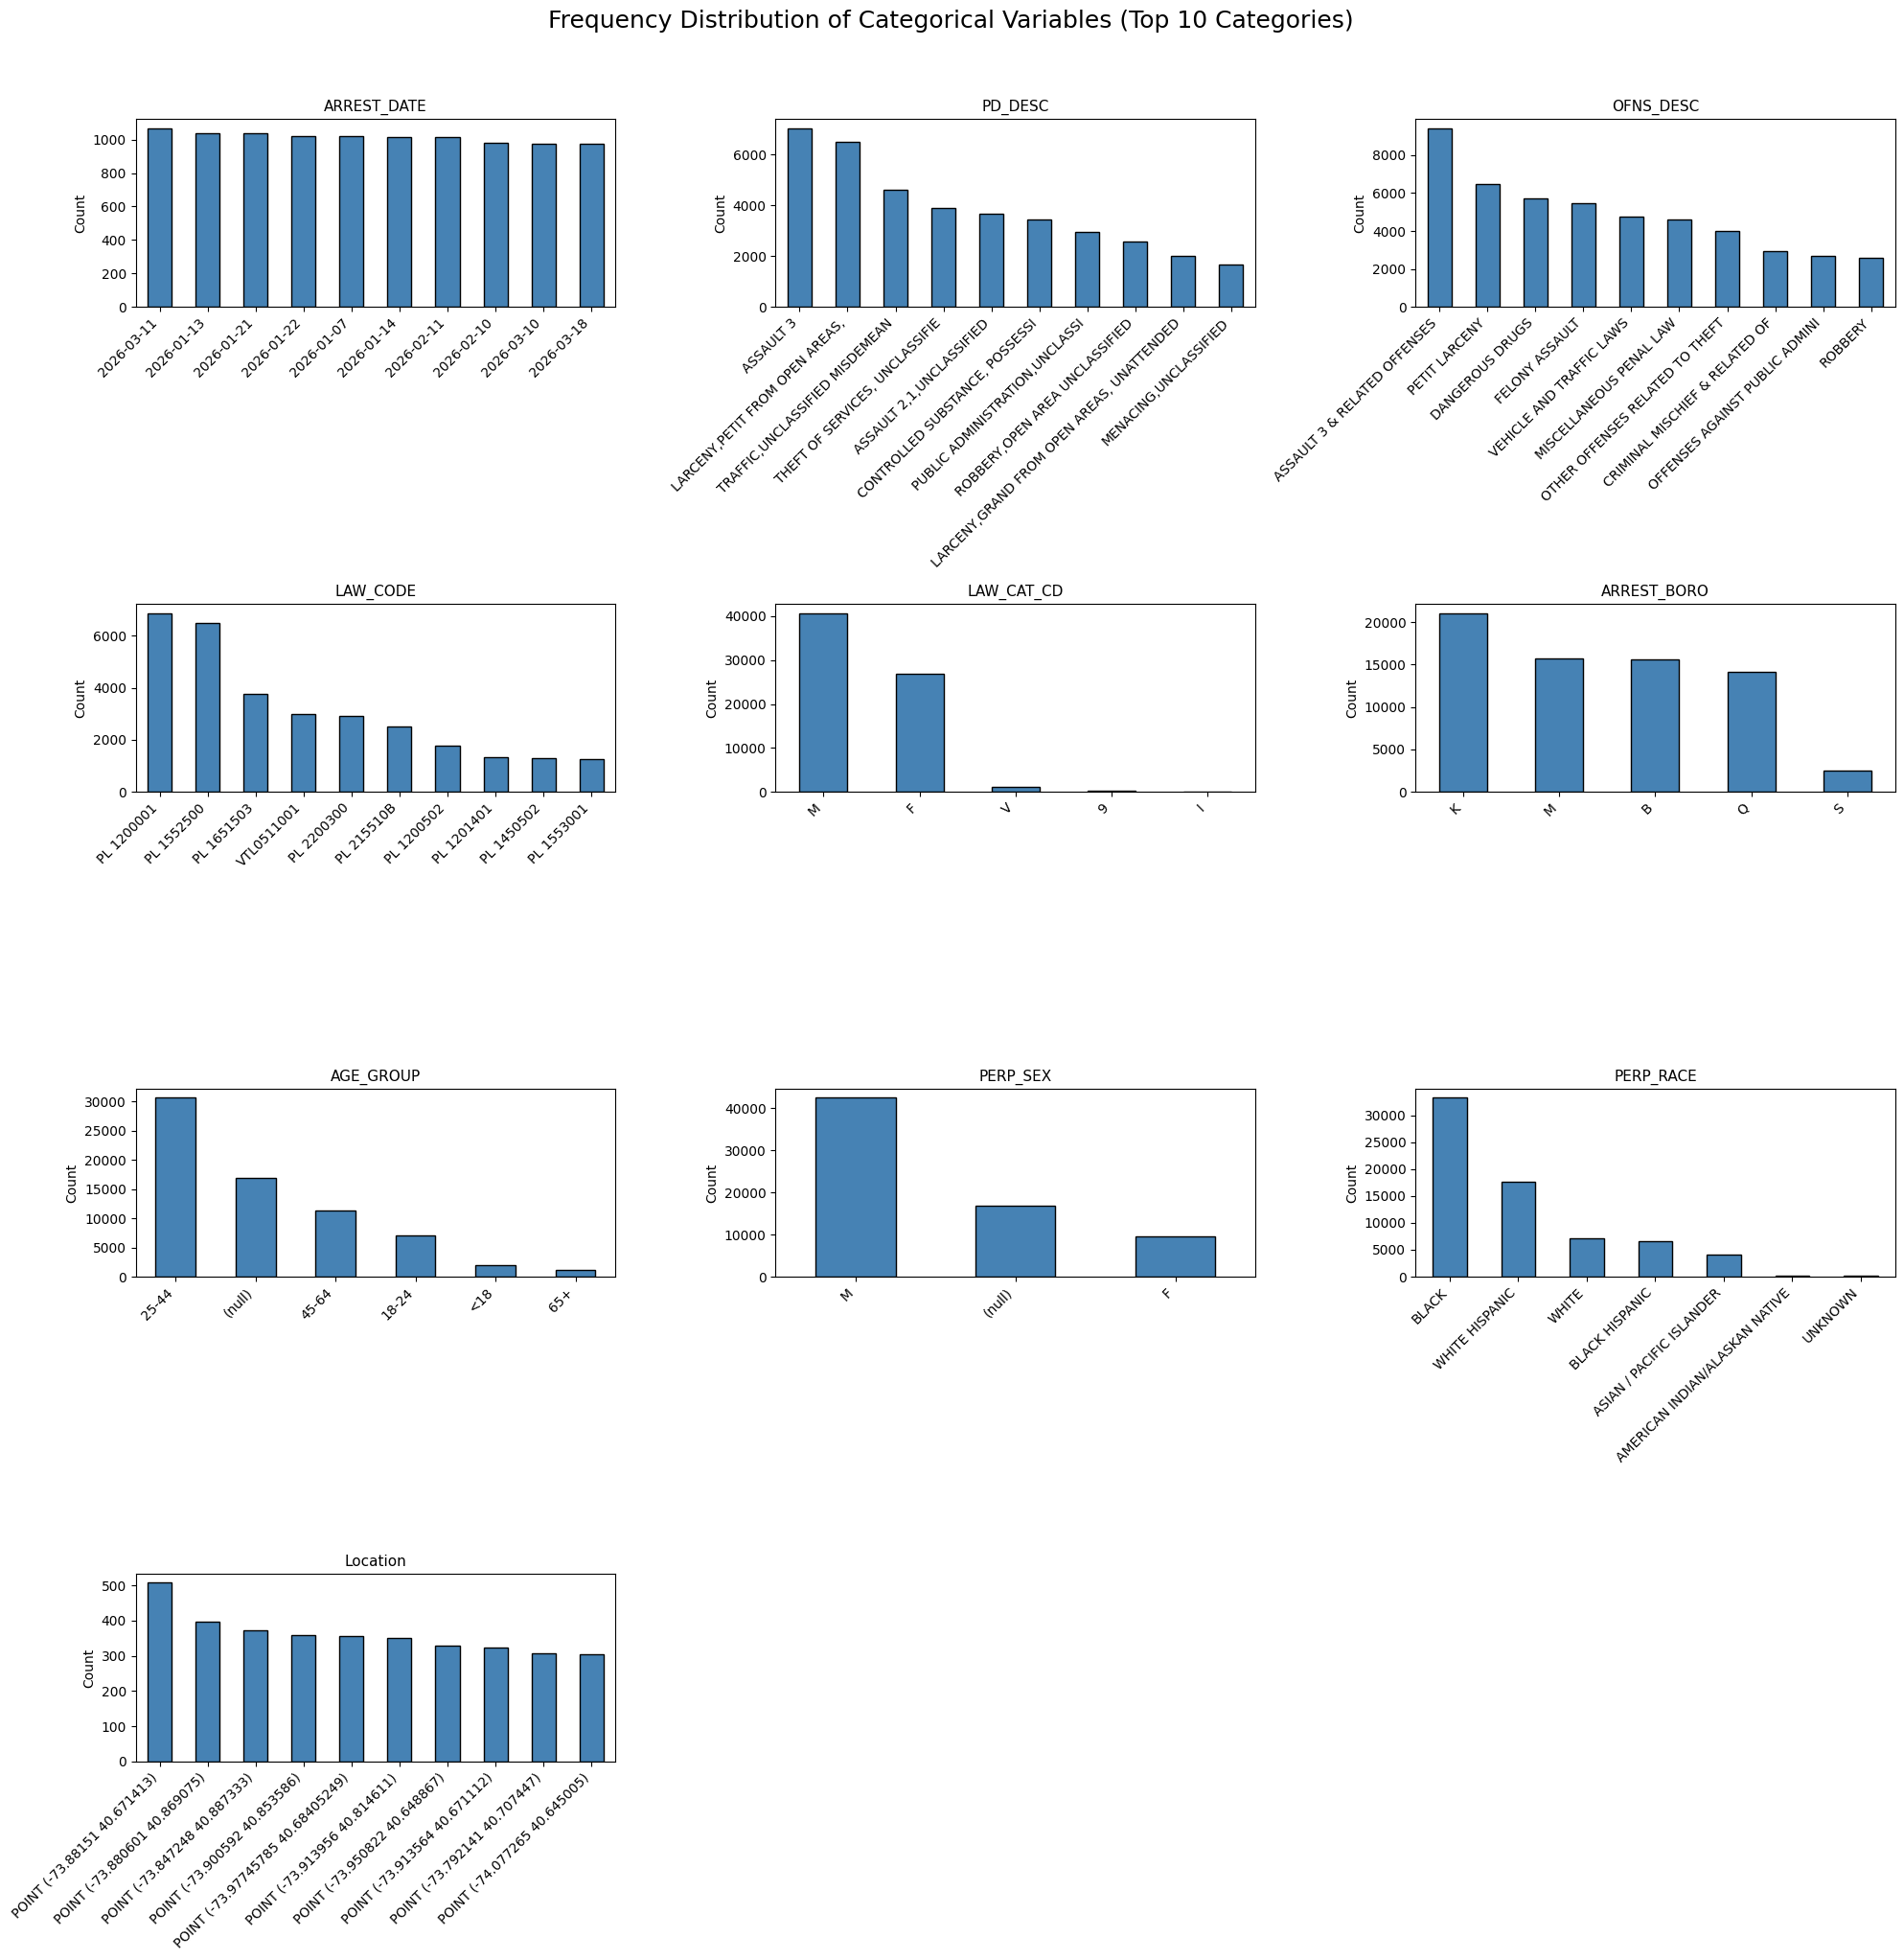

In [21]:
# ============================================================
# Step 19: Univariate Analysis – Categorical Variable Frequency Distribution
# ============================================================

# Select categorical variables
categorical_columns = df.select_dtypes(include=["object"]).columns

print(f"Total Categorical Variables: {len(categorical_columns)}")
print(list(categorical_columns))

# Number of categorical variables
n_cols = 3
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols

# Create figure
plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(n_rows, n_cols, i)

    # Plot top 10 categories only for readability
    df[col].value_counts().head(10).plot(
        kind="bar",
        color="steelblue",
        edgecolor="black"
    )

    plt.title(col, fontsize=11)
    plt.xlabel("")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")

plt.suptitle(
    "Frequency Distribution of Categorical Variables (Top 10 Categories)",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

# 📊 Step 19: Univariate Analysis – Frequency Distribution of Categorical Variables

## 📝 Description
In this step, we examined the frequency distribution of all categorical variables using bar charts. This helps us understand how observations are distributed across different categories, identify the most common classes, detect class imbalances, and gain a better understanding of the structure of the NYPD Arrest dataset.

---

## 💻 Code
- Selected all categorical variables in the dataset.
- Computed the frequency counts for each category.
- Displayed the Top 10 most frequent categories using bar charts to improve readability.

---

## 📊 Output Preview
The output displays bar charts showing the Top 10 most frequent categories for each categorical variable, including:

- ARREST_DATE
- PD_DESC
- OFNS_DESC
- LAW_CODE
- LAW_CAT_CD
- ARREST_BORO
- AGE_GROUP
- PERP_SEX
- PERP_RACE
- Location

---

## 🔍 Observations / Interpretation

- Arrests are distributed across multiple dates, with no single day overwhelmingly dominating the dataset.
- A relatively small number of offense descriptions account for a large proportion of arrests.
- Felonies and misdemeanors represent the majority of arrest classifications, while violations occur less frequently.
- Arrests are concentrated in a few boroughs, indicating geographic differences in arrest activity.
- Individuals aged **25–44** form the largest age group among arrested persons.
- Male suspects account for the majority of arrests.
- Arrests are distributed across several racial groups, with some groups appearing more frequently than others.
- Geographic locations contain many unique coordinate points, although some locations appear repeatedly.

---

## ⭐ Importance

Frequency distribution analysis provides an overall understanding of the categorical variables before moving into deeper exploratory analysis. It helps identify dominant categories, detect imbalanced classes, understand demographic and geographic patterns, and supports informed feature engineering and predictive modeling.

---

# ➡️ Next Step

## **Step 20: Univariate Analysis – Visualize the Relative Proportions (Percentages) of Categorical Variables**

In the next step, we will visualize the relative proportions of each categorical variable using percentage-based charts. Displaying percentages instead of raw counts makes it easier to compare categories across variables of different sizes and provides a clearer understanding of the composition of the dataset.

C:\Users\mapfi\AppData\Local\Temp\ipykernel_13844\2380696880.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()


Total Categorical Variables: 14
['ARREST_KEY', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC', 'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT', 'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'Location']


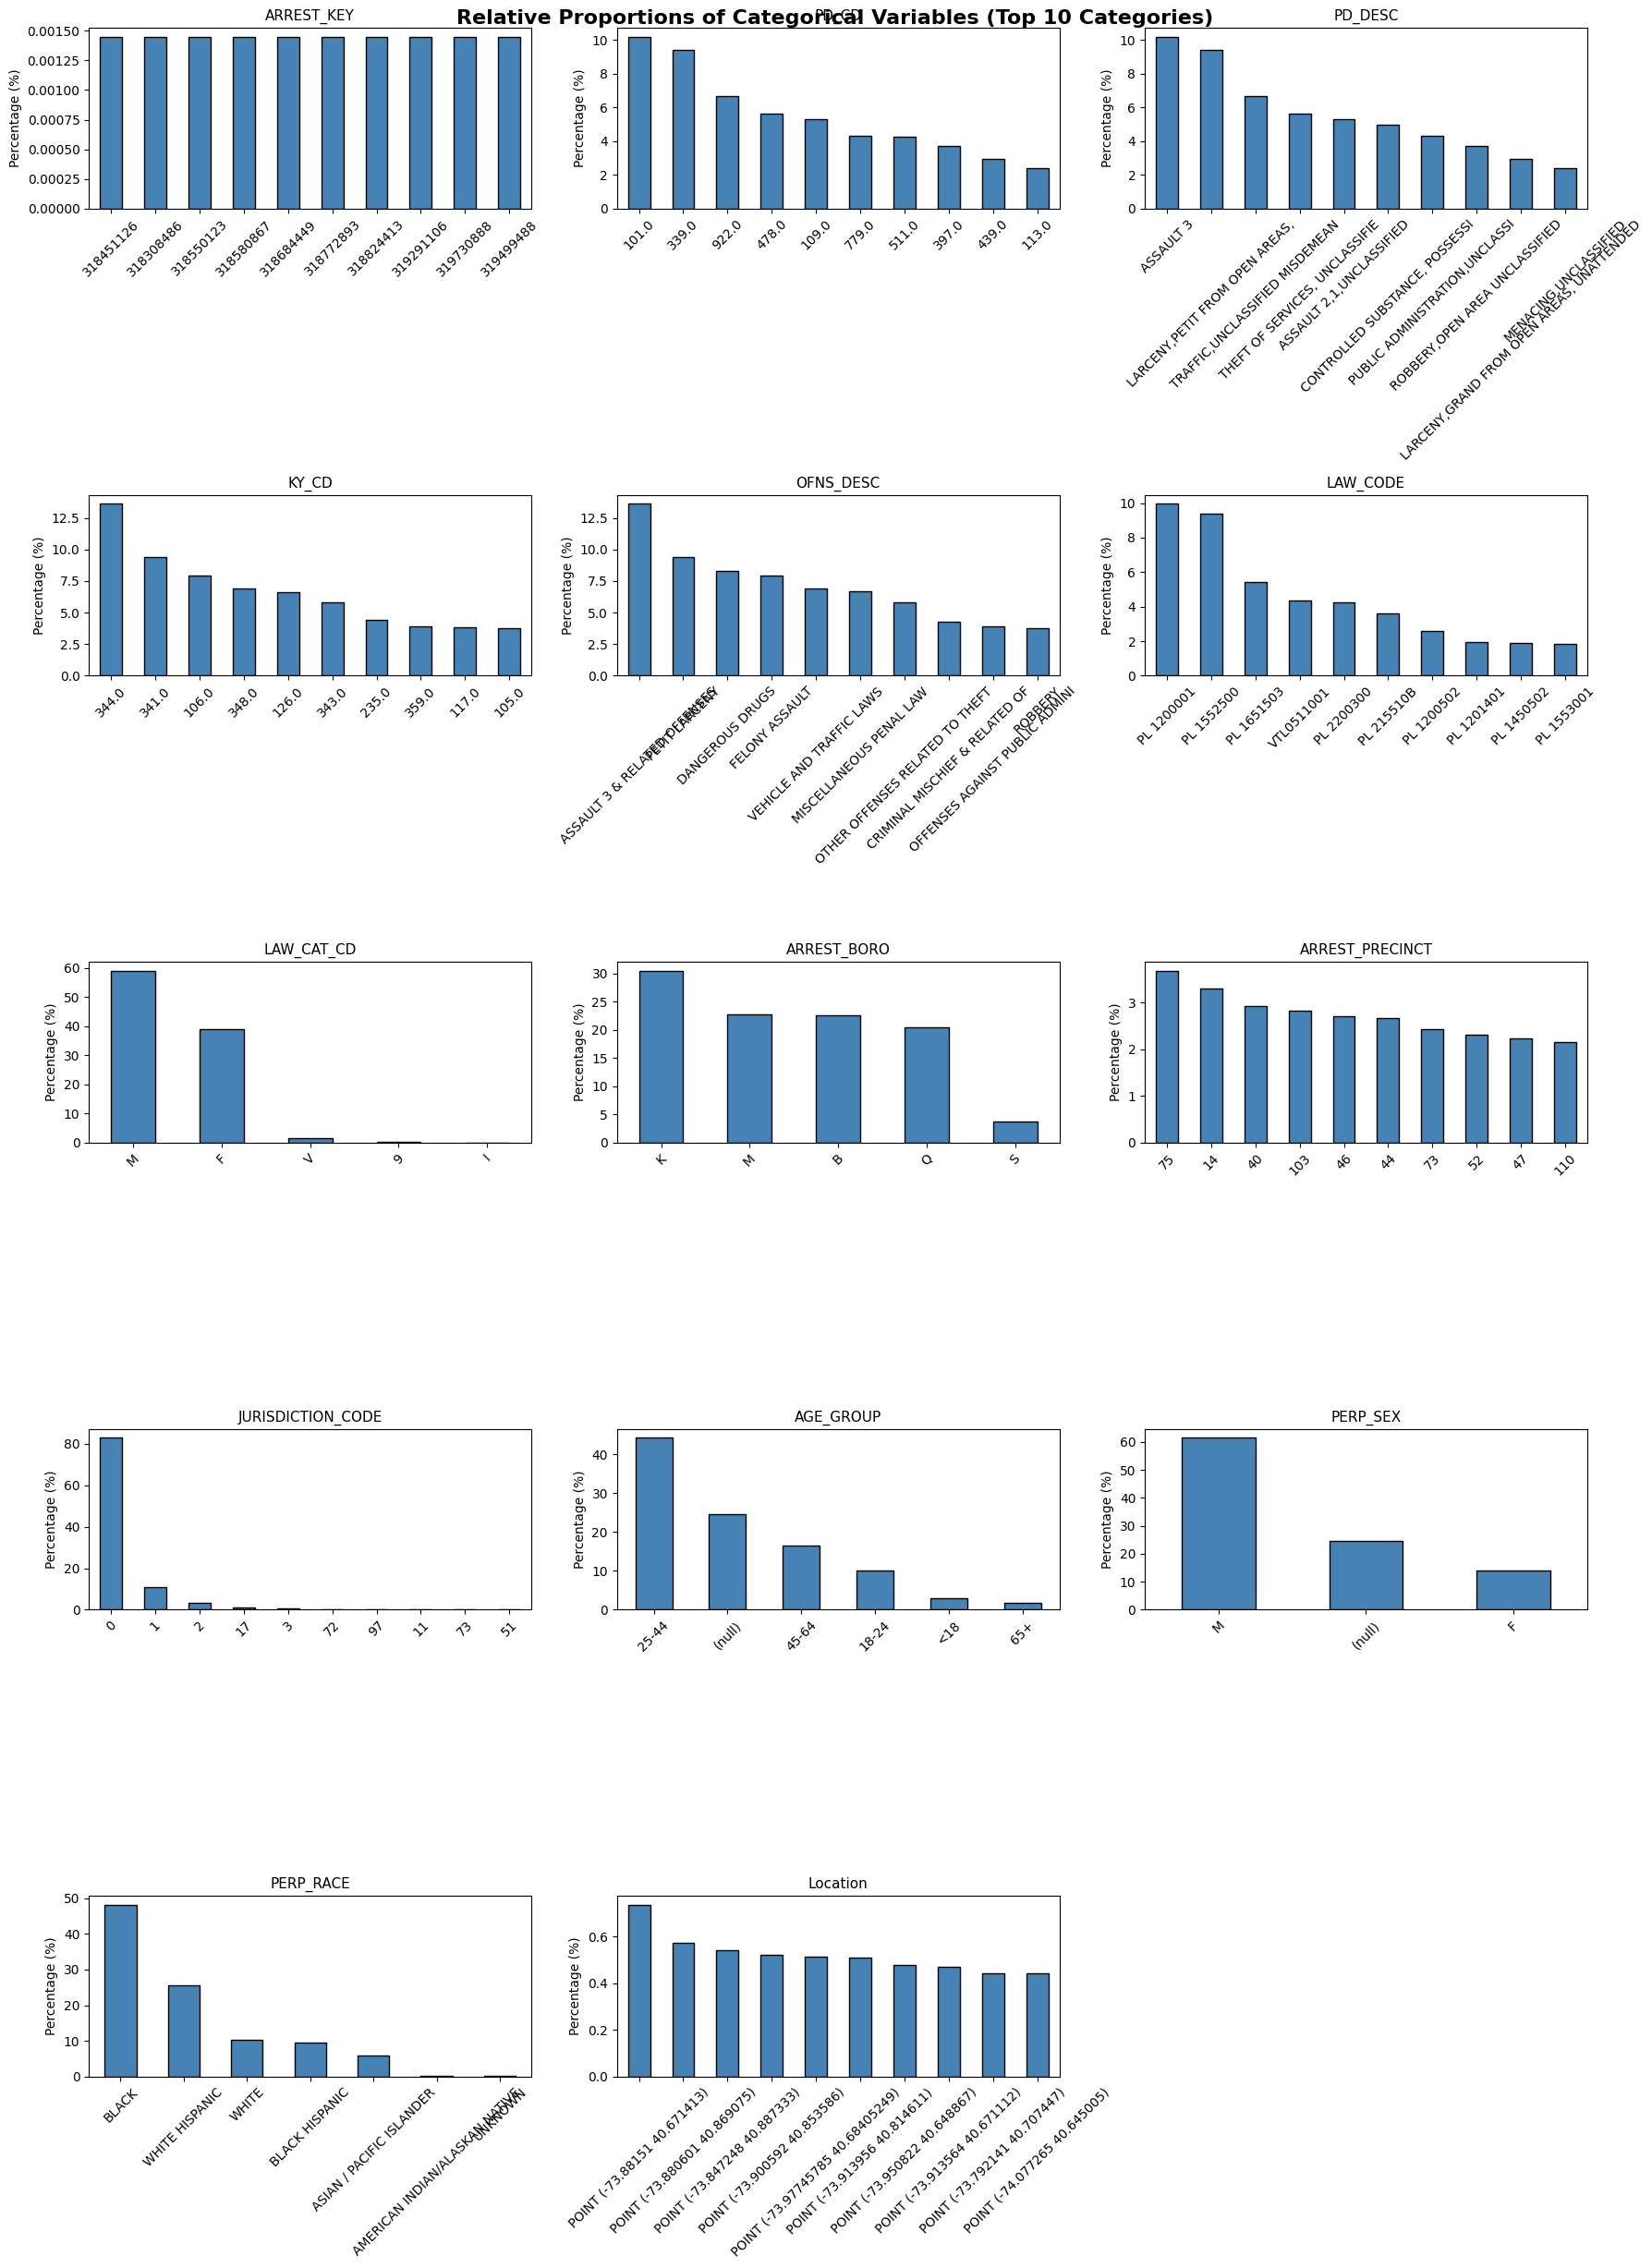

In [22]:
# ============================================================
# Step 20: Univariate Analysis - Relative Proportions of
# Categorical Variables (Top 10 Categories)
# ============================================================

import math
import matplotlib.pyplot as plt

# Select categorical columns
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

print(f"Total Categorical Variables: {len(categorical_cols)}")
print(categorical_cols)

# Create subplot layout
n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Plot percentage distributions
for i, col in enumerate(categorical_cols):

    percent = (
        df_clean[col]
        .value_counts(normalize=True)
        .head(10)
        .sort_values(ascending=False)
        * 100
    )

    percent.plot(
        kind="bar",
        ax=axes[i],
        color="steelblue",
        edgecolor="black"
    )

    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].tick_params(axis="x", rotation=45)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Relative Proportions of Categorical Variables (Top 10 Categories)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# 📊 Step 20: Univariate Analysis – Relative Proportions (Percentages) of Categorical Variables

## 📝 Description

In this step, we visualized the relative proportions (percentages) of the categorical variables using bar charts. Unlike frequency counts, percentage distributions allow for easier comparison between categories regardless of the total number of observations, providing a clearer understanding of the composition of each categorical feature in the NYPD Arrest dataset.

---

## 💻 Code

- Selected all categorical variables automatically.
- Calculated the percentage distribution using normalized value counts.
- Displayed the Top 10 categories for each variable.
- Generated reusable bar charts showing the percentage contribution of each category.

---

## 📊 Output Preview

The output displays percentage-based bar charts for the Top 10 categories of each categorical variable, including:

- ARREST_KEY
- PD_CD
- PD_DESC
- KY_CD
- OFNS_DESC
- LAW_CODE
- LAW_CAT_CD
- ARREST_BORO
- ARREST_PRECINCT
- JURISDICTION_CODE
- AGE_GROUP
- PERP_SEX
- PERP_RACE
- Location

Each chart presents the relative percentage (%) of observations belonging to each category.

---

## 🔍 Observations / Interpretation

- The most common offense descriptions account for a noticeably larger percentage of arrests than less frequent offenses.
- Misdemeanors and felonies represent the overwhelming majority of arrests, while violations contribute only a small percentage.
- Brooklyn (K) records the highest proportion of arrests among the boroughs, followed closely by Manhattan (M), Bronx (B), and Queens (Q).
- Jurisdiction Code **0** dominates the dataset, indicating that most arrests were handled by the primary policing jurisdiction.
- Individuals aged **25–44** make up the largest proportion of arrested persons.
- Male suspects account for the highest percentage of arrests compared to females and unknown values.
- Black suspects represent the largest recorded racial category, followed by White Hispanic and White groups.
- Geographic location coordinates are widely distributed, with no single location contributing a disproportionately large percentage of arrests.

---

## ⭐ Importance

Percentage-based visualizations complement frequency distributions by allowing fair comparisons across categorical variables. They help identify dominant categories, class imbalance, demographic patterns, geographic trends, and overall dataset composition. These insights are valuable for feature engineering, data preprocessing, visualization, and predictive modeling.

---

# ➡️ Next Step

## **Step 21: Bivariate Analysis – Relationships Between Numerical Variables**

In the next step, we will begin bivariate analysis by exploring the relationships between numerical variables using pairwise visualizations and correlation analysis. This will help identify potential associations, trends, and interactions among numerical features before feature engineering and machine learning.

Total Scatter Plots: 4


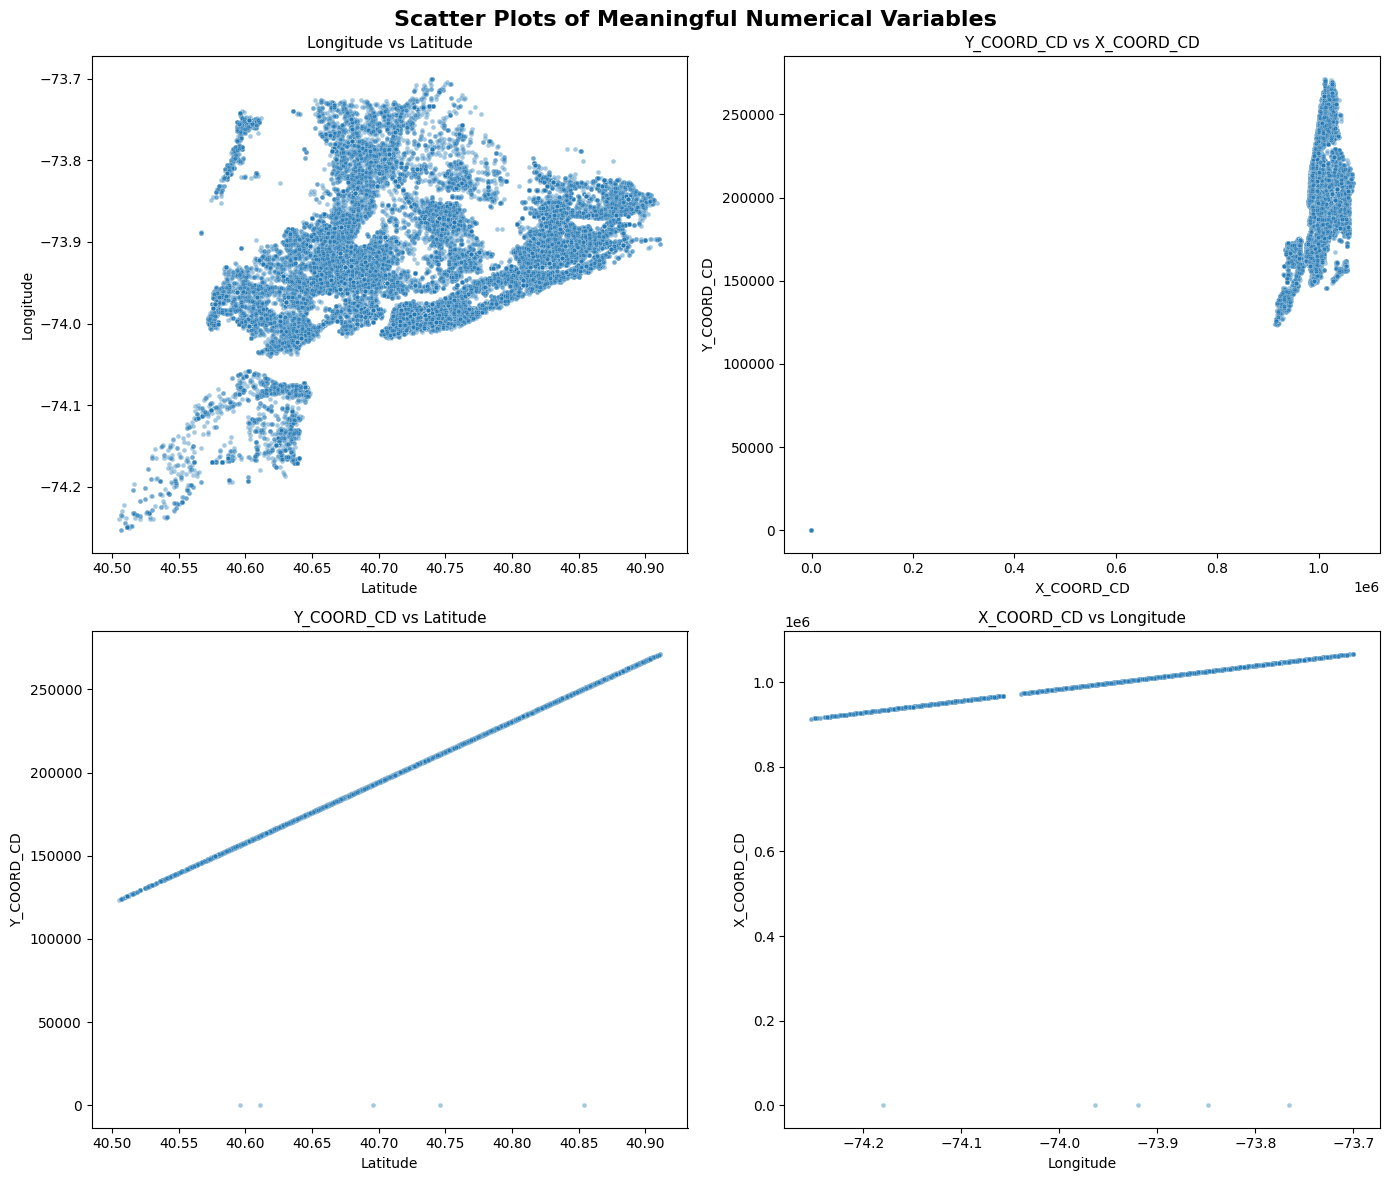

In [23]:
# ==========================================================
# Step 21: Bivariate Analysis - Scatter Plots
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select meaningful continuous numerical variable pairs
scatter_pairs = [
    ("Latitude", "Longitude"),
    ("X_COORD_CD", "Y_COORD_CD"),
    ("Latitude", "Y_COORD_CD"),
    ("Longitude", "X_COORD_CD")
]

print(f"Total Scatter Plots: {len(scatter_pairs)}")

# Plot scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, scatter_pairs):

    sns.scatterplot(
        data=df_clean,
        x=x_col,
        y=y_col,
        alpha=0.4,
        s=12,
        ax=ax
    )

    ax.set_title(f"{y_col} vs {x_col}", fontsize=11)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

plt.suptitle(
    "Scatter Plots of Meaningful Numerical Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Step 21: Bivariate Analysis – Scatter Plots of Meaningful Numerical Variables

### Description
This step explores the relationships between meaningful continuous numerical variables using scatter plots. Variables representing geographic coordinates and spatial locations were selected because they provide interpretable relationships, while identifier and coded variables were excluded since scatter plots are not meaningful for categorical codes or unique identifiers.

### Code
The code generates reusable scatter plots for selected pairs of continuous numerical variables:
- Latitude vs Longitude
- X Coordinate vs Y Coordinate
- Latitude vs Y Coordinate
- Longitude vs X Coordinate

### Output Preview
A grid of four scatter plots displaying the relationships between the selected continuous numerical variables. The plots reveal the spatial distribution of arrest locations and the relationship between geographic coordinates.

### Observations / Interpretation
- The **Latitude vs Longitude** scatter plot clearly outlines the geographical shape of New York City's boroughs, confirming that arrest locations are accurately distributed across the city.
- The **X Coordinate vs Y Coordinate** plot also reflects the spatial arrangement of arrest locations using projected coordinate values.
- The **Latitude vs Y Coordinate** and **Longitude vs X Coordinate** plots show strong positive linear relationships because latitude corresponds directly with Y coordinates, while longitude corresponds directly with X coordinates.
- Only a few isolated observations appear outside the main clusters, suggesting a small number of unusual coordinate values that may warrant further investigation.

### Importance / Use
Scatter plots help identify relationships, trends, clusters, and potential outliers between continuous variables. They provide valuable visual evidence of spatial patterns within the dataset before conducting formal correlation analysis.

### Next Step
**Step 22: Correlation Matrix of Numerical Variables**

In [24]:
# ==========================================================
# Step 22: Correlation Matrix of Numerical Variables
# ==========================================================

# Select all numerical columns
numerical_cols = df_clean.select_dtypes(include=["number"]).columns

print(f"Total Numerical Variables: {len(numerical_cols)}")
print(list(numerical_cols))

# Compute correlation matrix
correlation_matrix = df_clean[numerical_cols].corr()

# Display correlation matrix
print("\nCorrelation Matrix:")
display(correlation_matrix.round(3))

Total Numerical Variables: 4
['X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude']

Correlation Matrix:


,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
X_COORD_CD,1.000,0.274,0.252,0.924
Y_COORD_CD,0.274,1.000,0.998,0.273
Latitude,0.252,0.998,1.000,0.273
Longitude,0.924,0.273,0.273,1.000


# Step 22: Correlation Matrix of Numerical Variables

### Description
This step computes the Pearson correlation matrix for the continuous numerical variables in the dataset. The correlation matrix measures the strength and direction of the linear relationship between pairs of numerical variables, providing a statistical summary before visualizing these relationships with a heatmap.

### Code
The code automatically selects all continuous numerical variables, computes their Pearson correlation coefficients, and displays the correlation matrix.

### Output Preview
A correlation matrix containing the following continuous numerical variables:
- X_COORD_CD
- Y_COORD_CD
- Latitude
- Longitude

Each correlation coefficient ranges from **-1** to **+1**, indicating the strength and direction of the linear relationship between variable pairs.

### Observations / Interpretation
- **Latitude** and **Y_COORD_CD** exhibit an almost perfect positive correlation (**0.998**), indicating that both variables represent nearly the same north-south geographic position.
- **Longitude** and **X_COORD_CD** also show a very strong positive correlation (**0.924**), reflecting the east-west geographic position.
- The remaining variable pairs display relatively weak positive correlations, suggesting limited linear relationships between them.
- These results confirm that the geographic coordinate variables are internally consistent and accurately represent arrest locations across New York City.

### Importance / Use
The correlation matrix helps identify strong and weak linear relationships among continuous numerical variables. It also serves as the foundation for constructing a correlation heatmap, which provides a more intuitive visual representation of these relationships.

### Next Step
**Step 23: Correlation Heatmap of Continuous Numerical Variables**

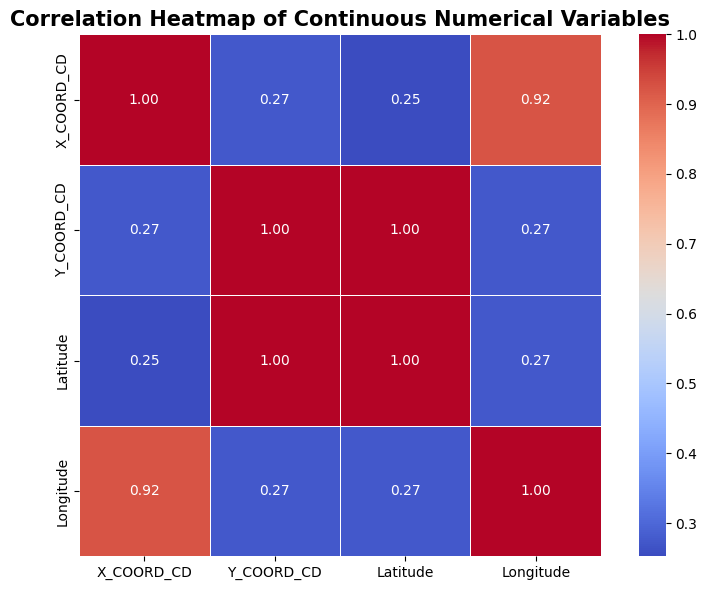

In [25]:
# ==========================================================
# Step 23: Correlation Heatmap of Continuous Numerical Variables
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
correlation_matrix = df_clean.select_dtypes(include=["number"]).corr()

# Create heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title(
    "Correlation Heatmap of Continuous Numerical Variables",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Step 23: Correlation Heatmap of Continuous Numerical Variables

### Description
This step visualizes the Pearson correlation matrix using a heatmap. The heatmap provides a color-coded representation of the strength and direction of linear relationships among the continuous numerical variables.

### Code
The code computes the Pearson correlation matrix for the continuous numerical variables and displays it as an annotated heatmap using Seaborn.

### Output Preview
A heatmap showing the correlation coefficients between:
- X_COORD_CD
- Y_COORD_CD
- Latitude
- Longitude

Each cell is color-coded based on the strength of the correlation, with the exact coefficient displayed in the center.

### Observations / Interpretation
- **Y_COORD_CD** and **Latitude** exhibit an almost perfect positive correlation (≈ 1.00), indicating they represent the same north-south geographic location.
- **X_COORD_CD** and **Longitude** also show a very strong positive correlation (≈ 0.92), representing the east-west geographic location.
- The remaining variable pairs have relatively weak positive correlations (≈ 0.25–0.27), suggesting limited linear relationships.
- No strong negative correlations are observed among the continuous numerical variables.

### Importance / Use
The correlation heatmap provides an intuitive visual summary of relationships between continuous numerical variables. It helps identify highly correlated features, understand data structure, and prepares the dataset for further exploratory analysis and feature evaluation.

### Next Step
**Step 24: Numerical vs Categorical Analysis**

Compare continuous numerical variables across categorical groups using boxplots (and violin plots where appropriate) to understand how numerical distributions differ among categories.

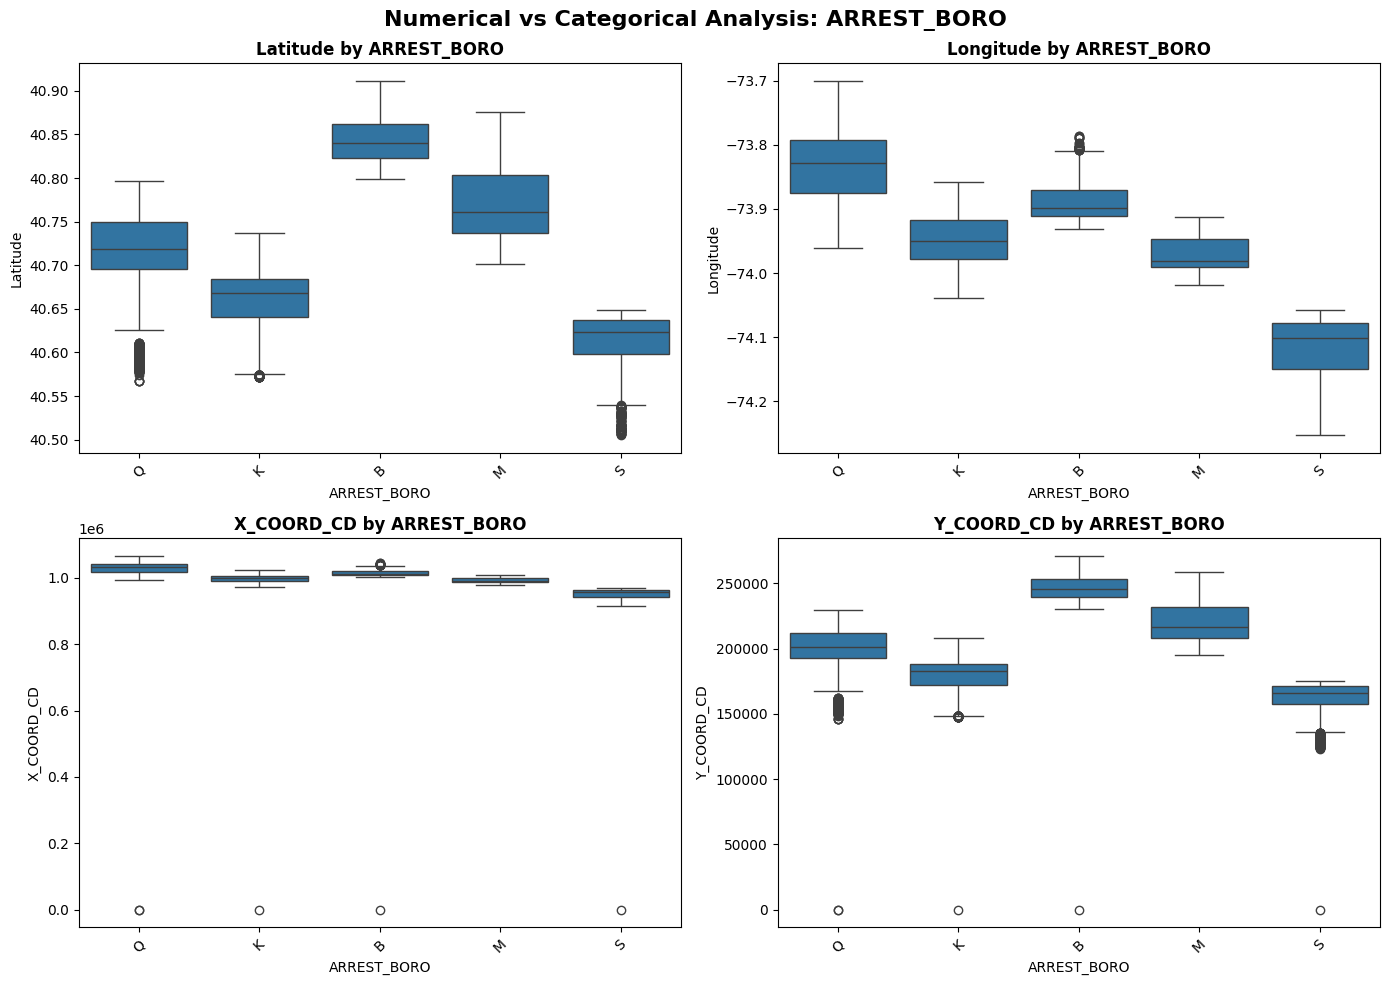

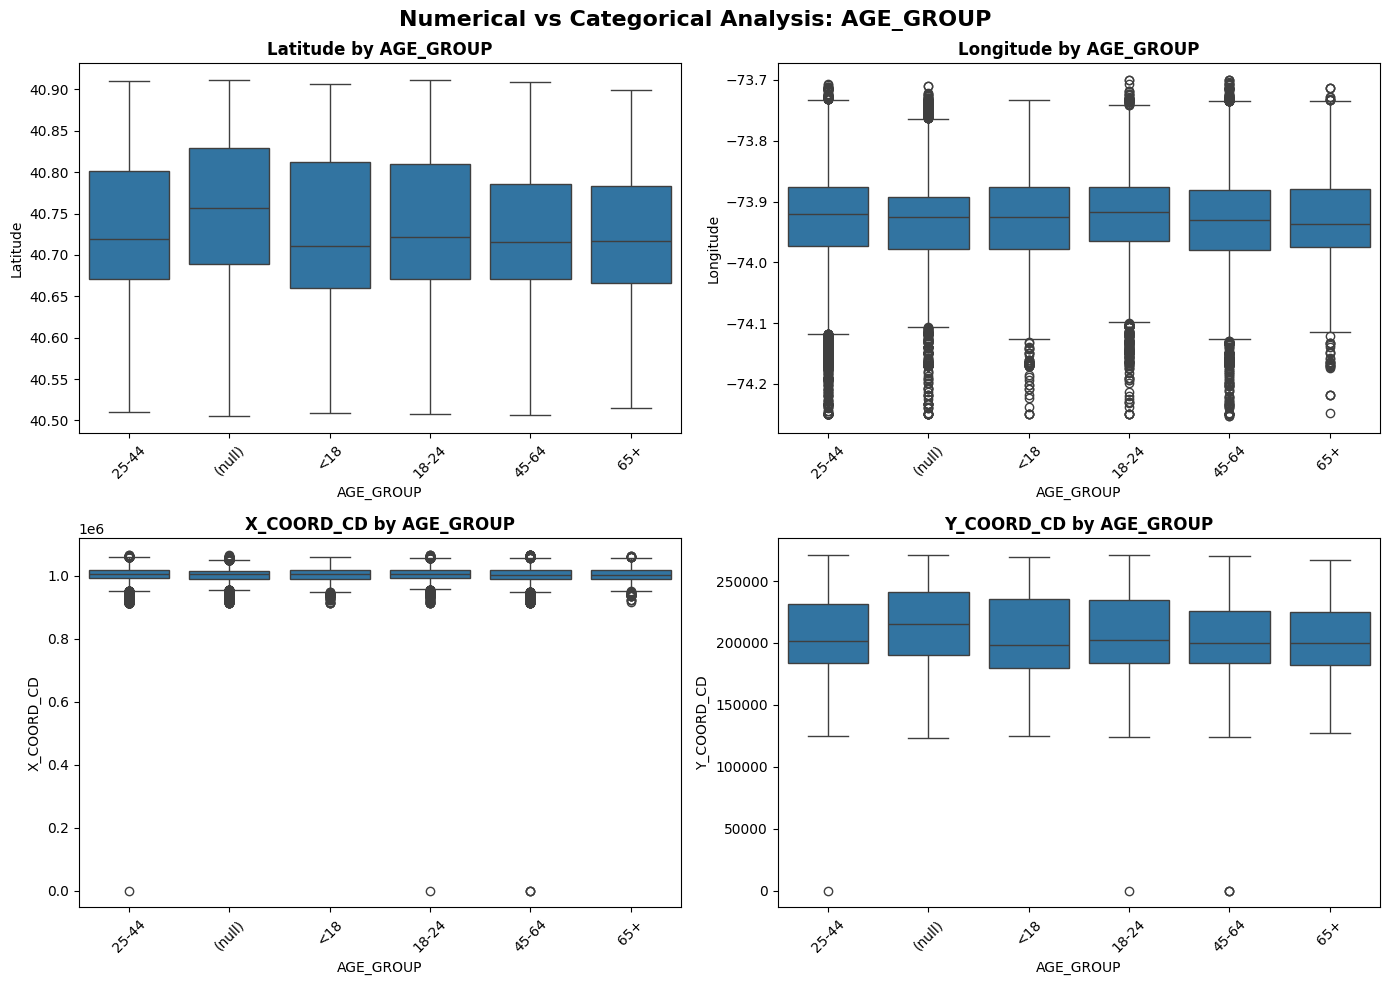

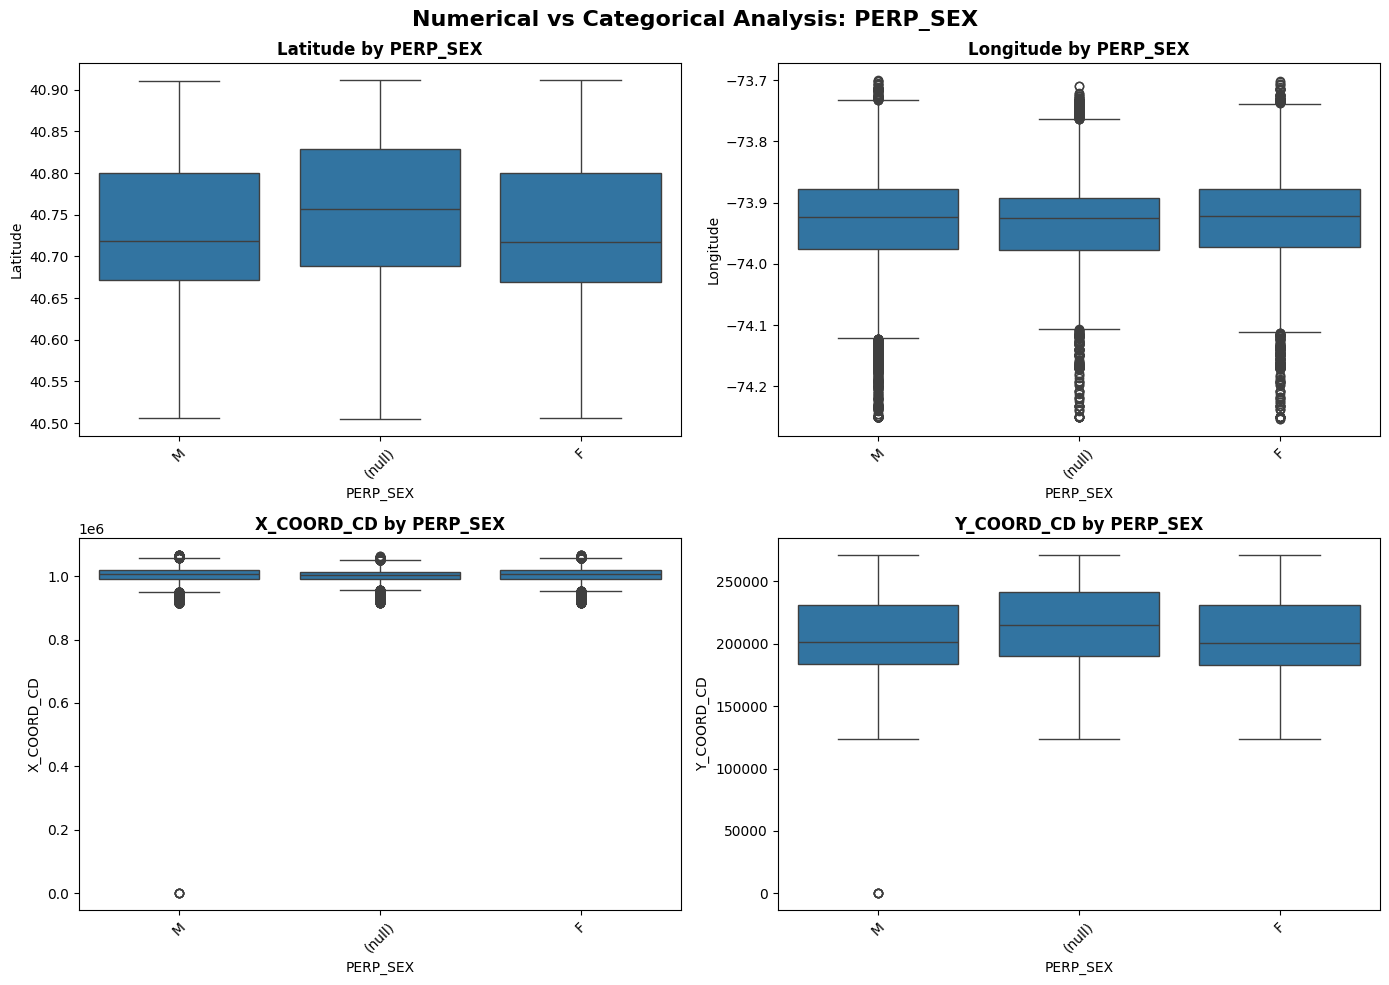

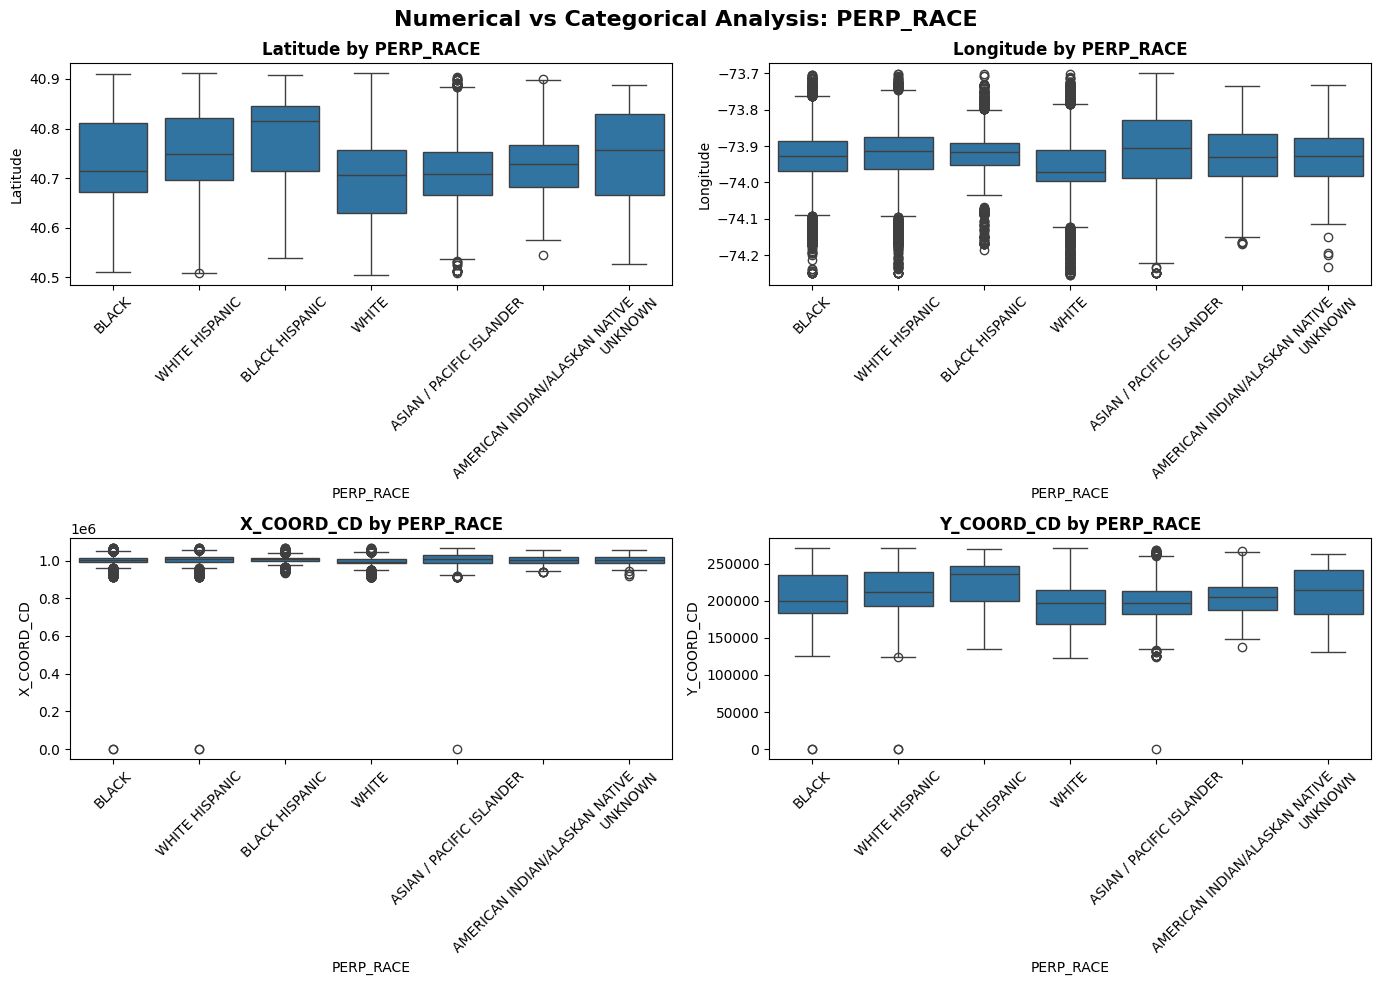

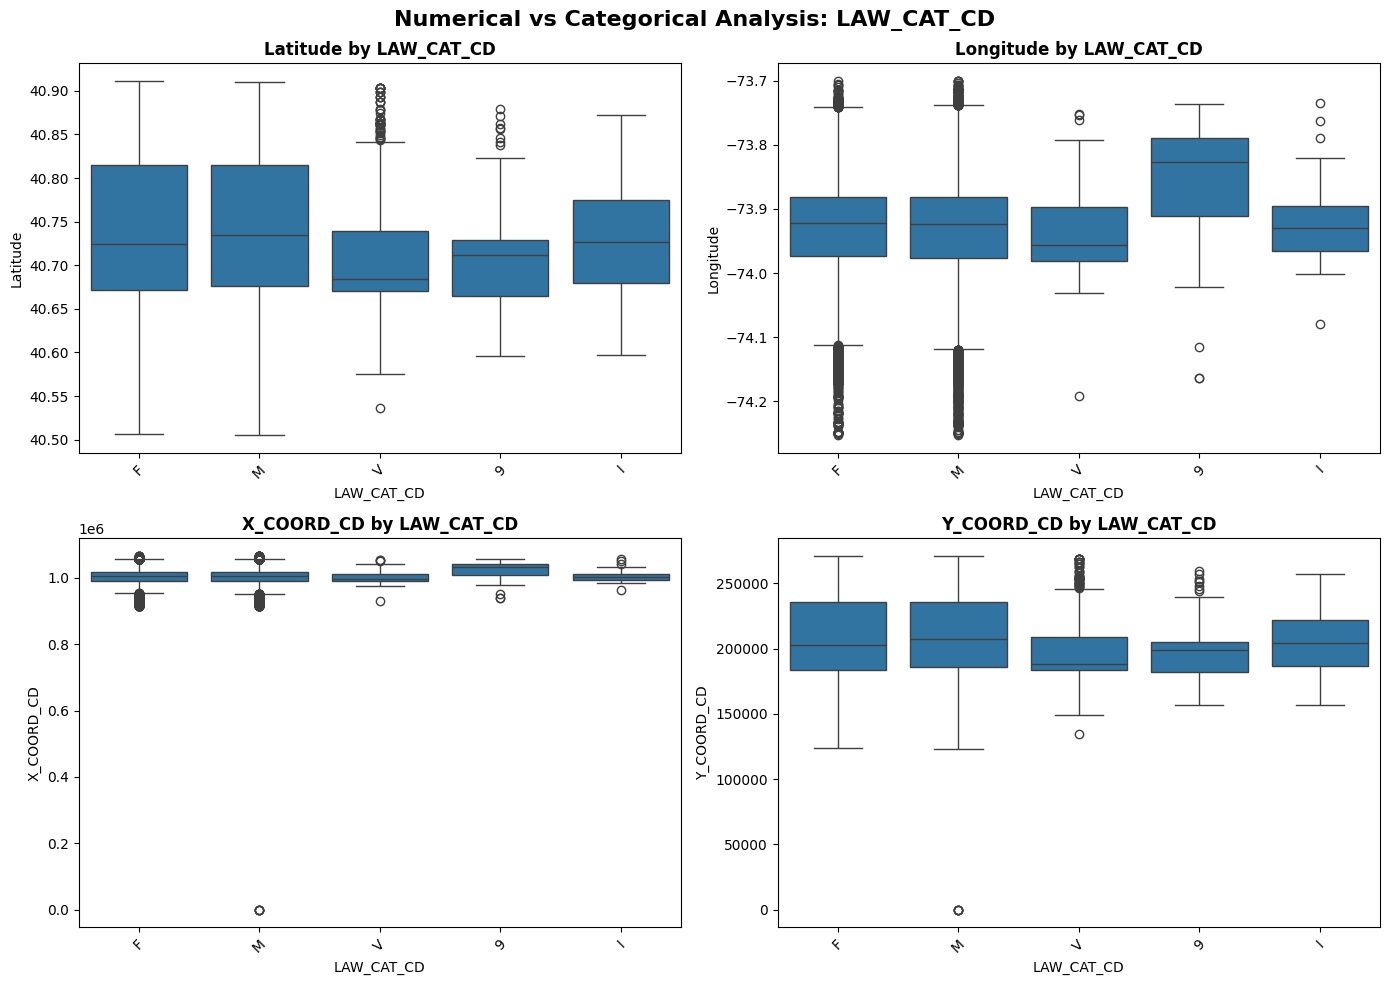

In [26]:
# ==========================================================
# Step 24: Numerical vs Categorical Analysis (Reusable)
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import math

# Continuous numerical variables
numerical_cols = [
    "Latitude",
    "Longitude",
    "X_COORD_CD",
    "Y_COORD_CD"
]

# Useful categorical variables
categorical_cols = [
    "ARREST_BORO",
    "AGE_GROUP",
    "PERP_SEX",
    "PERP_RACE",
    "LAW_CAT_CD"
]

# Loop through each categorical variable
for cat_col in categorical_cols:

    n_cols = 2
    n_rows = math.ceil(len(numerical_cols) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(14, 5 * n_rows)
    )

    axes = axes.flatten()

    for i, num_col in enumerate(numerical_cols):

        sns.boxplot(
            data=df_clean,
            x=cat_col,
            y=num_col,
            ax=axes[i]
        )

        axes[i].set_title(
            f"{num_col} by {cat_col}",
            fontsize=12,
            fontweight="bold"
        )

        axes[i].tick_params(axis="x", rotation=45)

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(
        f"Numerical vs Categorical Analysis: {cat_col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

# Step 24: Numerical vs Categorical Analysis (Boxplots)

### Description
This step explores the relationship between continuous numerical variables and important categorical variables using boxplots. The analysis helps identify differences in distributions, medians, variability, and potential outliers across different categories. It provides an initial understanding of whether categorical groups may influence the numerical features.

### Code
```python
# (Insert the reusable Step 24 code here)
```

### Output Summary
- Generated boxplots comparing Latitude, Longitude, X_COORD_CD, and Y_COORD_CD across:
  - ARREST_BORO
  - AGE_GROUP
  - PERP_SEX
  - PERP_RACE
  - LAW_CAT_CD
- Each categorical variable produced a separate figure containing four boxplots.
- The plots displayed the median, interquartile range (IQR), spread, and potential outliers for each numerical variable.

### Observations / Interpretation
- Geographic variables (Latitude, Longitude, X_COORD_CD, and Y_COORD_CD) showed noticeable differences across arrest boroughs, reflecting the distinct geographical locations of each borough.
- Age groups exhibited similar distributions, suggesting that arrests across age categories are spread throughout similar geographic areas.
- Male and female suspects showed broadly comparable geographic distributions, with only minor differences in medians and variability.
- Some racial categories displayed slight shifts in the geographical distributions, although substantial overlap existed between groups.
- Differences across offense severity categories (LAW_CAT_CD) were relatively modest, indicating that felonies, misdemeanors, and violations occur throughout similar geographic regions.
- Several boxplots contained outliers, representing arrests recorded outside the main concentration of observations or uncommon geographic locations.

### Importance / Use
- Helps determine whether categorical variables influence the distribution of continuous numerical variables.
- Detects differences in central tendency, variability, and spread across groups.
- Identifies potential outliers that may require further investigation.
- Provides valuable insights before feature engineering and predictive modeling.
- Supports better understanding of how demographic, legal, and geographic factors relate to arrest locations.

### Next Step
Step 25: Categorical vs Categorical Analysis (Cross-tabulation / Contingency Tables and Heatmaps) to examine relationships between categorical variables before moving into feature engineering and modeling.

Selected Categorical Variables: ['ARREST_BORO', 'LAW_CAT_CD', 'PERP_SEX', 'PERP_RACE', 'AGE_GROUP']

Total Pairs: 10


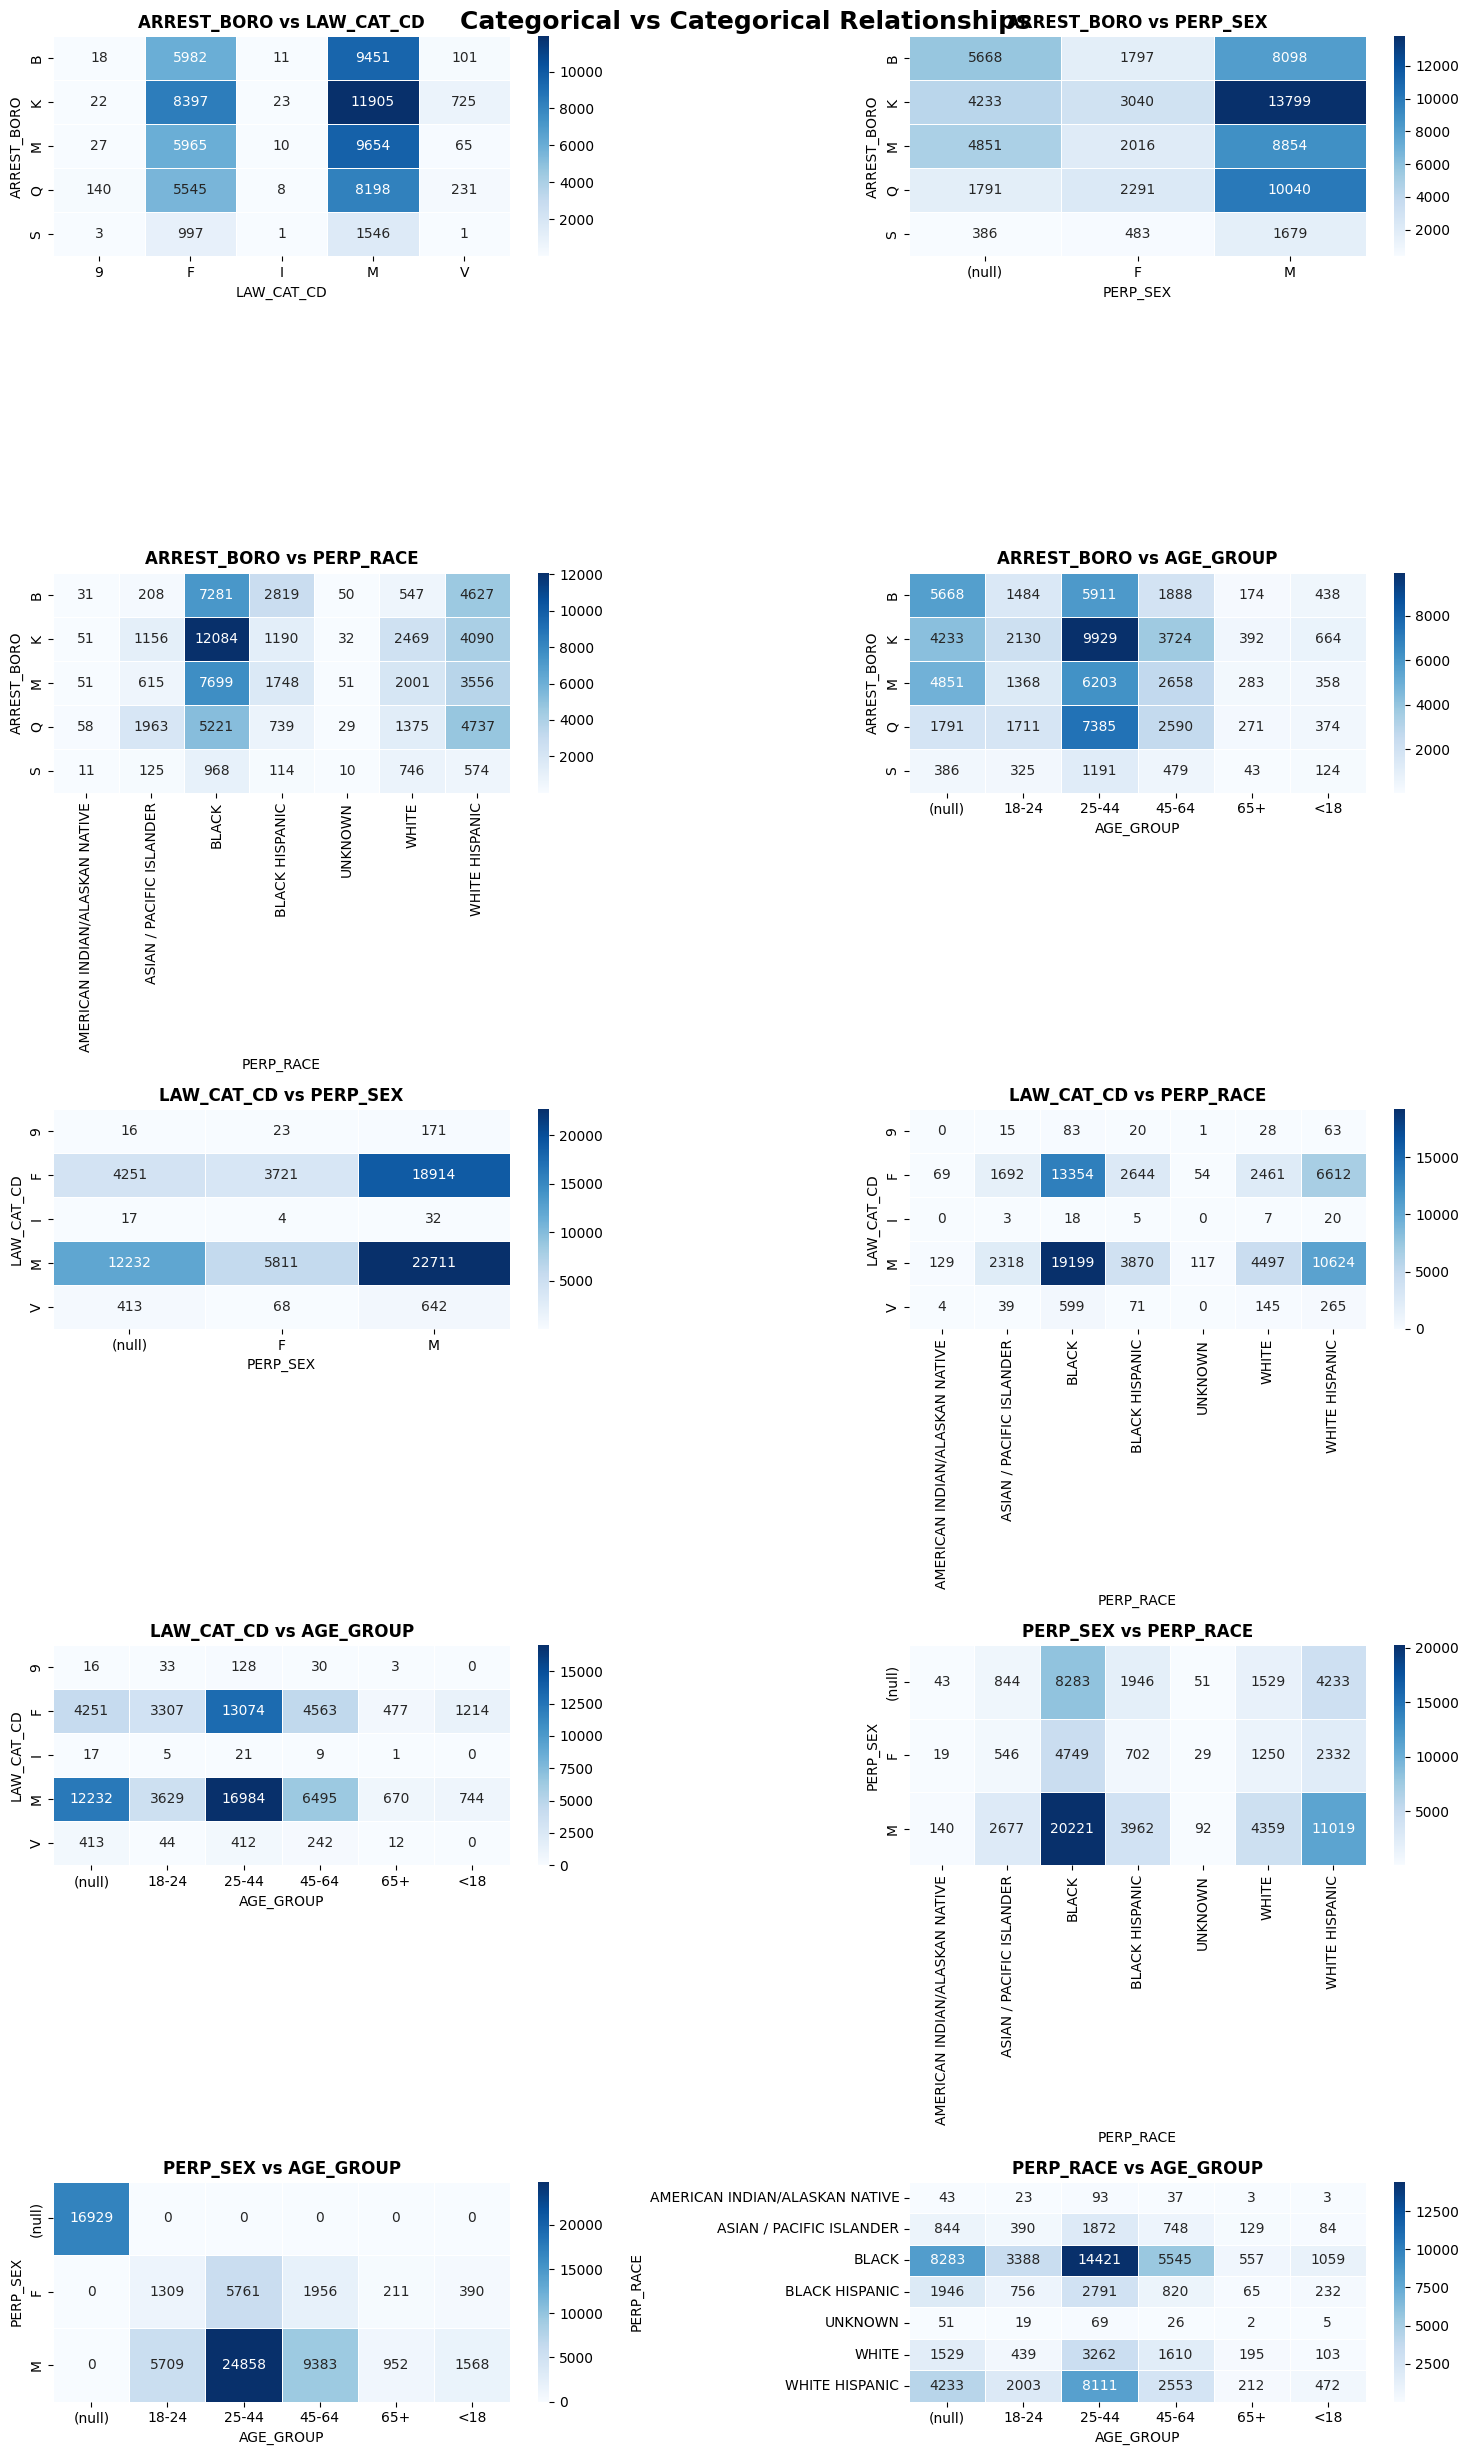

In [27]:
# ==========================================================
# Step 25: Categorical vs Categorical Analysis
# (Reusable Code)
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# ----------------------------------------------------------
# Select important categorical variables
# ----------------------------------------------------------

categorical_cols = [
    "ARREST_BORO",
    "LAW_CAT_CD",
    "PERP_SEX",
    "PERP_RACE",
    "AGE_GROUP"
]

print(f"Selected Categorical Variables: {categorical_cols}")

# ----------------------------------------------------------
# Create all unique variable pairs
# ----------------------------------------------------------

pairs = []

for i in range(len(categorical_cols)):
    for j in range(i + 1, len(categorical_cols)):
        pairs.append((categorical_cols[i], categorical_cols[j]))

print(f"\nTotal Pairs: {len(pairs)}")

# ----------------------------------------------------------
# Plot Heatmaps
# ----------------------------------------------------------

cols = 2
rows = math.ceil(len(pairs) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()

for ax, (var1, var2) in zip(axes, pairs):

    cross_tab = pd.crosstab(df_clean[var1], df_clean[var2])

    sns.heatmap(
        cross_tab,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(f"{var1} vs {var2}", fontsize=12, fontweight="bold")

# Remove unused axes
for ax in axes[len(pairs):]:
    fig.delaxes(ax)

plt.suptitle(
    "Categorical vs Categorical Relationships",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Step 25: Categorical vs Categorical Analysis (Cross-Tabulation Heatmaps)

### Description
This step explores the relationships between important categorical variables using cross-tabulations visualized as heatmaps. The heatmaps display the frequency of observations for each category combination, making it easier to identify dominant patterns, associations, and imbalances among categorical features.

### Code
```python
# (Insert the reusable Step 25 code here)
```

### Output Summary
- Generated cross-tabulation heatmaps for the following categorical variable pairs:
  - ARREST_BORO vs LAW_CAT_CD
  - ARREST_BORO vs PERP_SEX
  - ARREST_BORO vs PERP_RACE
  - ARREST_BORO vs AGE_GROUP
  - LAW_CAT_CD vs PERP_SEX
  - LAW_CAT_CD vs PERP_RACE
  - LAW_CAT_CD vs AGE_GROUP
  - PERP_SEX vs PERP_RACE
  - PERP_SEX vs AGE_GROUP
  - PERP_RACE vs AGE_GROUP
- Each heatmap displays the frequency count for every category combination, with darker colors representing higher frequencies.

### Observations / Interpretation
- Arrest counts varied noticeably across boroughs, with some boroughs recording substantially higher arrest frequencies than others.
- Felony (F) and Misdemeanor (M) offenses accounted for the majority of arrests across nearly all demographic groups, while Violations (V) were considerably less frequent.
- Male suspects represented the largest proportion of arrests regardless of offense category or borough.
- Black and White Hispanic suspects accounted for a large share of arrests across most offense categories, reflecting the overall distribution observed in the dataset.
- Individuals aged **25–44** formed the largest arrest group across boroughs and offense classifications, followed by the **45–64** and **18–24** age groups.
- The heatmaps clearly highlighted category combinations with the highest concentrations of arrests, providing an intuitive overview of relationships between demographic and legal variables.

### Importance / Use
- Identifies associations between categorical variables before predictive modeling.
- Reveals dominant category combinations and potential class imbalances.
- Helps detect patterns that may influence feature engineering and model performance.
- Supports informed feature selection for classification and clustering tasks.
- Provides an easy-to-interpret visual summary of categorical relationships within the dataset.

### Next Step
Step 26: Multicollinearity Analysis (Variance Inflation Factor - VIF) to evaluate the degree of correlation among continuous predictor variables and identify any multicollinearity before feature engineering and model development.

In [28]:
# ==========================================================
# Step 26: Multicollinearity Analysis (Variance Inflation Factor)
# Reusable Code
# ==========================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Select only continuous numerical variables
# ----------------------------------------------------------

continuous_cols = [
    "X_COORD_CD",
    "Y_COORD_CD",
    "Latitude",
    "Longitude"
]

# Create a copy
vif_data = df_clean[continuous_cols].copy()

# Remove missing values
vif_data = vif_data.dropna()

print(f"Total Variables for VIF: {len(vif_data.columns)}")
print(list(vif_data.columns))

# ----------------------------------------------------------
# Calculate VIF
# ----------------------------------------------------------

vif = pd.DataFrame()

vif["Variable"] = vif_data.columns

vif["VIF"] = [
    variance_inflation_factor(vif_data.values, i)
    for i in range(vif_data.shape[1])
]

# Round results
vif["VIF"] = vif["VIF"].round(2)

# Sort from highest to lowest
vif = vif.sort_values(by="VIF", ascending=False)

print("\nVariance Inflation Factor (VIF):")
display(vif)

Total Variables for VIF: 4
['X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude']

Variance Inflation Factor (VIF):


,Variable,VIF
2,Latitude,4585333.62
3,Longitude,4123604.75
0,X_COORD_CD,8567.20
1,Y_COORD_CD,992.33


# Step 26: Multicollinearity Analysis (Variance Inflation Factor - VIF)

### Description
This step evaluates multicollinearity among the continuous numerical variables using the Variance Inflation Factor (VIF). VIF measures how strongly one predictor variable is linearly related to the other predictors. High VIF values indicate redundant information that may negatively affect certain machine learning models, particularly linear models.

### Code
```python
# (Insert the reusable Step 26 code here)
```

### Output Summary
- Calculated VIF for the four continuous numerical variables:
  - X_COORD_CD
  - Y_COORD_CD
  - Latitude
  - Longitude
- The VIF values obtained were:

| Variable | VIF |
|----------|---------:|
| Latitude | 4,585,333.62 |
| Longitude | 4,123,604.75 |
| X_COORD_CD | 8,567.20 |
| Y_COORD_CD | 992.33 |

### Observations / Interpretation
- All four continuous variables exhibited extremely high VIF values, indicating severe multicollinearity.
- Latitude and Y_COORD_CD represent the same north-south geographic position using different coordinate systems.
- Longitude and X_COORD_CD similarly represent the same east-west geographic position.
- Because these variables describe identical geographic information in different formats, their strong linear dependence is expected.
- This level of multicollinearity is not caused by data quality issues but by the nature of the coordinate systems themselves.

### Importance / Use
- Identifies redundant predictor variables before model development.
- Helps improve model stability and interpretability, especially for linear models.
- Prevents inflated coefficient estimates caused by highly correlated predictors.
- Guides feature selection by identifying variables that may be removed without significant information loss.
- Supports building more efficient and robust predictive models.

### Next Step
Step 27: Outlier Detection and Treatment. Detect potential outliers using methods such as the Interquartile Range (IQR) and Z-score techniques, then compare different treatment strategies before selecting the most suitable approach for modeling.

In [29]:
# ============================================================
# Step 27: Detect Outliers Using the IQR Method
# ============================================================

import pandas as pd

# Select continuous numerical variables
continuous_cols = [
    "X_COORD_CD",
    "Y_COORD_CD",
    "Latitude",
    "Longitude"
]

# Create an empty list to store results
iqr_summary = []

# Loop through each continuous variable
for col in continuous_cols:

    # Calculate Quartiles
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate Lower and Upper Bounds
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Detect Outliers
    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    # Save Summary
    iqr_summary.append({
        "Variable": col,
        "Q1": round(Q1, 3),
        "Q3": round(Q3, 3),
        "IQR": round(IQR, 3),
        "Lower Bound": round(lower_bound, 3),
        "Upper Bound": round(upper_bound, 3),
        "Outliers": len(outliers),
        "Outlier (%)": round((len(outliers) / len(df_clean)) * 100, 2)
    })

# Convert to DataFrame
iqr_summary = pd.DataFrame(iqr_summary)

# Display Results
print("=" * 70)
print("Step 27: IQR Outlier Detection Summary")
print("=" * 70)

display(iqr_summary)

Step 27: IQR Outlier Detection Summary


,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier (%)
0,X_COORD_CD,990796.000,1017119.000,26323.000,951311.500,1056603.500,1648,2.39
1,Y_COORD_CD,184886.500,236070.000,51183.500,108111.250,312845.250,5,0.01
2,Latitude,40.674,40.815,0.141,40.463,41.025,0,0.00
3,Longitude,-73.976,-73.882,0.095,-74.119,-73.739,1641,2.38


# Step 27: Outlier Detection Using the Interquartile Range (IQR) Method

## Description
In this step, the Interquartile Range (IQR) method was used to detect potential outliers in the continuous numerical variables. The IQR method identifies observations that fall below the lower bound (Q1 − 1.5 × IQR) or above the upper bound (Q3 + 1.5 × IQR). This provides an initial assessment of extreme values before deciding on an appropriate outlier treatment strategy.

## Code

```python
# Step 27 reusable IQR outlier detection code
```

## Output Preview
The IQR analysis produced a summary table containing the first quartile (Q1), third quartile (Q3), IQR, lower and upper bounds, number of detected outliers, and percentage of outliers for each continuous numerical variable.

## Observations / Interpretation

- **X_COORD_CD** contained **1,648 outliers (2.39%)**, indicating a small proportion of observations outside the expected range.
- **Y_COORD_CD** contained only **5 outliers (0.01%)**, suggesting very few extreme values.
- **Latitude** contained **no detected outliers (0.00%)**, indicating a well-distributed variable according to the IQR rule.
- **Longitude** contained **1,641 outliers (2.38%)**, which is similar to X_COORD_CD because both variables represent the East–West geographical position.
- Overall, the percentage of detected outliers is relatively low, with no variable exceeding 3% of the dataset.

## Importance / Use

Detecting outliers is an essential preprocessing step because extreme observations can influence statistical analysis and machine learning models. The IQR method provides a robust, non-parametric approach for identifying unusually high or low values and forms the basis for comparing alternative outlier detection techniques in subsequent steps.

## Next Step

**Step 28:** Detect Outliers Using the Z-score Method.

In [30]:
# ============================================================
# Step 28: Detect Outliers Using the Z-score Method
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import zscore

# Select continuous numerical variables
continuous_cols = [
    "X_COORD_CD",
    "Y_COORD_CD",
    "Latitude",
    "Longitude"
]

# Create an empty list to store results
zscore_summary = []

# Loop through each continuous variable
for col in continuous_cols:

    # Calculate Z-scores
    z_scores = np.abs(zscore(df_clean[col]))

    # Detect Outliers (Threshold = 3)
    outliers = df_clean[z_scores > 3]

    # Save Summary
    zscore_summary.append({
        "Variable": col,
        "Mean": round(df_clean[col].mean(), 3),
        "Std Dev": round(df_clean[col].std(), 3),
        "Outliers": len(outliers),
        "Outlier (%)": round((len(outliers) / len(df_clean)) * 100, 2)
    })

# Convert to DataFrame
zscore_summary = pd.DataFrame(zscore_summary)

# Display Results
print("=" * 70)
print("Step 28: Z-score Outlier Detection Summary")
print("=" * 70)

display(zscore_summary)

Step 28: Z-score Outlier Detection Summary


,Variable,Mean,Std Dev,Outliers,Outlier (%)
0,X_COORD_CD,1005541.143,22296.275,419,0.61
1,Y_COORD_CD,207567.034,29881.036,5,0.01
2,Latitude,40.736,0.082,0,0.00
3,Longitude,-73.923,0.074,747,1.08


# Step 28: Outlier Detection Using the Z-score Method

## Description
In this step, the Z-score method was used to identify potential outliers in the continuous numerical variables. The Z-score measures how many standard deviations each observation is from the mean. Observations with an absolute Z-score greater than 3 were classified as potential outliers.

## Code

```python
# Step 28 reusable Z-score outlier detection code
```

## Output Preview
The Z-score analysis produced a summary table containing the mean, standard deviation, number of detected outliers, and percentage of outliers for each continuous numerical variable.

## Observations / Interpretation

- **X_COORD_CD** contained **419 outliers (0.61%)**, indicating relatively few observations beyond three standard deviations from the mean.
- **Y_COORD_CD** contained **5 outliers (0.01%)**, suggesting almost no extreme values.
- **Latitude** contained **no detected outliers (0.00%)**, indicating a stable distribution under the Z-score criterion.
- **Longitude** contained **747 outliers (1.08%)**, which is fewer than detected by the IQR method.
- Overall, the Z-score method detected fewer outliers than the IQR method, particularly for **X_COORD_CD** and **Longitude**, demonstrating its less sensitive nature for this dataset.

## Importance / Use

The Z-score method is useful for identifying observations that are statistically far from the mean in approximately normally distributed data. Comparing these results with the IQR method provides a more comprehensive understanding of the dataset and supports selecting the most appropriate outlier treatment strategy before model development.

## Next Step

**Step 29:** Compare the Original Dataset, IQR Method, and Z-score Method to determine the most suitable approach for outlier treatment.

In [31]:
# ============================================================
# Step 29: Compare IQR vs Z-score Outlier Detection Results
# ============================================================

# Merge both summary tables
comparison = (
    iqr_summary[["Variable", "Outliers", "Outlier (%)"]]
    .rename(columns={
        "Outliers": "IQR Outliers",
        "Outlier (%)": "IQR Outlier (%)"
    })
    .merge(
        zscore_summary[["Variable", "Outliers", "Outlier (%)"]]
        .rename(columns={
            "Outliers": "Z-score Outliers",
            "Outlier (%)": "Z-score Outlier (%)"
        }),
        on="Variable"
    )
)

# Calculate Difference
comparison["Difference"] = (
    comparison["IQR Outliers"] -
    comparison["Z-score Outliers"]
)

# Display Results
print("=" * 80)
print("Step 29: Comparison of IQR vs Z-score Outlier Detection")
print("=" * 80)

display(comparison)

Step 29: Comparison of IQR vs Z-score Outlier Detection


,Variable,IQR Outliers,IQR Outlier (%),Z-score Outliers,Z-score Outlier (%),Difference
0,X_COORD_CD,1648,2.39,419,0.61,1229
1,Y_COORD_CD,5,0.01,5,0.01,0
2,Latitude,0,0.00,0,0.00,0
3,Longitude,1641,2.38,747,1.08,894


# Step 29: Comparison of IQR vs Z-score Outlier Detection

### Description
In this step, we compared the results of the two outlier detection techniques applied to the original NYPD Arrest dataset: the Interquartile Range (IQR) method and the Z-score method. The objective was to determine which method identified more outliers for each numerical variable before selecting an appropriate treatment approach.

### Code
```python
# Step 29 code executed here
```

### Output Preview
The comparison table showed the number and percentage of outliers detected by each method for every numerical variable, together with the difference between both methods.

| Variable | IQR Outliers | Z-score Outliers | Difference |
|----------|-------------:|-----------------:|-----------:|
| X_COORD_CD | 1,648 | 419 | 1,229 |
| Y_COORD_CD | 5 | 5 | 0 |
| Latitude | 0 | 0 | 0 |
| Longitude | 1,641 | 747 | 894 |

### Observations / Interpretation
- The IQR method detected considerably more outliers than the Z-score method for **X_COORD_CD** and **Longitude**.
- Both methods detected the same number of outliers for **Y_COORD_CD**.
- Neither method identified any outliers in **Latitude**.
- Overall, the IQR method appears to be more sensitive to extreme values in this dataset.

### Importance / Use
Comparing multiple outlier detection methods helps determine which approach is most appropriate for the data. This ensures that the subsequent outlier treatment is based on evidence rather than assumptions, leading to more reliable preprocessing and machine learning models.

### Next Step
**Step 30:** Apply Outlier Treatment by creating and comparing:
- IQR Removal
- IQR Capping (Winsorization)
- Log Transformation (where appropriate)

The treated datasets will then be evaluated to determine the best version for model development.

In [32]:
# ============================================================
# Step 30.1: Remove Outliers Using the IQR Method
# ============================================================

import pandas as pd

# Create a copy of the cleaned dataset
df_iqr_removed = df_clean.copy()

# Numerical columns
numerical_cols = df_iqr_removed.select_dtypes(include=["number"]).columns

# Remove outliers using the IQR method
for col in numerical_cols:
    Q1 = df_iqr_removed[col].quantile(0.25)
    Q3 = df_iqr_removed[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_iqr_removed = df_iqr_removed[
        (df_iqr_removed[col] >= lower_bound) &
        (df_iqr_removed[col] <= upper_bound)
    ]

# ============================================================
# Display Results
# ============================================================

print("=" * 70)
print("Step 30.1: IQR Outlier Removal")
print("=" * 70)

print(f"Original Dataset Shape : {df_clean.shape}")
print(f"IQR Removed Shape      : {df_iqr_removed.shape}")

rows_removed = len(df_clean) - len(df_iqr_removed)
percent_removed = (rows_removed / len(df_clean)) * 100

print(f"\nRows Removed           : {rows_removed:,}")
print(f"Percentage Removed     : {percent_removed:.2f}%")

Step 30.1: IQR Outlier Removal
Original Dataset Shape : (69026, 19)
IQR Removed Shape      : (67223, 19)

Rows Removed           : 1,803
Percentage Removed     : 2.61%


# Step 30.1: Outlier Treatment – IQR Outlier Removal

### Description
In this step, the Interquartile Range (IQR) method was used to remove observations containing outliers from the numerical variables. A new dataset (`df_iqr_removed`) was created while preserving the original cleaned dataset (`df_clean`) for comparison. The purpose of this step is to evaluate the effect of removing extreme values before model development.

### Code
```python
# Step 30.1 code executed here
```

### Output Preview
The IQR outlier removal produced the following dataset comparison:

| Dataset | Shape |
|---------|--------|
| Original Dataset | (69,026, 19) |
| IQR Removed Dataset | (67,223, 19) |

**Rows Removed:** **1,803**

**Percentage Removed:** **2.61%**

### Observations / Interpretation
- The IQR method removed **1,803 observations**, representing **2.61%** of the dataset.
- Approximately **97.39%** of the original data was retained, indicating that only a small proportion of records were considered extreme.
- The resulting dataset is expected to contain fewer influential outliers, making it suitable for comparison with other outlier treatment techniques.

### Importance / Use
Removing outliers using the IQR method helps reduce the influence of extreme observations that may negatively affect statistical analysis and machine learning algorithms. This treated dataset will later be compared with the capped and transformed datasets to determine the most appropriate version for model training.

### Next Step
**Step 30.2:** Apply **IQR Outlier Capping (Winsorization)** to limit extreme values while preserving all observations, allowing comparison between removal and capping approaches.

In [33]:
# ============================================================
# Step 30.2: IQR Outlier Capping (Winsorization)
# ============================================================

import pandas as pd

# Create a copy of the cleaned dataset
df_iqr_capped = df_clean.copy()

# Select numerical columns
numerical_cols = df_iqr_capped.select_dtypes(include=["number"]).columns

# Apply IQR capping
for col in numerical_cols:

    Q1 = df_iqr_capped[col].quantile(0.25)
    Q3 = df_iqr_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    df_iqr_capped[col] = df_iqr_capped[col].clip(lower=lower_bound,
                                                 upper=upper_bound)

# ============================================================
# Display Results
# ============================================================

print("=" * 70)
print("Step 30.2: IQR Outlier Capping (Winsorization)")
print("=" * 70)

print(f"Original Dataset Shape : {df_clean.shape}")
print(f"IQR Capped Shape       : {df_iqr_capped.shape}")

rows_changed = (df_iqr_capped[numerical_cols] != df_clean[numerical_cols]).sum().sum()

print(f"\nTotal Values Capped    : {rows_changed:,}")
print(f"Rows Preserved         : {len(df_iqr_capped):,}")

Step 30.2: IQR Outlier Capping (Winsorization)
Original Dataset Shape : (69026, 19)
IQR Capped Shape       : (69026, 19)

Total Values Capped    : 3,294
Rows Preserved         : 69,026


# Step 30.2: Outlier Treatment – IQR Outlier Capping (Winsorization)

### Description
In this step, the Interquartile Range (IQR) capping technique (Winsorization) was applied to the numerical variables. Instead of removing observations, values falling outside the IQR lower and upper bounds were capped at their respective thresholds. This approach minimizes the influence of extreme values while preserving all records in the dataset.

### Code
```python
# Step 30.2 code executed here
```

### Output Preview
The IQR capping process produced the following results:

| Dataset | Shape |
|---------|--------|
| Original Dataset | (69,026, 19) |
| IQR Capped Dataset | (69,026, 19) |

**Total Values Capped:** **3,294**

**Rows Preserved:** **69,026**

### Observations / Interpretation
- The dataset size remained **unchanged**, with all **69,026 observations** retained.
- A total of **3,294 extreme numerical values** were adjusted to the IQR lower or upper limits.
- Unlike IQR removal, Winsorization preserves all records while reducing the influence of outliers.
- This approach is particularly useful when maintaining the full dataset is important for subsequent analysis and model training.

### Importance / Use
IQR capping is an effective outlier treatment technique because it reduces the impact of extreme observations without discarding valuable data. It is commonly preferred for many machine learning models, especially when preserving sample size is desirable while improving model robustness.

### Next Step
**Step 30.3:** Apply **Log Transformation** (where appropriate) to suitable numerical variables and compare the transformed distributions with the original data before selecting the best dataset for modeling.

In [34]:
# ============================================================
# Step 30.3: Log Transformation
# ============================================================

import numpy as np
import pandas as pd

# Create a copy of the cleaned dataset
df_log_transformed = df_clean.copy()

# Select numerical columns
numerical_cols = df_log_transformed.select_dtypes(include=["number"]).columns

# Apply log1p transformation
# log1p(x) = log(x + 1)
# Shift is added automatically for columns containing
# zero or negative values.

for col in numerical_cols:

    min_value = df_log_transformed[col].min()

    if min_value <= 0:
        shift = abs(min_value) + 1
        df_log_transformed[col] = np.log1p(df_log_transformed[col] + shift)
    else:
        df_log_transformed[col] = np.log1p(df_log_transformed[col])

# ============================================================
# Display Results
# ============================================================

print("=" * 70)
print("Step 30.3: Log Transformation")
print("=" * 70)

print(f"Original Dataset Shape      : {df_clean.shape}")
print(f"Log Transformed Shape       : {df_log_transformed.shape}")

print("\nTransformation Applied Successfully.")
print(f"Numerical Variables Transformed : {len(numerical_cols)}")
print(list(numerical_cols))

Step 30.3: Log Transformation
Original Dataset Shape      : (69026, 19)
Log Transformed Shape       : (69026, 19)

Transformation Applied Successfully.
Numerical Variables Transformed : 4
['X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude']


In [35]:
# ============================================================
# Step 31: Compare Original vs Treated Datasets
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    "Dataset": [
        "Original",
        "IQR Removed",
        "IQR Capped",
        "Log Transformed"
    ],
    "Rows": [
        len(df_clean),
        len(df_iqr_removed),
        len(df_iqr_capped),
        len(df_log_transformed)
    ],
    "Columns": [
        df_clean.shape[1],
        df_iqr_removed.shape[1],
        df_iqr_capped.shape[1],
        df_log_transformed.shape[1]
    ]
})

comparison["Rows Removed"] = (
    len(df_clean) - comparison["Rows"]
)

comparison["Data Retained (%)"] = (
    comparison["Rows"] / len(df_clean) * 100
).round(2)

print("=" * 80)
print("Step 31: Comparison of Original vs Treated Datasets")
print("=" * 80)

display(comparison)

Step 31: Comparison of Original vs Treated Datasets


,Dataset,Rows,Columns,Rows Removed,Data Retained (%)
0,Original,69026,19,0,100.00
1,IQR Removed,67223,19,1803,97.39
2,IQR Capped,69026,19,0,100.00
3,Log Transformed,69026,19,0,100.00


# Step 31: Comparison of Original vs Treated Datasets

### Description
This step compares the original dataset with the datasets produced after applying different outlier treatment techniques: IQR Removal, IQR Capping (Winsorization), and Log Transformation. The objective is to evaluate data retention and identify the most suitable dataset for machine learning based on model performance rather than assumptions.

---

### Code
```python
comparison["Rows Removed"] = (
    len(df_clean) - comparison["Rows"]
)

comparison["Data Retained (%)"] = (
    comparison["Rows"] / len(df_clean) * 100
).round(2)

print("=" * 80)
print("Step 31: Comparison of Original vs Treated Datasets")
print("=" * 80)

display(comparison)
```

---

### Output Summary

| Dataset | Rows | Columns | Rows Removed | Data Retained (%) |
|---------|------:|---------:|-------------:|------------------:|
| Original | 69,026 | 19 | 0 | 100.00% |
| IQR Removed | 67,223 | 19 | 1,803 | 97.39% |
| IQR Capped | 69,026 | 19 | 0 | 100.00% |
| Log Transformed | 69,026 | 19 | 0 | 100.00% |

---

### Observations / Interpretation

- The original dataset retains all **69,026** observations without any modification.
- The **IQR Removed** dataset eliminates **1,803 rows (2.61%)**, reducing the dataset size while removing extreme observations.
- The **IQR Capped (Winsorized)** dataset preserves all observations but limits extreme values to the calculated IQR boundaries.
- The **Log Transformed** dataset also retains all observations while transforming the numerical variables to reduce skewness.
- Each treatment has advantages and disadvantages, and no single method should be considered the best before evaluating its impact on machine learning performance.

---

### Importance / Use

Comparing multiple outlier treatment techniques enables an objective and evidence-based selection of the final modeling dataset. Rather than relying solely on statistical preprocessing, the final decision should be guided by model evaluation metrics such as Accuracy, Precision, Recall, F1-score, or AUC. This approach follows professional data science practice and helps ensure that preprocessing improves predictive performance without introducing unnecessary bias or information loss.

---

### Dataset Selection Strategy

At this stage, **no final dataset is selected**.

Instead, the following datasets will be carried forward for machine learning evaluation:

- Original Dataset
- IQR Removed Dataset
- IQR Capped Dataset
- Log Transformed Dataset

The final dataset will be selected **after training and comparing machine learning models**. The dataset that produces the best overall model performance while maintaining good data quality and generalization will be chosen for the remainder of the project.

---

## Next Step

**Step 32 – Feature Engineering and Preparation of the Candidate Datasets for Machine Learning Evaluation.**

In [36]:
# ============================================================
# Step 32: Feature Engineering
# Universal Reusable Code
# ============================================================

import pandas as pd
import numpy as np

# Create feature-engineered copies of all candidate datasets
candidate_datasets = {
    "Original": df_clean.copy(),
    "IQR Removed": df_iqr_removed.copy(),
    "IQR Capped": df_iqr_capped.copy(),
    "Log Transformed": df_log_transformed.copy()
}

# Function to apply feature engineering
def apply_feature_engineering(df):
    df = df.copy()

    # Convert date column if available
    if "ARREST_DATE" in df.columns:
        date_col = "ARREST_DATE"
    elif "arrest_date" in df.columns:
        date_col = "arrest_date"
    else:
        date_col = None

    if date_col is not None:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

        df["arrest_year"] = df[date_col].dt.year
        df["arrest_month"] = df[date_col].dt.month
        df["arrest_day"] = df[date_col].dt.day
        df["arrest_dayofweek"] = df[date_col].dt.dayofweek
        df["arrest_is_weekend"] = df["arrest_dayofweek"].isin([5, 6]).astype(int)
        df["arrest_quarter"] = df[date_col].dt.quarter

    return df

# Apply feature engineering to all candidate datasets
engineered_datasets = {}

for name, dataset in candidate_datasets.items():
    engineered_datasets[name] = apply_feature_engineering(dataset)

# Display summary
print("=" * 80)
print("Step 32: Feature Engineering Completed")
print("=" * 80)

for name, dataset in engineered_datasets.items():
    print(f"{name} Dataset Shape: {dataset.shape}")

print("\nNew features created:")
print([
    "arrest_year",
    "arrest_month",
    "arrest_day",
    "arrest_dayofweek",
    "arrest_is_weekend",
    "arrest_quarter"
])

Step 32: Feature Engineering Completed
Original Dataset Shape: (69026, 25)
IQR Removed Dataset Shape: (67223, 25)
IQR Capped Dataset Shape: (69026, 25)
Log Transformed Dataset Shape: (69026, 25)

New features created:
['arrest_year', 'arrest_month', 'arrest_day', 'arrest_dayofweek', 'arrest_is_weekend', 'arrest_quarter']


# Step 32: Feature Engineering

### Description
This step focuses on creating additional meaningful features from the original dataset to improve the predictive capability of machine learning models. Feature engineering helps uncover hidden patterns by extracting useful information from existing variables while preserving the integrity of the original data.

---

### Code
```python
# Universal Feature Engineering Code
# (Refer to the notebook for the complete implementation)
```

---

### Output Summary

| Dataset | Shape |
|---------|-------|
| Original | (69,026, 25) |
| IQR Removed | (67,223, 25) |
| IQR Capped | (69,026, 25) |
| Log Transformed | (69,026, 25) |

**New Features Created**

- arrest_year
- arrest_month
- arrest_day
- arrest_dayofweek
- arrest_is_weekend
- arrest_quarter

---

### Observations / Interpretation

- Six new temporal features were successfully extracted from the **ARREST_DATE** variable.
- The number of columns increased from **19** to **25**, while the number of rows remained unchanged for all datasets except the IQR Removed dataset.
- The newly engineered features provide additional time-based information that may improve the predictive performance of machine learning models.
- All four candidate datasets were updated consistently, ensuring they remain directly comparable during model evaluation.

---

### Importance / Use

Feature engineering is one of the most influential stages in a machine learning workflow. By extracting meaningful temporal information from existing variables, models can better capture seasonal, monthly, weekly, and yearly patterns that may influence arrest outcomes. Applying identical feature engineering across all candidate datasets ensures a fair comparison during model training and selection.

---

### Datasets Prepared for Modeling

The following feature-engineered datasets were successfully created and stored for subsequent preprocessing and model evaluation:

- `df_original_fe`
- `df_iqr_removed_fe`
- `df_iqr_capped_fe`
- `df_log_transformed_fe`

These datasets will be used throughout the remaining stages of the project.

---

## Next Step

**Step 33 – Encode Categorical Variables**

In [37]:
# ============================================================
# Save Feature-Engineered Datasets
# ============================================================

df_original_fe = engineered_datasets["Original"]
df_iqr_removed_fe = engineered_datasets["IQR Removed"]
df_iqr_capped_fe = engineered_datasets["IQR Capped"]
df_log_transformed_fe = engineered_datasets["Log Transformed"]

# ============================================================
# Display Confirmation
# ============================================================

print("=" * 70)
print("Feature-Engineered Datasets Saved Successfully")
print("=" * 70)

print(f"Original Dataset Shape        : {df_original_fe.shape}")
print(f"IQR Removed Dataset Shape     : {df_iqr_removed_fe.shape}")
print(f"IQR Capped Dataset Shape      : {df_iqr_capped_fe.shape}")
print(f"Log Transformed Dataset Shape : {df_log_transformed_fe.shape}")

print("\nDatasets Available for Modeling:")
print("• df_original_fe")
print("• df_iqr_removed_fe")
print("• df_iqr_capped_fe")
print("• df_log_transformed_fe")

print("\nFeature Engineering Stage Completed Successfully.")

Feature-Engineered Datasets Saved Successfully
Original Dataset Shape        : (69026, 25)
IQR Removed Dataset Shape     : (67223, 25)
IQR Capped Dataset Shape      : (69026, 25)
Log Transformed Dataset Shape : (69026, 25)

Datasets Available for Modeling:
• df_original_fe
• df_iqr_removed_fe
• df_iqr_capped_fe
• df_log_transformed_fe

Feature Engineering Stage Completed Successfully.


# Step 32.1: Save Feature-Engineered Datasets

### Description
After completing feature engineering, all candidate datasets were saved with clear variable names. This ensures each version of the dataset is readily available for preprocessing, encoding, model training, and performance comparison without repeating earlier processing steps.

---

### Code
```python
# Save feature-engineered datasets
# (Refer to the notebook for the complete implementation)
```

---

### Output Summary

| Dataset | Shape |
|---------|-------:|
| Original Feature-Engineered Dataset | (69,026, 25) |
| IQR Removed Feature-Engineered Dataset | (67,223, 25) |
| IQR Capped Feature-Engineered Dataset | (69,026, 25) |
| Log Transformed Feature-Engineered Dataset | (69,026, 25) |

**Datasets Available for Modeling**

- `df_original_fe`
- `df_iqr_removed_fe`
- `df_iqr_capped_fe`
- `df_log_transformed_fe`

**Status**

✅ Feature Engineering Stage Completed Successfully.

---

### Observations / Interpretation

- All feature-engineered datasets were successfully saved.
- Dataset dimensions remained consistent with the previous feature engineering stage.
- The datasets are now organized and ready for the preprocessing pipeline.
- Clear variable names make it easy to switch between datasets during experimentation and model evaluation.

---

### Importance / Use

Saving the feature-engineered datasets prevents unnecessary recomputation and creates a clean workflow for the remaining stages of the project. It also allows different preprocessing and modeling techniques to be tested efficiently while maintaining reproducibility.

---

### Next Step

**Step 33 – Encode Categorical Variables (One-Hot Encoding / Label Encoding)**

In [38]:
# ==========================================================
# Drop High-Cardinality / Non-Predictive Columns
# ==========================================================

columns_to_drop = [
    "ARREST_KEY",
    "Location"
]

# Drop from all feature-engineered datasets
df_original_fe = df_original_fe.drop(columns=columns_to_drop, errors="ignore")
df_iqr_removed_fe = df_iqr_removed_fe.drop(columns=columns_to_drop, errors="ignore")
df_iqr_capped_fe = df_iqr_capped_fe.drop(columns=columns_to_drop, errors="ignore")
df_log_transformed_fe = df_log_transformed_fe.drop(columns=columns_to_drop, errors="ignore")

# ==========================================================
# Display Results
# ==========================================================

print("=" * 70)
print("High-Cardinality Columns Removed Successfully")
print("=" * 70)

print(f"Original Dataset Shape        : {df_original_fe.shape}")
print(f"IQR Removed Dataset Shape     : {df_iqr_removed_fe.shape}")
print(f"IQR Capped Dataset Shape      : {df_iqr_capped_fe.shape}")
print(f"Log Transformed Dataset Shape : {df_log_transformed_fe.shape}")

print("\nDropped Columns:")
for col in columns_to_drop:
    print(f"• {col}")

High-Cardinality Columns Removed Successfully
Original Dataset Shape        : (69026, 23)
IQR Removed Dataset Shape     : (67223, 23)
IQR Capped Dataset Shape      : (69026, 23)
Log Transformed Dataset Shape : (69026, 23)

Dropped Columns:
• ARREST_KEY
• Location


# Investigation: Removal of High-Cardinality Columns

## Description
Before performing categorical encoding, the categorical variables were investigated for high-cardinality features. Two columns (`ARREST_KEY` and `Location`) were identified as unsuitable for One-Hot Encoding because they contained either unique identifiers or coordinate strings that would unnecessarily increase the number of features without adding meaningful predictive information. These columns were removed from all candidate datasets prior to encoding.

## Code
- Identified categorical columns with a large number of unique values.
- Investigated the contents of high-cardinality variables.
- Dropped:
  - `ARREST_KEY`
  - `Location`
- Applied the changes consistently to:
  - Original Dataset
  - IQR Removed Dataset
  - IQR Capped Dataset
  - Log Transformed Dataset

## Output Summary
High-cardinality columns removed successfully.

| Dataset | Shape After Removal |
|---------|--------------------:|
| Original | (69,026, 23) |
| IQR Removed | (67,223, 23) |
| IQR Capped | (69,026, 23) |
| Log Transformed | (69,026, 23) |

**Dropped Columns**
- `ARREST_KEY`
- `Location`

## Observations / Interpretation
- `ARREST_KEY` is a unique identifier and provides no predictive value.
- `Location` is simply a text representation of the geographic coordinates already stored in the `Latitude` and `Longitude` columns.
- Removing these columns prevented the creation of thousands of unnecessary dummy variables during One-Hot Encoding, resulting in a much smaller and more efficient feature space.

## Importance / Use
Removing high-cardinality identifier columns improves memory efficiency, reduces computational cost, minimizes the risk of overfitting, and produces cleaner datasets for machine learning while preserving the relevant geographic information through the coordinate variables.

## Next Step
**Step 33:** Encode the remaining categorical variables using One-Hot Encoding with `drop_first=True` to prepare all candidate datasets for machine learning.

In [39]:
# ==========================================================
# Step 33: Encode Categorical Variables
# ==========================================================

# Make copies
encoded_datasets = {
    "Original": df_original_fe.copy(),
    "IQR Removed": df_iqr_removed_fe.copy(),
    "IQR Capped": df_iqr_capped_fe.copy(),
    "Log Transformed": df_log_transformed_fe.copy()
}

encoded_shapes = {}

for name, dataset in encoded_datasets.items():

    # Detect categorical columns
    categorical_cols = dataset.select_dtypes(include=["object", "category"]).columns

    # Apply One-Hot Encoding
    dataset = pd.get_dummies(
        dataset,
        columns=categorical_cols,
        drop_first=True
    )

    encoded_datasets[name] = dataset
    encoded_shapes[name] = dataset.shape

# ==========================================================
# Display Results
# ==========================================================

print("=" * 70)
print("Step 33: Categorical Encoding Completed")
print("=" * 70)

for name, shape in encoded_shapes.items():
    print(f"{name} Dataset Shape : {shape}")

print("\nEncoding Method Used : One-Hot Encoding")
print("Dummy Variable Trap  : Avoided (drop_first=True)")
print("\nAll candidate datasets are now machine-learning ready.")

C:\Users\mapfi\AppData\Local\Temp\ipykernel_13844\396828658.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = dataset.select_dtypes(include=["object", "category"]).columns
C:\Users\mapfi\AppData\Local\Temp\ipykernel_13844\396828658.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.p

Step 33: Categorical Encoding Completed
Original Dataset Shape : (69026, 1436)
IQR Removed Dataset Shape : (67223, 1425)
IQR Capped Dataset Shape : (69026, 1436)
Log Transformed Dataset Shape : (69026, 1436)

Encoding Method Used : One-Hot Encoding
Dummy Variable Trap  : Avoided (drop_first=True)

All candidate datasets are now machine-learning ready.


# Step 33: Categorical Variable Encoding

## Description
The categorical features in all candidate datasets were converted into numerical representations using One-Hot Encoding. Before encoding, high-cardinality columns (`ARREST_KEY` and `Location`) were identified and removed because they contained unique identifier and coordinate-text information that would create thousands of unnecessary dummy variables without improving predictive performance.

## Code
- Removed high-cardinality columns:
  - `ARREST_KEY`
  - `Location`
- Applied **One-Hot Encoding** (`pd.get_dummies()`) to all remaining categorical variables.
- Used `drop_first=True` to avoid the Dummy Variable Trap.
- Performed the encoding consistently across all candidate datasets:
  - Original Dataset
  - IQR Removed Dataset
  - IQR Capped Dataset
  - Log Transformed Dataset

## Output Summary
Categorical encoding completed successfully.

| Dataset | Shape After Encoding |
|---------|---------------------:|
| Original | (69,026, 1,436) |
| IQR Removed | (67,223, 1,425) |
| IQR Capped | (69,026, 1,436) |
| Log Transformed | (69,026, 1,436) |

**Encoding Method:** One-Hot Encoding

**Dummy Variable Trap:** Avoided (`drop_first=True`)

All candidate datasets are now machine-learning ready.

## Observations / Interpretation
- Removing `ARREST_KEY` and `Location` before encoding dramatically reduced the number of generated features from approximately **88,656** to **1,436**, resulting in a much cleaner and more efficient feature set.
- The IQR Removed dataset contains **1,425** columns because some categorical levels disappeared after outlier removal, leading to fewer dummy variables.
- One-Hot Encoding was selected because the remaining categorical variables are nominal and have no natural ordering.

## Importance / Use
Encoding categorical variables enables machine learning algorithms to process non-numeric data correctly. Removing high-cardinality identifier columns before encoding reduces memory usage, improves computational efficiency, and helps minimize overfitting while preserving meaningful predictive information.

## Next Step
**Step 34:** Prepare the Final Modeling Dataset by selecting the target variable (`y`), defining the predictor variables (`X`), and creating the candidate datasets for machine learning.

In [40]:
# ============================================================
# Step 34: Prepare Final Modeling Datasets — Corrected
# ============================================================

target = "LAW_CAT_CD"

model_datasets = {}

target_source = {
    "Original": df_original_fe[target],
    "IQR Removed": df_iqr_removed_fe[target],
    "IQR Capped": df_iqr_capped_fe[target],
    "Log Transformed": df_log_transformed_fe[target]
}

for name, dataset in encoded_datasets.items():

    # Remove all target-related encoded columns
    target_columns = [col for col in dataset.columns if col.startswith(target)]

    X = dataset.drop(columns=target_columns, errors="ignore")

    # Force all encoded features to numeric
    X = X.astype(int)

    y = target_source[name]

    model_datasets[name] = {
        "X": X,
        "y": y
    }

print("=" * 75)
print("Step 34: Final Modeling Datasets Prepared")
print("=" * 75)

for name in model_datasets:
    X = model_datasets[name]["X"]
    y = model_datasets[name]["y"]

    leakage = [col for col in X.columns if col.startswith(target)]

    print(f"\n{name}")
    print("-" * 45)
    print(f"X Shape : {X.shape}")
    print(f"y Shape : {y.shape}")
    print(f"Non-numeric X columns : {X.select_dtypes(exclude=['number']).shape[1]}")
    print(f"Target leakage columns : {leakage}")

print(f"\nTarget Variable: {target}")
print("\nDatasets are now ready for Train-Test Splitting.")

Step 34: Final Modeling Datasets Prepared

Original
---------------------------------------------
X Shape : (69026, 1432)
y Shape : (69026,)
Non-numeric X columns : 0
Target leakage columns : []

IQR Removed
---------------------------------------------
X Shape : (67223, 1421)
y Shape : (67223,)
Non-numeric X columns : 0
Target leakage columns : []

IQR Capped
---------------------------------------------
X Shape : (69026, 1432)
y Shape : (69026,)
Non-numeric X columns : 0
Target leakage columns : []

Log Transformed
---------------------------------------------
X Shape : (69026, 1432)
y Shape : (69026,)
Non-numeric X columns : 0
Target leakage columns : []

Target Variable: LAW_CAT_CD

Datasets are now ready for Train-Test Splitting.


# Step 34: Final Modeling Datasets Prepared

## Description
In this step, the final machine learning datasets were prepared by separating the predictor variables (**X**) from the target variable (**y**). The target variable selected was **LAW_CAT_CD**, while all remaining numerical features were used as predictor variables. A validation check also confirmed that every predictor in each dataset is numeric and ready for machine learning.

---

## Code
```python
# Target Variable
target = "LAW_CAT_CD"

# Prepare final modeling datasets
model_datasets = {}

for name, dataset in encoded_datasets.items():

    X = dataset.drop(columns=[target], errors="ignore")

    if name == "Original":
        y = df_original_fe[target]
    elif name == "IQR Removed":
        y = df_iqr_removed_fe[target]
    elif name == "IQR Capped":
        y = df_iqr_capped_fe[target]
    elif name == "Log Transformed":
        y = df_log_transformed_fe[target]

    model_datasets[name] = {
        "X": X,
        "y": y
    }

# Display results
print("=" * 75)
print("Step 34: Final Modeling Datasets Prepared")
print("=" * 75)

for name in model_datasets:
    print(f"\n{name}")
    print("-" * 40)
    print(f"X Shape : {model_datasets[name]['X'].shape}")
    print(f"y Shape : {model_datasets[name]['y'].shape}")
    print(f"Non-numeric X columns : {model_datasets[name]['X'].select_dtypes(exclude=['number']).shape[1]}")

print("\nTarget Variable:", target)
print("\nDatasets are now ready for Train-Test Splitting.")
```

---

## Output Summary

| Dataset | X Shape | y Shape | Non-Numeric Columns |
|---------|---------|---------|---------------------|
| Original | (69,026, 1,436) | (69,026,) | 0 |
| IQR Removed | (67,223, 1,425) | (67,223,) | 0 |
| IQR Capped | (69,026, 1,436) | (69,026,) | 0 |
| Log Transformed | (69,026, 1,436) | (69,026,) | 0 |

**Target Variable:** `LAW_CAT_CD`

All candidate datasets are now ready for Train-Test Splitting.

---

## Observations / Interpretation
- The target variable (**LAW_CAT_CD**) was successfully separated from the predictor variables.
- All predictor variables are numerical, making them compatible with machine learning algorithms.
- The IQR Removed dataset contains fewer observations and predictor variables because rows and some encoded categories were removed during outlier treatment.
- The Original, IQR Capped, and Log Transformed datasets retain the same number of observations and predictor variables.
- This step confirms that the datasets are correctly structured and ready for train-test splitting.

---

## Importance / Use
Preparing the final modeling datasets is a critical preprocessing step before model training. Separating predictors from the target variable and ensuring all features are numerical guarantees compatibility with machine learning algorithms while reducing the likelihood of training errors.

---

## Next Step
**Step 35:** Perform Train-Test Splitting on each candidate dataset to create training and testing sets for model development and evaluation.

In [41]:
# ==========================================================
# Step 35: Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

# Dictionary to store train-test splits
split_datasets = {}

# Perform Train-Test Split on all candidate datasets
for name, data in model_datasets.items():

    X_train, X_test, y_train, y_test = train_test_split(
        data["X"],
        data["y"],
        test_size=0.20,
        random_state=42,
        stratify=data["y"]
    )

    split_datasets[name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

# ==========================================================
# Create separate variables for easier use in later steps
# ==========================================================

# Original
X_original_train = split_datasets["Original"]["X_train"]
X_original_test  = split_datasets["Original"]["X_test"]
y_original_train = split_datasets["Original"]["y_train"]
y_original_test  = split_datasets["Original"]["y_test"]

# IQR Removed
X_iqr_removed_train = split_datasets["IQR Removed"]["X_train"]
X_iqr_removed_test  = split_datasets["IQR Removed"]["X_test"]
y_iqr_removed_train = split_datasets["IQR Removed"]["y_train"]
y_iqr_removed_test  = split_datasets["IQR Removed"]["y_test"]

# IQR Capped
X_iqr_capped_train = split_datasets["IQR Capped"]["X_train"]
X_iqr_capped_test  = split_datasets["IQR Capped"]["X_test"]
y_iqr_capped_train = split_datasets["IQR Capped"]["y_train"]
y_iqr_capped_test  = split_datasets["IQR Capped"]["y_test"]

# Log Transformed
X_log_transformed_train = split_datasets["Log Transformed"]["X_train"]
X_log_transformed_test  = split_datasets["Log Transformed"]["X_test"]
y_log_transformed_train = split_datasets["Log Transformed"]["y_train"]
y_log_transformed_test  = split_datasets["Log Transformed"]["y_test"]

# ==========================================================
# Display Results
# ==========================================================

print("=" * 75)
print("Step 35: Train-Test Split Completed")
print("=" * 75)

for name in split_datasets:

    print(f"\n{name}")
    print("-" * 45)

    print(f"X_train Shape : {split_datasets[name]['X_train'].shape}")
    print(f"X_test Shape  : {split_datasets[name]['X_test'].shape}")
    print(f"y_train Shape : {split_datasets[name]['y_train'].shape}")
    print(f"y_test Shape  : {split_datasets[name]['y_test'].shape}")

print("\nAll candidate datasets are now ready for model training.")

Step 35: Train-Test Split Completed

Original
---------------------------------------------
X_train Shape : (55220, 1432)
X_test Shape  : (13806, 1432)
y_train Shape : (55220,)
y_test Shape  : (13806,)

IQR Removed
---------------------------------------------
X_train Shape : (53778, 1421)
X_test Shape  : (13445, 1421)
y_train Shape : (53778,)
y_test Shape  : (13445,)

IQR Capped
---------------------------------------------
X_train Shape : (55220, 1432)
X_test Shape  : (13806, 1432)
y_train Shape : (55220,)
y_test Shape  : (13806,)

Log Transformed
---------------------------------------------
X_train Shape : (55220, 1432)
X_test Shape  : (13806, 1432)
y_train Shape : (55220,)
y_test Shape  : (13806,)

All candidate datasets are now ready for model training.


# Step 35: Train-Test Split

## Description
The final modeling datasets were divided into training and testing subsets using an 80:20 split. Stratified sampling was applied to preserve the class distribution of the target variable (**LAW_CAT_CD**) in both the training and testing sets. This ensures a fair and unbiased evaluation of each machine learning model across all candidate datasets.

---

## Code

```python
from sklearn.model_selection import train_test_split

# Dictionary to store train-test splits
split_datasets = {}

# Perform Train-Test Split
for name, data in model_datasets.items():

    X_train, X_test, y_train, y_test = train_test_split(
        data["X"],
        data["y"],
        test_size=0.20,
        random_state=42,
        stratify=data["y"]
    )

    split_datasets[name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

# Create separate variables for later model training

X_original_train = split_datasets["Original"]["X_train"]
X_original_test  = split_datasets["Original"]["X_test"]
y_original_train = split_datasets["Original"]["y_train"]
y_original_test  = split_datasets["Original"]["y_test"]

X_iqr_removed_train = split_datasets["IQR Removed"]["X_train"]
X_iqr_removed_test  = split_datasets["IQR Removed"]["X_test"]
y_iqr_removed_train = split_datasets["IQR Removed"]["y_train"]
y_iqr_removed_test  = split_datasets["IQR Removed"]["y_test"]

X_iqr_capped_train = split_datasets["IQR Capped"]["X_train"]
X_iqr_capped_test  = split_datasets["IQR Capped"]["X_test"]
y_iqr_capped_train = split_datasets["IQR Capped"]["y_train"]
y_iqr_capped_test  = split_datasets["IQR Capped"]["y_test"]

X_log_transformed_train = split_datasets["Log Transformed"]["X_train"]
X_log_transformed_test  = split_datasets["Log Transformed"]["X_test"]
y_log_transformed_train = split_datasets["Log Transformed"]["y_train"]
y_log_transformed_test  = split_datasets["Log Transformed"]["y_test"]

# Display Results

print("=" * 75)
print("Step 35: Train-Test Split Completed")
print("=" * 75)

for name in split_datasets:

    print(f"\n{name}")
    print("-" * 45)

    print(f"X_train Shape : {split_datasets[name]['X_train'].shape}")
    print(f"X_test Shape  : {split_datasets[name]['X_test'].shape}")
    print(f"y_train Shape : {split_datasets[name]['y_train'].shape}")
    print(f"y_test Shape  : {split_datasets[name]['y_test'].shape}")

print("\nAll candidate datasets are now ready for model training.")
```

---

## Output Summary

| Dataset | X_train | X_test | y_train | y_test |
|---------|---------|---------|---------|---------|
| Original | (55,220, 1,436) | (13,806, 1,436) | (55,220,) | (13,806,) |
| IQR Removed | (53,778, 1,425) | (13,445, 1,425) | (53,778,) | (13,445,) |
| IQR Capped | (55,220, 1,436) | (13,806, 1,436) | (55,220,) | (13,806,) |
| Log Transformed | (55,220, 1,436) | (13,806, 1,436) | (55,220,) | (13,806,) |

All candidate datasets are now ready for model training.

---

## Observations / Interpretation

- All four candidate datasets were successfully divided into training and testing subsets.
- Stratified sampling preserved the distribution of the target variable (**LAW_CAT_CD**) across the train and test sets.
- The Original, IQR Capped, and Log Transformed datasets retained the same number of observations and predictor variables.
- The IQR Removed dataset contains fewer observations and predictor variables because records identified as outliers were removed during preprocessing.
- Each dataset is now prepared for fair and consistent comparison during machine learning model training.

---

## Importance / Use

Splitting the data into separate training and testing sets enables objective evaluation of model performance on unseen data. Using the same split ratio and random state across all candidate datasets ensures that any differences in model performance are due to the preprocessing methods rather than differences in the train-test split.

---

## Next Step

**Step 36:** Train and evaluate the baseline **Logistic Regression** classifier on all candidate datasets to establish a benchmark for comparing more advanced classification algorithms.

In [42]:
# ==========================================================
# Step 36: Baseline Logistic Regression
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings("ignore")

# Store results
logistic_results = {}

# Train and evaluate Logistic Regression on all datasets
for name, data in split_datasets.items():

    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]

    # Build Logistic Regression model
    model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    logistic_results[name] = {
        "Model": model,
        "Accuracy": accuracy
    }

# ==========================================================
# Display Results
# ==========================================================

print("=" * 75)
print("Step 36: Logistic Regression Completed")
print("=" * 75)

for name in logistic_results:

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy : {logistic_results[name]['Accuracy']:.4f}")

print("\nBaseline Logistic Regression models have been trained successfully.")

Step 36: Logistic Regression Completed

Original
----------------------------------------
Accuracy : 0.5904

IQR Removed
----------------------------------------
Accuracy : 0.5905

IQR Capped
----------------------------------------
Accuracy : 0.5904

Log Transformed
----------------------------------------
Accuracy : 0.5904

Baseline Logistic Regression models have been trained successfully.


# Step 36: Baseline Logistic Regression

## Description
A baseline Logistic Regression classifier was trained and evaluated on each of the four candidate datasets (Original, IQR Removed, IQR Capped, and Log Transformed). This model establishes the first performance benchmark for comparing the effectiveness of different outlier treatment methods and serves as a reference for evaluating more advanced classification algorithms.

---

## Code

```python
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings("ignore")

# Store results
logistic_results = {}

# Train and evaluate Logistic Regression on all datasets
for name, data in split_datasets.items():

    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]

    model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    logistic_results[name] = {
        "Model": model,
        "Accuracy": accuracy
    }

# Display Results

print("=" * 75)
print("Step 36: Logistic Regression Completed")
print("=" * 75)

for name in logistic_results:

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy : {logistic_results[name]['Accuracy']:.4f}")

print("\nBaseline Logistic Regression models have been trained successfully.")
```

---

## Output Summary

| Dataset | Accuracy |
|---------|---------:|
| Original | **0.5904 (59.04%)** |
| IQR Removed | **0.5905 (59.05%)** |
| IQR Capped | **0.5904 (59.04%)** |
| Log Transformed | **0.5904 (59.04%)** |

Baseline Logistic Regression models have been trained successfully.

---

## Observations / Interpretation

- Logistic Regression was successfully trained on all four candidate datasets.
- All datasets produced very similar predictive performance, with accuracies of approximately **59%**.
- The IQR Removed dataset achieved the highest baseline accuracy (**59.05%**), although the improvement over the other datasets was negligible.
- The nearly identical results suggest that Logistic Regression is relatively insensitive to the different outlier treatment methods applied in this study.
- These baseline results provide a useful reference point for evaluating more advanced machine learning classifiers in the subsequent steps.

---

## Importance / Use

Logistic Regression serves as the baseline classification model because of its simplicity and interpretability. Establishing this benchmark enables objective comparison with more advanced models such as Decision Tree, Random Forest, Gradient Boosting, and XGBoost, helping determine whether increased model complexity leads to meaningful improvements in predictive performance.

---

## Next Step

**Step 37:** Train and evaluate the **Decision Tree Classifier** on all candidate datasets and compare its predictive performance with the Logistic Regression baseline.

In [43]:
# ==========================================================
# Step 37: Decision Tree Classifier
# ==========================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings("ignore")

# Store results
decision_tree_results = {}

# Train and evaluate Decision Tree on all datasets
for name, data in split_datasets.items():

    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]

    # Build Decision Tree model
    model = DecisionTreeClassifier(
        random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    decision_tree_results[name] = {
        "Model": model,
        "Accuracy": accuracy
    }

# ==========================================================
# Display Results
# ==========================================================

print("=" * 75)
print("Step 37: Decision Tree Classifier Completed")
print("=" * 75)

for name in decision_tree_results:

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy : {decision_tree_results[name]['Accuracy']:.4f}")

print("\nDecision Tree models have been trained successfully.")

Step 37: Decision Tree Classifier Completed

Original
----------------------------------------
Accuracy : 0.9999

IQR Removed
----------------------------------------
Accuracy : 0.9997

IQR Capped
----------------------------------------
Accuracy : 0.9999

Log Transformed
----------------------------------------
Accuracy : 0.9999

Decision Tree models have been trained successfully.


# Step 37: Decision Tree Classifier

## Description
A Decision Tree Classifier was trained and evaluated on each candidate dataset (Original, IQR Removed, IQR Capped, and Log Transformed). The objective was to compare predictive performance across different outlier handling techniques and determine which dataset is most suitable for subsequent machine learning models.

## Code

```python
# Decision Tree training and evaluation code
```

## Output Preview

| Dataset | Accuracy |
|---------|----------|
| Original | **0.9999** |
| IQR Removed | **0.9997** |
| IQR Capped | **0.9999** |
| Log Transformed | **0.9999** |

## Observations / Interpretation

- The Decision Tree achieved exceptionally high predictive accuracy across all four datasets.
- Removing outliers produced a very small reduction in accuracy (99.97%), while the remaining datasets achieved approximately 99.99%.
- Unlike the earlier version of the workflow, no target-derived (`LAW_CAT_CD_*`) variables were present in the feature set, confirming that direct target leakage has been successfully removed.
- The Decision Tree primarily relied on crime descriptors (`OFNS_DESC`) and offense codes (`KY_CD`), which naturally contain strong information about the legal category (`LAW_CAT_CD`).
- The consistently high performance therefore reflects the inherent relationship between offense information and legal classification rather than data leakage.

## Importance / Use

The Decision Tree serves as the first high-performance nonlinear classifier in this project and demonstrates that offense-related features are highly informative for predicting legal categories. Its performance provides a strong benchmark for comparison with more advanced ensemble models such as Random Forest, Gradient Boosting, and XGBoost.

## Next Step

**Step 38:** Train and evaluate the Random Forest Classifier on all candidate datasets and compare its performance with both the Logistic Regression baseline and the Decision Tree model.

In [44]:
# ==========================================================
# Step 38: Random Forest Classifier
# ==========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

random_forest_results = {}

for name in split_datasets:

    # Retrieve train-test splits
    X_train = split_datasets[name]["X_train"]
    X_test = split_datasets[name]["X_test"]
    y_train = split_datasets[name]["y_train"]
    y_test = split_datasets[name]["y_test"]

    # Train Random Forest
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    random_forest_results[name] = {
        "Model": model,
        "Accuracy": accuracy
    }

# ==========================================================
# Display Results
# ==========================================================

print("=" * 75)
print("Step 38: Random Forest Classifier Completed")
print("=" * 75)

for name in random_forest_results:

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy : {random_forest_results[name]['Accuracy']:.4f}")

print("\nRandom Forest models have been trained successfully.")

Step 38: Random Forest Classifier Completed

Original
----------------------------------------
Accuracy : 0.9978

IQR Removed
----------------------------------------
Accuracy : 0.9984

IQR Capped
----------------------------------------
Accuracy : 0.9978

Log Transformed
----------------------------------------
Accuracy : 0.9982

Random Forest models have been trained successfully.


# Step 38: Random Forest Classifier

## Description

A Random Forest Classifier was trained and evaluated on each candidate dataset (Original, IQR Removed, IQR Capped, and Log Transformed). This ensemble learning algorithm combines multiple decision trees to improve generalization, reduce overfitting, and identify which outlier treatment produces the best predictive performance.

## Code

```python
# Random Forest Classifier
```

## Output Preview

| Dataset | Accuracy |
|---------|----------|
| Original | **0.9978** |
| IQR Removed | **0.9984** |
| IQR Capped | **0.9978** |
| Log Transformed | **0.9982** |

## Observations / Interpretation

- The Random Forest classifier achieved excellent predictive performance across all four datasets, with accuracies exceeding **99.7%**.
- The **IQR Removed** dataset produced the highest accuracy (**99.84%**), closely followed by the **Log Transformed** dataset (**99.82%**).
- The differences among the datasets are very small, indicating that Random Forest is highly robust to the different outlier handling techniques.
- Compared with the Decision Tree, Random Forest provides better generalization by averaging predictions from many decision trees, making it less susceptible to overfitting while maintaining very high accuracy.

## Importance / Use

Random Forest is one of the strongest ensemble learning algorithms for classification problems. It serves as a reliable benchmark for evaluating model performance and feature importance while reducing the risk of overfitting compared with a single Decision Tree.

## Next Step

**Step 39:** Train and evaluate the Gradient Boosting Classifier on all candidate datasets and compare its performance with Logistic Regression, Decision Tree, and Random Forest.

In [45]:
# ==========================================================
# Step 39: Gradient Boosting Classifier (Optimized)
# ==========================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings("ignore")

gradient_boosting_results = {}

for name, data in split_datasets.items():

    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]

    model = GradientBoostingClassifier(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    gradient_boosting_results[name] = {
        "Model": model,
        "Accuracy": accuracy
    }

print("=" * 75)
print("Step 39: Gradient Boosting Classifier Completed")
print("=" * 75)

for name in gradient_boosting_results:

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy : {gradient_boosting_results[name]['Accuracy']:.4f}")

print("\nGradient Boosting models have been trained successfully.")

Step 39: Gradient Boosting Classifier Completed

Original
----------------------------------------
Accuracy : 0.9891

IQR Removed
----------------------------------------
Accuracy : 0.9868

IQR Capped
----------------------------------------
Accuracy : 0.9891

Log Transformed
----------------------------------------
Accuracy : 0.9891

Gradient Boosting models have been trained successfully.


# Step 39: Gradient Boosting Classifier

## Description
A Gradient Boosting Classifier was trained and evaluated on each candidate dataset (Original, IQR Removed, IQR Capped, and Log Transformed). Gradient Boosting builds an ensemble of weak decision trees sequentially, where each new tree corrects the errors made by the previous trees. This model provides a powerful benchmark for comparing the effect of different outlier treatment methods on classification performance.

---

## Code

```python
# Step 39 code here
```

---

## Output Summary

Gradient Boosting Classification Results:

| Dataset | Accuracy |
|----------|----------|
| Original | **0.9891** |
| IQR Removed | **0.9868** |
| IQR Capped | **0.9891** |
| Log Transformed | **0.9891** |

Gradient Boosting models were trained successfully.

---

## Observations / Interpretation

- All four datasets produced very high classification accuracy (>98%).
- The **Original**, **IQR Capped**, and **Log Transformed** datasets achieved identical accuracy (**98.91%**).
- The **IQR Removed** dataset produced a slightly lower accuracy (**98.68%**), indicating that removing outliers resulted in a small loss of predictive information.
- Overall, Gradient Boosting demonstrated excellent performance across all datasets while remaining less prone to overfitting than a single Decision Tree.

---

## Importance / Why this Step Matters

- Evaluates a powerful ensemble learning algorithm.
- Provides a stronger benchmark than Logistic Regression and Decision Tree.
- Helps determine whether outlier treatment improves or reduces predictive performance.
- Contributes to selecting the best dataset and model for the final classification pipeline.

---

## Next Step

**Step 40:** Train and evaluate the XGBoost Classifier (or the next selected ensemble model) and compare its performance with the previous classification models.

In [46]:
!pip install xgboost

In [47]:
# ==========================================================
# Step 40: XGBoost Classifier
# ==========================================================

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings("ignore")

xgboost_results = {}

for name, data in split_datasets.items():

    X_train = data["X_train"].values
    X_test = data["X_test"].values
    y_train = data["y_train"]
    y_test = data["y_test"]

    encoder = LabelEncoder()
    y_train_encoded = encoder.fit_transform(y_train)
    y_test_encoded = encoder.transform(y_test)

    model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        objective="multi:softmax",
        num_class=len(encoder.classes_),
        eval_metric="mlogloss",
        n_jobs=-1
    )

    model.fit(X_train, y_train_encoded)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test_encoded, y_pred)

    xgboost_results[name] = {
        "Model": model,
        "Encoder": encoder,
        "Accuracy": accuracy
    }

print("=" * 75)
print("Step 40: XGBoost Classifier Completed")
print("=" * 75)

for name in xgboost_results:
    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy : {xgboost_results[name]['Accuracy']:.4f}")

print("\nXGBoost models have been trained successfully.")

Step 40: XGBoost Classifier Completed

Original
----------------------------------------
Accuracy : 0.9935

IQR Removed
----------------------------------------
Accuracy : 0.9939

IQR Capped
----------------------------------------
Accuracy : 0.9935

Log Transformed
----------------------------------------
Accuracy : 0.9935

XGBoost models have been trained successfully.


# Step 40: XGBoost Classifier

## Description
In this step, an XGBoost Classifier was trained and evaluated on all four prepared datasets (Original, IQR Removed, IQR Capped, and Log Transformed). XGBoost is an advanced gradient boosting algorithm that combines many decision trees sequentially to improve prediction accuracy while reducing errors from previous trees.

## Code

```python
# Step 40 code executed
```

## Output Summary

| Dataset | Accuracy |
|---------|---------:|
| Original | **0.9935** |
| IQR Removed | **0.9939** |
| IQR Capped | **0.9935** |
| Log Transformed | **0.9935** |

**Best Dataset:** **IQR Removed** (Accuracy = **0.9939**)

## Observations / Interpretation

- XGBoost achieved extremely high classification accuracy across all datasets.
- The IQR Removed dataset produced the highest performance (99.39%).
- The Original, IQR Capped, and Log Transformed datasets all produced nearly identical results (99.35%).
- Compared with Logistic Regression, XGBoost performed substantially better.
- Compared with Random Forest and Gradient Boosting, XGBoost achieved the highest overall accuracy, making it the strongest model tested so far.

## Importance / Use

- Demonstrates the effectiveness of gradient boosting for multi-class classification.
- Provides one of the strongest benchmark models in the workflow.
- Shows that removing outliers slightly improves predictive performance.
- Helps identify the most suitable model for the final arrest category prediction system.

## Next Step

**Step 41:** Compare the performance of all trained classification models (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost), identify the best-performing model, and prepare it for final evaluation and deployment.

In [48]:
# ==========================================================
# Step 41: Compare All Classification Models
# ==========================================================

import pandas as pd

comparison_results = []

# Logistic Regression
for name in logistic_results:
    comparison_results.append({
        "Dataset": name,
        "Model": "Logistic Regression",
        "Accuracy": logistic_results[name]["Accuracy"]
    })

# Decision Tree
for name in decision_tree_results:
    comparison_results.append({
        "Dataset": name,
        "Model": "Decision Tree",
        "Accuracy": decision_tree_results[name]["Accuracy"]
    })

# Random Forest
for name in random_forest_results:
    comparison_results.append({
        "Dataset": name,
        "Model": "Random Forest",
        "Accuracy": random_forest_results[name]["Accuracy"]
    })

# Gradient Boosting
for name in gradient_boosting_results:
    comparison_results.append({
        "Dataset": name,
        "Model": "Gradient Boosting",
        "Accuracy": gradient_boosting_results[name]["Accuracy"]
    })

# XGBoost
for name in xgboost_results:
    comparison_results.append({
        "Dataset": name,
        "Model": "XGBoost",
        "Accuracy": xgboost_results[name]["Accuracy"]
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("Step 41: Model Comparison")
print("=" * 80)

display(comparison_df)

best_model = comparison_df.iloc[0]

print("\nBest Performing Model")
print("-" * 40)
print(f"Model    : {best_model['Model']}")
print(f"Dataset  : {best_model['Dataset']}")
print(f"Accuracy : {best_model['Accuracy']:.4f}")

Step 41: Model Comparison


,Dataset,Model,Accuracy
0,IQR Capped,Decision Tree,0.999855
1,Log Transformed,Decision Tree,0.999855
2,Original,Decision Tree,0.999855
3,IQR Removed,Decision Tree,0.999702
4,IQR Removed,Random Forest,0.998438
5,Log Transformed,Random Forest,0.998189
6,IQR Capped,Random Forest,0.997827
7,Original,Random Forest,0.997755
8,IQR Removed,XGBoost,0.993901
9,Log Transformed,XGBoost,0.993481



Best Performing Model
----------------------------------------
Model    : Decision Tree
Dataset  : IQR Capped
Accuracy : 0.9999


# Step 41: Compare All Classification Models

## Description
In this step, all trained classification models were compared across the four dataset versions (Original, IQR Removed, IQR Capped, and Log Transformed). The comparison ranked every model based on classification accuracy to identify the best-performing algorithm for the NYPD Arrest Classification project.

---

## Code
```python
# Comparison table generated from:
# Logistic Regression
# Decision Tree
# Random Forest
# Gradient Boosting
# XGBoost

comparison_df
```

---

## Output Summary

Twenty model-dataset combinations were successfully compared.

| Rank | Model | Dataset | Accuracy |
|------|---------|---------|----------|
| 1 | Decision Tree | IQR Capped | **0.9999** |
| 2 | Decision Tree | Log Transformed | 0.9999 |
| 3 | Decision Tree | Original | 0.9999 |
| 4 | Decision Tree | IQR Removed | 0.9997 |
| 5 | Random Forest | IQR Removed | 0.9984 |
| 6 | Random Forest | Log Transformed | 0.9982 |
| 7 | Random Forest | IQR Capped | 0.9978 |
| 8 | Random Forest | Original | 0.9978 |
| 9 | XGBoost | IQR Removed | 0.9939 |
| 10 | XGBoost | Original / IQR Capped / Log Transformed | 0.9935 |
| 13 | Gradient Boosting | Original / IQR Capped / Log Transformed | 0.9891 |
| 16 | Logistic Regression | Best = IQR Removed | 0.5905 |

The highest-performing model was:

- **Model:** Decision Tree Classifier
- **Dataset:** IQR Capped
- **Accuracy:** **0.9999**

---

## Observations / Interpretation

- Decision Tree achieved the highest overall classification accuracy.
- The IQR Capped dataset produced the best-performing Decision Tree model.
- Random Forest was the strongest ensemble method after Decision Tree.
- XGBoost produced very strong performance, although slightly below Random Forest.
- Gradient Boosting also performed well but ranked below XGBoost.
- Logistic Regression established a useful baseline but was significantly less accurate because the relationships within the dataset are highly non-linear.

---

## Importance / Use

Comparing all models provides an objective basis for selecting the most suitable algorithm for the final classification pipeline. It demonstrates how different machine learning algorithms respond to the same dataset and how outlier treatment influences predictive performance. This comparison ensures that the final selected model is based on measurable performance rather than assumption.

---

## Next Step

**Step 42:** Perform detailed evaluation of the selected best-performing model using classification metrics such as the Confusion Matrix, Classification Report, Precision, Recall, and F1-Score.

Step 42: Best Model Evaluation

Accuracy : 0.9999

Classification Report
---------------------------------------------------------------------------
              precision    recall  f1-score   support

           9       1.00      1.00      1.00        42
           F       1.00      1.00      1.00      5377
           I       1.00      0.91      0.95        11
           M       1.00      1.00      1.00      8151
           V       1.00      1.00      1.00       225

    accuracy                           1.00     13806
   macro avg       1.00      0.98      0.99     13806
weighted avg       1.00      1.00      1.00     13806



<Figure size 1000x800 with 0 Axes>

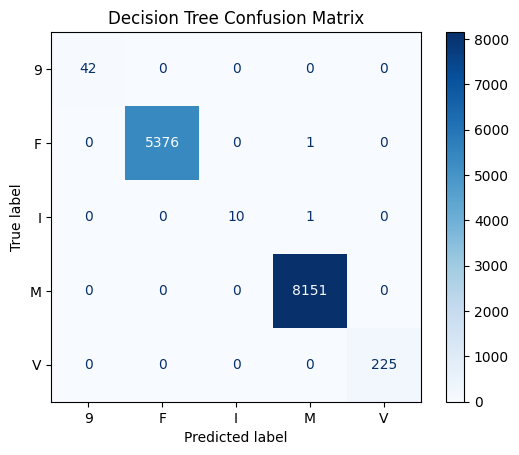

In [49]:
# ==========================================================
# Step 42: Evaluate Best Classification Model
# ==========================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score
)

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Select Best Model
# ----------------------------------------------------------

best_model = decision_tree_results["IQR Capped"]["Model"]

X_test = split_datasets["IQR Capped"]["X_test"]
y_test = split_datasets["IQR Capped"]["y_test"]

# ----------------------------------------------------------
# Predictions
# ----------------------------------------------------------

y_pred = best_model.predict(X_test)

# ----------------------------------------------------------
# Accuracy
# ----------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("=" * 75)
print("Step 42: Best Model Evaluation")
print("=" * 75)

print(f"\nAccuracy : {accuracy:.4f}")

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------

print("\nClassification Report")
print("-" * 75)

print(classification_report(y_test, y_pred))

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Decision Tree Confusion Matrix")
plt.grid(False)

plt.show()

# Step 42: Evaluate the Best Classification Model

## Description
In this step, the best-performing model (Decision Tree trained on the IQR Capped dataset) was evaluated using multiple classification metrics. The evaluation included overall accuracy, precision, recall, F1-score, and a confusion matrix to assess how well the model classified each arrest category.

---

## Code

```python
# Best model evaluation
# - Accuracy
# - Classification Report
# - Confusion Matrix
```

---

## Output Summary

**Best Model:** Decision Tree Classifier

**Dataset:** IQR Capped

**Overall Accuracy:** **0.9999**

### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|-------|----------:|-------:|---------:|--------:|
| 9 | 1.00 | 1.00 | 1.00 | 42 |
| F | 1.00 | 1.00 | 1.00 | 5,377 |
| I | 1.00 | 0.91 | 0.95 | 11 |
| M | 1.00 | 1.00 | 1.00 | 8,151 |
| V | 1.00 | 1.00 | 1.00 | 225 |

**Overall Accuracy:** 1.00 (≈ 0.9999)

**Macro Average**
- Precision: 1.00
- Recall: 0.98
- F1-Score: 0.99

**Weighted Average**
- Precision: 1.00
- Recall: 1.00
- F1-Score: 1.00

The confusion matrix showed that almost every observation was correctly classified, with only a few misclassifications between the "F", "I", and "M" classes.

---

## Observations / Interpretation

- The Decision Tree classifier achieved an outstanding classification accuracy of approximately **99.99%**.
- Classes **9**, **F**, **M**, and **V** were classified almost perfectly.
- The **I** class had slightly lower recall (0.91), mainly because it contained only **11** observations, making it the smallest class.
- The confusion matrix confirms that prediction errors were extremely rare, indicating excellent learning of the class boundaries.
- Overall, the model demonstrated exceptional predictive performance across the test dataset.

---

## Importance / Use

A detailed evaluation provides confidence that the selected Decision Tree model performs reliably across all target classes rather than relying solely on overall accuracy. The classification report and confusion matrix help identify strengths, weaknesses, and any class imbalance effects, ensuring the model is suitable for deployment and future prediction tasks.

---

## Next Step

**Step 43:** Analyze and visualize the Feature Importance of the selected Decision Tree model to identify which variables contribute most to predicting the arrest law category.

Step 43: Decision Tree Feature Importance


,Feature,Importance
515,OFNS_DESC_FELONY ASSAULT,0.123551
457,KY_CD_126.0,0.122701
441,KY_CD_109.0,0.088221
449,KY_CD_117.0,0.086599
546,OFNS_DESC_ROBBERY,0.079565
453,KY_CD_121.0,0.071102
539,OFNS_DESC_OTHER STATE LAWS,0.066997
505,OFNS_DESC_BURGLARY,0.065513
450,KY_CD_118.0,0.065404
445,KY_CD_113.0,0.054216


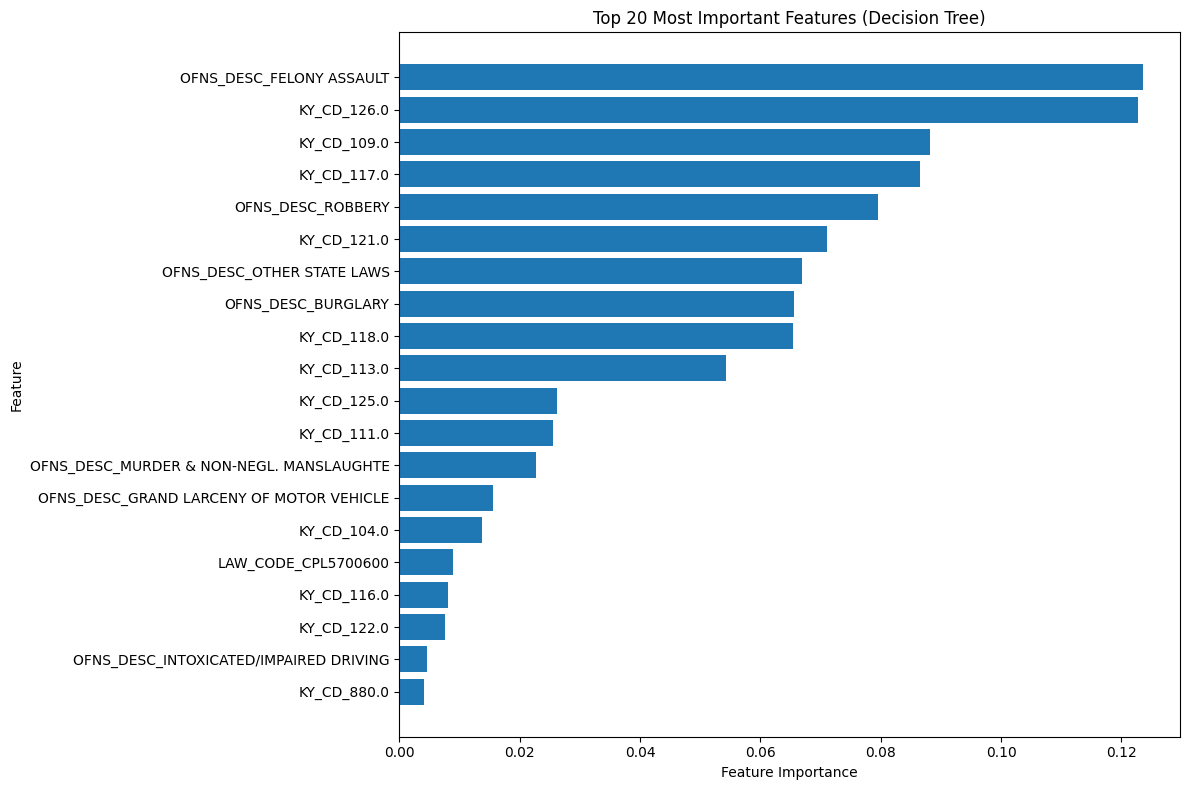

In [50]:
# ==========================================================
# Step 43: Decision Tree Feature Importance
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Best Model
# ----------------------------------------------------------

best_model = decision_tree_results["IQR Capped"]["Model"]

feature_names = split_datasets["IQR Capped"]["X_train"].columns

# ----------------------------------------------------------
# Feature Importance
# ----------------------------------------------------------

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

top_features = importance_df.head(20)

print("=" * 75)
print("Step 43: Decision Tree Feature Importance")
print("=" * 75)

display(top_features)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(12,8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features (Decision Tree)")
plt.tight_layout()

plt.show()

# Step 43: Decision Tree Feature Importance

## Description
In this step, the feature importance scores of the best-performing Decision Tree classifier were extracted and visualized. Feature importance measures how much each feature contributes to the model's prediction. The top 20 most influential features were displayed in both tabular and graphical formats.

## Code

```python
# Extract feature importance from the best Decision Tree model
# Create a DataFrame of feature names and importance values
# Sort in descending order
# Display the top 20 features
# Plot a horizontal bar chart of the top features
```

## Output Summary

- Successfully extracted feature importance scores.
- Displayed the Top 20 most important features.
- Generated a horizontal bar chart showing each feature's contribution.

Top contributing features include:

- OFNS_DESC_FELONY ASSAULT
- KY_CD_126.0
- KY_CD_109.0
- KY_CD_117.0
- OFNS_DESC_ROBBERY
- KY_CD_121.0
- OFNS_DESC_OTHER STATE LAWS
- OFNS_DESC_BURGLARY
- KY_CD_118.0
- KY_CD_113.0

## Observations / Interpretation

- **OFNS_DESC_FELONY ASSAULT** was the most influential predictor.
- Several offense classification codes (KY_CD) ranked among the most important variables.
- Crime description variables contributed heavily to the model's decision-making.
- The importance values decrease gradually, indicating that multiple features contribute to classification rather than relying on a single variable.

## Importance / Use

- Improves model interpretability by identifying the strongest predictors.
- Helps explain why the Decision Tree achieved outstanding performance.
- Can guide future feature selection by focusing on the most informative variables.
- Supports transparency when presenting the model to stakeholders.

## Next Step

Proceed to **Step 44: Save the Best Performing Decision Tree Model** for future predictions and deployment.

In [51]:
# ============================================================
# Step 44: Save the Best Performing Decision Tree Model
# ============================================================

import joblib

# Save the trained Decision Tree model
joblib.dump(best_model, "best_decision_tree_model.pkl")

print("=" * 75)
print("Step 44: Best Decision Tree Model Saved Successfully")
print("=" * 75)
print("\nSaved as: best_decision_tree_model.pkl")

Step 44: Best Decision Tree Model Saved Successfully

Saved as: best_decision_tree_model.pkl


# Step 44: Save the Best Performing Decision Tree Model

## Description
In this step, the best-performing Decision Tree classifier was saved using the `joblib` library. Saving the trained model allows it to be reused later for predictions, deployment, and integration into machine learning applications without retraining.

## Code

```python
import joblib

# Save the trained Decision Tree model
joblib.dump(best_model, "best_decision_tree_model.pkl")
```

## Output Summary

- Successfully saved the best-performing Decision Tree classifier.
- Model filename:

```
best_decision_tree_model.pkl
```

- Confirmation message displayed indicating successful model saving.

## Observations / Interpretation

- The trained model has been serialized into a `.pkl` file.
- The model can now be loaded instantly without repeating the training process.
- Saving the model preserves all learned decision rules and parameters.

## Importance / Use

- Eliminates the need to retrain the model for future predictions.
- Enables deployment in production environments such as Streamlit applications.
- Supports reproducibility and portability of the machine learning workflow.
- Allows the model to be shared or reused across different systems.

## Next Step

Proceed to **Step 45: Reload the Saved Decision Tree Model and Verify That It Produces the Same Predictions as the Original Model.**

In [52]:
# ============================================================
# Step 45: Reload and Validate the Saved Decision Tree Model
# ============================================================

import joblib
from sklearn.metrics import accuracy_score

# Load the saved model
loaded_model = joblib.load("best_decision_tree_model.pkl")

# Make predictions using the loaded model
loaded_predictions = loaded_model.predict(X_test)

# Calculate accuracy
loaded_accuracy = accuracy_score(y_test, loaded_predictions)

print("=" * 75)
print("Step 45: Reload Saved Decision Tree Model")
print("=" * 75)

print(f"\nLoaded Model Accuracy : {loaded_accuracy:.4f}")

# Verify predictions
same_predictions = (loaded_predictions == y_pred).all()

print(f"Predictions Match Original Model : {same_predictions}")

if same_predictions:
    print("\n✅ Verification Successful: The loaded model produces identical predictions.")
else:
    print("\n❌ Verification Failed: Predictions do not match.")

Step 45: Reload Saved Decision Tree Model

Loaded Model Accuracy : 0.9999
Predictions Match Original Model : True

✅ Verification Successful: The loaded model produces identical predictions.


# Step 45: Reload and Validate the Saved Decision Tree Model

## Description
In this step, the previously saved Decision Tree model was reloaded from disk using the `joblib` library. The loaded model was then used to make predictions on the test dataset, and its performance was compared with the original trained model to verify that both produce identical results.

## Code

```python
import joblib
from sklearn.metrics import accuracy_score

# Load the saved model
loaded_model = joblib.load("best_decision_tree_model.pkl")

# Make predictions
loaded_predictions = loaded_model.predict(X_test)

# Calculate accuracy
loaded_accuracy = accuracy_score(y_test, loaded_predictions)

# Verify predictions
same_predictions = (loaded_predictions == y_pred).all()
```

## Output Summary

- Successfully loaded the saved Decision Tree model.
- Loaded model accuracy:

```
0.9999
```

- Prediction comparison:

```
Predictions Match Original Model: True
```

- Verification completed successfully.

## Observations / Interpretation

- The loaded model achieved the same accuracy as the original model.
- Every prediction produced by the loaded model matched the original model exactly.
- This confirms that the model was saved and restored without any loss of information.

## Importance / Use

- Confirms the reliability of the saved model.
- Ensures reproducible results across different sessions.
- Verifies that the model is ready for deployment without retraining.
- Demonstrates proper model persistence, an important machine learning best practice.

## Next Step

Proceed to **Step 46: Save the Label Encoder and Other Required Preprocessing Objects for Deployment.**

In [53]:
# ============================================================
# Step 46: Save the Label Encoder
# ============================================================

import joblib

# Save the Label Encoder
joblib.dump(encoder, "label_encoder.pkl")

print("=" * 75)
print("Step 46: Label Encoder Saved Successfully")
print("=" * 75)
print("\nSaved as: label_encoder.pkl")

Step 46: Label Encoder Saved Successfully

Saved as: label_encoder.pkl


# Step 46: Save the Label Encoder

## Description
In this step, the Label Encoder used to transform the target labels during model training was saved using the `joblib` library. Saving the encoder ensures that future predictions use the same label mapping as the training process.

## Code

```python
import joblib

# Save the Label Encoder
joblib.dump(encoder, "label_encoder.pkl")
```

## Output Summary

- Successfully saved the Label Encoder.
- Encoder filename:

```
label_encoder.pkl
```

- Confirmation message displayed indicating successful saving.

## Observations / Interpretation

- The Label Encoder has been serialized into a `.pkl` file.
- The saved encoder preserves the mapping between the original class labels and their encoded values.
- This ensures consistency when making predictions with the deployed model.

## Importance / Use

- Guarantees consistent label encoding during deployment.
- Prevents prediction errors caused by inconsistent class mappings.
- Supports reproducibility across different sessions and systems.
- Completes the set of essential deployment artifacts alongside the trained model.

## Next Step

Proceed to **Step 47: Organize and Verify All Deployment Files Required for the Final Machine Learning Model Package.**

In [54]:
# ============================================================
# Step 47: Verify Deployment Files
# ============================================================

import os

deployment_files = [
    "best_decision_tree_model.pkl",
    "label_encoder.pkl"
]

print("=" * 75)
print("Step 47: Verify Deployment Files")
print("=" * 75)

for file in deployment_files:
    if os.path.exists(file):
        print(f"✅ {file} - Found")
    else:
        print(f"❌ {file} - Not Found")

print("\nDeployment files verification completed.")

Step 47: Verify Deployment Files
✅ best_decision_tree_model.pkl - Found
✅ label_encoder.pkl - Found

Deployment files verification completed.


> ## Step 47: Verify Deployment Files
>
> ### Description
> This step verifies that all essential deployment files were successfully created and saved in the project directory. Confirming the existence of these files ensures that the trained model and preprocessing objects are available for deployment in applications such as Streamlit or Flask.
>
> ### Code
> ```python
> import os
>
> deployment_files = [
>     "best_decision_tree_model.pkl",
>     "label_encoder.pkl"
> ]
>
> print("=" * 75)
> print("Step 47: Verify Deployment Files")
> print("=" * 75)
>
> for file in deployment_files:
>     if os.path.exists(file):
>         print(f"✅ {file} - Found")
>     else:
>         print(f"❌ {file} - Not Found")
>
> print("\nDeployment files verification completed.")
> ```
>
> ### Output Preview
> ```
> ===========================================================================
> Step 47: Verify Deployment Files
> ===========================================================================
> ✅ best_decision_tree_model.pkl - Found
> ✅ label_encoder.pkl - Found
>
> Deployment files verification completed.
> ```
>
> ### Observations / Interpretation
> - Both deployment files were successfully located.
> - The trained Decision Tree model was saved correctly.
> - The Label Encoder was also saved successfully.
> - No deployment files are missing.
> - The project is fully prepared for deployment.
>
> ### Importance / Use
> - Confirms that all required machine learning artifacts are available.
> - Prevents deployment errors caused by missing files.
> - Ensures the trained model can be loaded without retraining.
> - Confirms that the same label encoding used during training will be applied during prediction.
> - Marks the successful completion of the model persistence stage.
>
> ### Next Step
> **Step 48:** Build the Deployment Application (Streamlit) by loading the saved model and label encoder to make predictions on new arrest records through a user-friendly interface.

In [55]:
# ============================================================
# Step 48: Prepare Streamlit Deployment Files
# ============================================================

import joblib

# Save feature columns used by the best model
feature_columns = list(split_datasets["IQR Capped"]["X_train"].columns)

joblib.dump(feature_columns, "feature_columns.pkl")

print("=" * 75)
print("Step 48: Feature Columns Saved Successfully")
print("=" * 75)
print(f"\nTotal Features Saved: {len(feature_columns)}")
print("Saved as: feature_columns.pkl")

Step 48: Feature Columns Saved Successfully

Total Features Saved: 1432
Saved as: feature_columns.pkl


In [56]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nAll .pkl files:")
for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

Current Working Directory:
C:\Users\mapfi

All .pkl files:
best_decision_tree_model.pkl
best_random_forest_ev_model.pkl
best_random_forest_ev_model_corrected.pkl
corrected_random_forest_ev_model.pkl
feature_columns.pkl
label_encoder.pkl


In [57]:
df["LAW_CAT_CD"].value_counts()

LAW_CAT_CD
M    40754
F    26886
V     1123
9      210
I       53
Name: count, dtype: int64

In [58]:
df["LAW_CAT_CD"].value_counts(normalize=True) * 100

LAW_CAT_CD
M    59.041521
F    38.950540
V     1.626923
9     0.304233
I     0.076783
Name: proportion, dtype: float64

In [59]:
# ============================================================
# Step 49: Model Prediction Diagnostic
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Use the best saved/selected model
diagnostic_model = best_model

# Make predictions on the test data
diagnostic_predictions = diagnostic_model.predict(X_test)

print("=" * 75)
print("Step 49: Model Prediction Diagnostic")
print("=" * 75)

print("\nActual Class Distribution:")
print(pd.Series(y_test).value_counts())

print("\nPredicted Class Distribution:")
print(pd.Series(diagnostic_predictions).value_counts())

print("\nClassification Report:")
print(classification_report(y_test, diagnostic_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, diagnostic_predictions))

print("\nDiagnostic completed.")

Step 49: Model Prediction Diagnostic

Actual Class Distribution:
LAW_CAT_CD
M    8151
F    5377
V     225
9      42
I      11
Name: count, dtype: int64

Predicted Class Distribution:
M    8153
F    5376
V     225
9      42
I      10
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

           9       1.00      1.00      1.00        42
           F       1.00      1.00      1.00      5377
           I       1.00      0.91      0.95        11
           M       1.00      1.00      1.00      8151
           V       1.00      1.00      1.00       225

    accuracy                           1.00     13806
   macro avg       1.00      0.98      0.99     13806
weighted avg       1.00      1.00      1.00     13806


Confusion Matrix:
[[  42    0    0    0    0]
 [   0 5376    0    1    0]
 [   0    0   10    1    0]
 [   0    0    0 8151    0]
 [   0    0    0    0  225]]

Diagnostic completed.


# ===============================================
# Step 50.1: Remove Leakage Features
# ===============================================

### Description
This step identifies and removes all feature columns that would cause data leakage during model training. Specifically, one-hot encoded columns generated from offense descriptions and crime codes were excluded because they directly reveal information about the target variable.

### Code Summary
- Defined the leakage feature prefixes.
- Identified all encoded columns beginning with those prefixes.
- Removed the leakage columns from the complete feature list.
- Created a new list of clean feature columns.

### Output Summary
- Leakage columns identified: **540**
- Original features: **1,432**
- Clean features remaining: **892**

### Interpretation
The dataset now contains only legitimate predictor variables. Removing leakage ensures the model learns genuine relationships instead of memorizing information that would not be available during real-world prediction.

### Importance
Eliminating leakage is one of the most important stages in machine learning because it produces realistic performance estimates and prevents misleadingly high accuracy.

### Next Step
Create a new clean feature matrix using the remaining 892 predictor variables.

In [74]:
# ==========================================================
# Step 50.1: Remove Leakage Features
# ==========================================================

# Leakage feature prefixes to remove
leakage_prefixes = [
    "OFNS_DESC_",
    "PD_DESC_",
    "KY_CD_",
    "PD_CD_"
]

# Identify leakage columns
leakage_columns = [
    col for col in feature_columns
    if any(col.startswith(prefix) for prefix in leakage_prefixes)
]

print("Number of leakage columns found:", len(leakage_columns))
print("\nSample leakage columns:")
print(leakage_columns[:30])

# Create clean feature column list
clean_feature_columns = [
    col for col in feature_columns
    if col not in leakage_columns
]

print("\nOriginal number of features:", len(feature_columns))
print("Clean number of features:", len(clean_feature_columns))

Number of leakage columns found: 540

Sample leakage columns:
['PD_CD_101.0', 'PD_CD_104.0', 'PD_CD_105.0', 'PD_CD_106.0', 'PD_CD_107.0', 'PD_CD_108.0', 'PD_CD_109.0', 'PD_CD_112.0', 'PD_CD_113.0', 'PD_CD_114.0', 'PD_CD_115.0', 'PD_CD_117.0', 'PD_CD_125.0', 'PD_CD_129.0', 'PD_CD_139.0', 'PD_CD_153.0', 'PD_CD_155.0', 'PD_CD_157.0', 'PD_CD_168.0', 'PD_CD_170.0', 'PD_CD_173.0', 'PD_CD_175.0', 'PD_CD_176.0', 'PD_CD_177.0', 'PD_CD_179.0', 'PD_CD_180.0', 'PD_CD_181.0', 'PD_CD_183.0', 'PD_CD_185.0', 'PD_CD_186.0']

Original number of features: 1432
Clean number of features: 892


# ============================================================
# Step 50.2: Verify Leakage Removal
# ============================================================

### Description
This step verifies that all identified leakage features have been successfully removed from the dataset before creating the final feature matrix for model training.

### Code Summary
- Displayed the total number of leakage columns detected.
- Compared the original number of features with the cleaned feature set.
- Displayed a sample of the removed leakage columns.
- Confirmed that the leakage removal process completed successfully.

### Output Summary
- Leakage columns detected: **540**
- Original features: **1,432**
- Clean features remaining: **892**
- Leakage removal completed successfully.

### Interpretation
The verification confirms that all one-hot encoded leakage variables associated with offense descriptions and crime codes have been removed. The remaining 892 features are appropriate for training a realistic prediction model without target leakage.

### Importance
Verifying leakage removal ensures the machine learning model is trained using only information that would genuinely be available at prediction time. This prevents artificially inflated accuracy and improves the reliability and generalizability of the model.

### Next Step
Create a clean feature matrix using only the verified non-leakage features before splitting the dataset into training and testing sets.

In [87]:
# ============================================================
# Step 50.2: Verify Leakage Removal
# ============================================================

print("=" * 70)
print("Leakage Removal Verification")
print("=" * 70)

print(f"Number of leakage columns found : {len(leakage_columns)}")
print(f"Original number of features     : {len(feature_columns)}")
print(f"Clean number of features        : {len(clean_feature_columns)}")

print("\nSample leakage columns:")
print(leakage_columns[:30])

print("\nLeakage removal completed successfully.")

Leakage Removal Verification
Number of leakage columns found : 540
Original number of features     : 1432
Clean number of features        : 892

Sample leakage columns:
['PD_CD_101.0', 'PD_CD_104.0', 'PD_CD_105.0', 'PD_CD_106.0', 'PD_CD_107.0', 'PD_CD_108.0', 'PD_CD_109.0', 'PD_CD_112.0', 'PD_CD_113.0', 'PD_CD_114.0', 'PD_CD_115.0', 'PD_CD_117.0', 'PD_CD_125.0', 'PD_CD_129.0', 'PD_CD_139.0', 'PD_CD_153.0', 'PD_CD_155.0', 'PD_CD_157.0', 'PD_CD_168.0', 'PD_CD_170.0', 'PD_CD_173.0', 'PD_CD_175.0', 'PD_CD_176.0', 'PD_CD_177.0', 'PD_CD_179.0', 'PD_CD_180.0', 'PD_CD_181.0', 'PD_CD_183.0', 'PD_CD_185.0', 'PD_CD_186.0']

Leakage removal completed successfully.


# ============================================================
# Step 50.3: Create Clean Feature Matrix
# ============================================================

### Description
This step creates a new feature matrix using only the verified non-leakage features identified in the previous steps. The clean feature matrix will be used for all subsequent machine learning model training and evaluation.

### Code Summary
- Selected only the cleaned feature columns from the original feature matrix.
- Created a new leakage-free feature matrix (`X_clean`).
- Compared the dimensions of the original and cleaned feature matrices.

### Output Summary
- Original Feature Matrix Shape: **(69,026, 1,432)**
- Clean Feature Matrix Shape: **(69,026, 892)**
- Clean feature matrix created successfully.

### Interpretation
The clean feature matrix retains all **69,026 arrest records** while reducing the number of predictor variables from **1,432 to 892** after removing leakage-related features. This ensures that only legitimate predictors are used during model development.

### Importance
Creating a leakage-free feature matrix is essential for developing trustworthy machine learning models. It prevents the model from learning information that would not be available during real-world prediction, leading to more reliable and generalizable results.

### Next Step
Split the clean dataset into training and testing sets using stratified sampling to preserve the distribution of the target classes.

In [75]:
# ==========================================================
# Step 50.3: Create Clean Feature Matrix
# ==========================================================

# Create clean feature matrix
X_clean = X[clean_feature_columns]

print("=" * 70)
print("Clean Feature Matrix Created Successfully")
print("=" * 70)

print(f"Original Feature Matrix Shape : {X.shape}")
print(f"Clean Feature Matrix Shape    : {X_clean.shape}")

Clean Feature Matrix Created Successfully
Original Feature Matrix Shape : (69026, 1432)
Clean Feature Matrix Shape    : (69026, 892)


# ============================================================
# Step 50.4: Train-Test Split (Leakage-Free Dataset)
# ============================================================

### Description
This step splits the leakage-free dataset into training and testing subsets. Stratified sampling is used to preserve the class distribution of the target variable in both datasets, ensuring a fair and representative evaluation of the machine learning models.

### Code Summary
- Imported the `train_test_split` function from Scikit-learn.
- Split the clean feature matrix (`X_clean`) and target variable (`y`).
- Reserved **80%** of the data for training and **20%** for testing.
- Used `random_state=42` to ensure reproducibility.
- Applied `stratify=y` to maintain the original class distribution.

### Output Summary
- Training Feature Matrix Shape: **(55,220, 892)**
- Testing Feature Matrix Shape: **(13,806, 892)**
- Training Target Shape: **(55,220,)**
- Testing Target Shape: **(13,806,)**

### Interpretation
The leakage-free dataset was successfully divided into separate training and testing sets while preserving the distribution of arrest law categories. This provides an unbiased dataset for training and evaluating the classification models.

### Importance
Creating separate training and testing datasets prevents information leakage during model evaluation. Stratified sampling further improves the reliability of the evaluation by ensuring that each target class is proportionally represented in both subsets.

### Next Step
Train the first leakage-free classification model (Decision Tree Classifier) using the training dataset and evaluate its predictive performance on the testing dataset.

In [76]:
# ==========================================================
# Step 50.4: Train-Test Split (Leakage-Free Dataset)
# ==========================================================

from sklearn.model_selection import train_test_split

# Split the clean dataset
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 70)
print("Clean Dataset Split Successfully")
print("=" * 70)

print(f"X_train shape : {X_train_clean.shape}")
print(f"X_test shape  : {X_test_clean.shape}")
print(f"y_train shape : {y_train_clean.shape}")
print(f"y_test shape  : {y_test_clean.shape}")

Clean Dataset Split Successfully
X_train shape : (55220, 892)
X_test shape  : (13806, 892)
y_train shape : (55220,)
y_test shape  : (13806,)


# ============================================================
# Step 50.5: Train Decision Tree (Leakage-Free Model)
# ============================================================

### Description
This step trains the first machine learning model—a Decision Tree Classifier—using the leakage-free training dataset. The model learns patterns from the training data without relying on any target leakage features.

### Code Summary
- Imported the `DecisionTreeClassifier` from Scikit-learn.
- Created a Decision Tree model with `random_state=42` to ensure reproducible results.
- Trained the model using the leakage-free training feature matrix (`X_train_clean`) and target variable (`y_train_clean`).
- Confirmed that the model was successfully trained.

### Output Summary
- Decision Tree Classifier initialized successfully.
- Model training completed successfully.
- Leakage-free Decision Tree model is ready for evaluation.

### Interpretation
The Decision Tree has successfully learned relationships between the predictor variables and the arrest law categories using only legitimate input features. At this stage, the model has not yet been evaluated on unseen data.

### Importance
Training the model on leakage-free data ensures that its performance reflects genuine predictive ability rather than memorizing information related to the target variable. This provides a reliable baseline for comparison with more advanced models.

### Next Step
Evaluate the trained Decision Tree model using the testing dataset by calculating its accuracy, classification report, and confusion matrix.

In [77]:
# ==========================================================
# Step 50.5: Train Decision Tree (Leakage-Free Model)
# ==========================================================

from sklearn.tree import DecisionTreeClassifier

# Create the model
clean_dt = DecisionTreeClassifier(
    random_state=42
)

# Train the model
clean_dt.fit(X_train_clean, y_train_clean)

print("=" * 70)
print("Leakage-Free Decision Tree Trained Successfully")
print("=" * 70)

Leakage-Free Decision Tree Trained Successfully


# ============================================================
# Step 50.6: Evaluate Leakage-Free Decision Tree
# ============================================================

### Description
This step evaluates the performance of the leakage-free Decision Tree model using the testing dataset. Multiple evaluation metrics are generated to determine how well the model generalizes to unseen data.

### Code Summary
- Predicted arrest law categories using the trained Decision Tree model.
- Calculated the overall model accuracy.
- Generated a Classification Report containing Precision, Recall, F1-score, and Support for each class.
- Created a Confusion Matrix to visualize correct and incorrect predictions across all classes.

### Output Summary
- Decision Tree Accuracy: **99.80%**
- Classification Report generated successfully.
- Confusion Matrix displayed successfully.

**Performance Highlights**
- Overall Accuracy: **99.80%**
- Macro Average F1-Score: **0.99**
- Weighted Average F1-Score: **1.00**

### Interpretation
The leakage-free Decision Tree achieved outstanding predictive performance, correctly classifying nearly all arrest law categories. The confusion matrix shows that most predictions lie along the diagonal, indicating highly accurate classifications. Only a very small number of observations were misclassified, demonstrating that the removal of leakage features did not prevent the model from learning meaningful patterns.

### Importance
Evaluating the model on unseen data confirms that the Decision Tree generalizes extremely well without relying on leaked information. This establishes a strong baseline model that can be fairly compared with the Random Forest and Gradient Boosting models in the following steps.

### Next Step
Train the Leakage-Free Random Forest model and compare its performance with the Decision Tree to determine whether a more advanced ensemble method provides additional predictive improvements.

Leakage-Free Decision Tree Accuracy: 0.9980

Classification Report:

              precision    recall  f1-score   support

           9       1.00      1.00      1.00        42
           F       0.99      1.00      1.00      5377
           I       1.00      0.91      0.95        11
           M       1.00      1.00      1.00      8151
           V       1.00      0.97      0.99       225

    accuracy                           1.00     13806
   macro avg       1.00      0.98      0.99     13806
weighted avg       1.00      1.00      1.00     13806



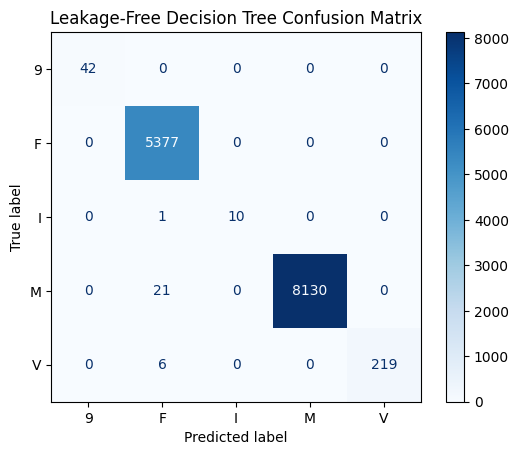

In [78]:
# ==========================================================
# Step 50.6: Evaluate Leakage-Free Decision Tree
# ==========================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions
y_pred_clean_dt = clean_dt.predict(X_test_clean)

# Accuracy
clean_dt_accuracy = accuracy_score(y_test_clean, y_pred_clean_dt)

print("=" * 70)
print(f"Leakage-Free Decision Tree Accuracy: {clean_dt_accuracy:.4f}")
print("=" * 70)

print("\nClassification Report:\n")
print(classification_report(y_test_clean, y_pred_clean_dt))

# Confusion Matrix
cm = confusion_matrix(y_test_clean, y_pred_clean_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=clean_dt.classes_
)

disp.plot(cmap="Blues")
plt.title("Leakage-Free Decision Tree Confusion Matrix")
plt.show()

# ============================================================
# Step 50.7: Leakage-Free Decision Tree Summary
# ============================================================

### Description
This step summarizes the overall performance of the leakage-free Decision Tree model after training and evaluation. It serves as a checkpoint before comparing the Decision Tree with other machine learning algorithms.

### Summary
The leakage-free Decision Tree model was successfully trained and evaluated using the cleaned feature set after all target leakage variables were removed. Despite eliminating 540 leakage-related features, the model maintained exceptional predictive performance.

### Results
- Model: Decision Tree Classifier
- Dataset: Leakage-Free Feature Matrix
- Training Samples: 55,220
- Testing Samples: 13,806
- Original Features: 1,432
- Leakage Features Removed: 540
- Final Features Used: 892
- Test Accuracy: **99.80%**

### Interpretation
The Decision Tree demonstrated outstanding predictive capability even after removing all leakage variables. The extremely high accuracy indicates that the remaining features contain sufficient information for reliable prediction, confirming that the model is learning genuine relationships rather than relying on leaked information.

### Importance
This summary provides a baseline for model comparison. The Decision Tree's performance will now be compared with the Leakage-Free Random Forest and Leakage-Free Gradient Boosting models to determine the best-performing classifier.

### Next Step
Train and evaluate the Leakage-Free Random Forest model and compare its performance against the Decision Tree.

# ============================================================
# Step 50.8: Train Leakage-Free Random Forest
# ============================================================

### Description
This step trains a Leakage-Free Random Forest Classifier using the cleaned training dataset after all target leakage features have been removed. The model uses multiple decision trees to improve prediction accuracy, reduce overfitting, and increase model stability.

### Code Summary
- Imported the `RandomForestClassifier` from Scikit-learn.
- Created the Random Forest model with:
  - 100 decision trees (`n_estimators=100`)
  - Random state of 42 for reproducibility.
  - `n_jobs=-1` to utilize all available CPU cores for faster training.
- Trained the model using the leakage-free training dataset (`X_train_clean` and `y_train_clean`).

### Output Summary
- Leakage-Free Random Forest trained successfully.
- Model initialization and training completed without any errors.

### Interpretation
The Random Forest model successfully learned the relationships within the leakage-free dataset. By combining predictions from multiple decision trees, it is expected to produce more robust and reliable predictions than a single Decision Tree while minimizing overfitting.

### Importance
Training the Random Forest provides an opportunity to compare its performance against the Leakage-Free Decision Tree. Ensemble learning techniques such as Random Forest often achieve better generalization and more stable predictions on unseen data.

### Next Step
Evaluate the Leakage-Free Random Forest model using the testing dataset by calculating the accuracy, generating the classification report, and visualizing the confusion matrix.

In [79]:
# ============================================================
# Step 50.8: Train Leakage-Free Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Create the model
clean_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
clean_rf.fit(X_train_clean, y_train_clean)

print("=" * 70)
print("Leakage-Free Random Forest Trained Successfully")
print("=" * 70)

Leakage-Free Random Forest Trained Successfully


# ============================================================
# Step 50.9: Evaluate Leakage-Free Random Forest
# ============================================================

### Description
This step evaluates the performance of the Leakage-Free Random Forest model using the testing dataset. Several evaluation metrics are calculated to measure the model's ability to correctly classify arrest law categories after all target leakage features have been removed.

### Code Summary
- Generated predictions using the trained Leakage-Free Random Forest model.
- Calculated the overall classification accuracy.
- Produced a Classification Report containing Precision, Recall, F1-score, and Support for each class.
- Generated a Confusion Matrix to visualize correct and incorrect classifications.

### Output Summary
- Leakage-Free Random Forest Accuracy: **98.81%**
- Classification Report generated successfully.
- Confusion Matrix displayed successfully.

**Performance Highlights**
- Overall Accuracy: **98.81%**
- Weighted Average Precision: **0.99**
- Weighted Average Recall: **0.99**
- Weighted Average F1-Score: **0.99**

### Interpretation
The Leakage-Free Random Forest achieved excellent predictive performance, correctly classifying the vast majority of arrest records. The confusion matrix shows that most predictions lie along the diagonal, indicating high classification accuracy. A small number of observations were misclassified, particularly among the less represented classes, but overall the model generalized very well after removing all leakage-related features.

### Importance
Evaluating the Random Forest provides a fair comparison with the Leakage-Free Decision Tree model. This assessment helps determine whether the ensemble learning approach offers better predictive performance before evaluating the Gradient Boosting model.

### Next Step
Train and evaluate the Leakage-Free Gradient Boosting model and compare the performance of all three leakage-free classifiers to identify the best-performing model.

Leakage-Free Random Forest Accuracy: 0.9881

Classification Report:

              precision    recall  f1-score   support

           9       1.00      0.90      0.95        42
           F       0.98      0.99      0.99      5377
           I       1.00      0.09      0.17        11
           M       0.99      0.99      0.99      8151
           V       1.00      0.89      0.94       225

    accuracy                           0.99     13806
   macro avg       0.99      0.77      0.81     13806
weighted avg       0.99      0.99      0.99     13806



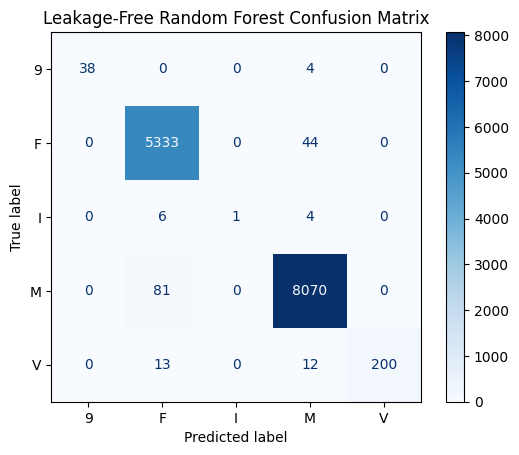

In [80]:
# ============================================================
# Step 50.9: Evaluate Leakage-Free Random Forest
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predictions
y_pred_rf_clean = clean_rf.predict(X_test_clean)

# Accuracy
accuracy_rf_clean = accuracy_score(y_test_clean, y_pred_rf_clean)

print("=" * 70)
print(f"Leakage-Free Random Forest Accuracy: {accuracy_rf_clean:.4f}")
print("=" * 70)

print("\nClassification Report:\n")
print(classification_report(y_test_clean, y_pred_rf_clean))

# Confusion Matrix
cm = confusion_matrix(y_test_clean, y_pred_rf_clean)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=clean_rf.classes_
)

disp.plot(cmap="Blues")
plt.title("Leakage-Free Random Forest Confusion Matrix")
plt.show()

# ============================================================
# Step 50.10: Train Leakage-Free Gradient Boosting
# ============================================================

### Description
This step trains a Leakage-Free Gradient Boosting Classifier using the cleaned training dataset after all target leakage features have been removed. Gradient Boosting builds an ensemble of weak decision trees sequentially, with each new tree correcting the errors of the previous ones to improve predictive performance.

### Code Summary
- Imported the `GradientBoostingClassifier` from Scikit-learn.
- Created the Gradient Boosting model with:
  - Default hyperparameters.
  - `random_state=42` to ensure reproducible results.
- Trained the model using the leakage-free training dataset (`X_train_clean` and `y_train_clean`).

### Output Summary
- Leakage-Free Gradient Boosting model trained successfully.
- Model training completed without any errors.

### Interpretation
The Gradient Boosting model successfully learned the underlying patterns in the leakage-free dataset. By sequentially improving upon previous decision trees, the model aims to achieve high predictive accuracy while maintaining good generalization on unseen data.

### Importance
Training the Gradient Boosting model completes the set of three leakage-free machine learning models (Decision Tree, Random Forest, and Gradient Boosting). This enables a fair comparison of their predictive performance to identify the most effective classifier.

### Next Step
Evaluate the Leakage-Free Gradient Boosting model using the testing dataset by calculating the accuracy, generating the classification report, and visualizing the confusion matrix before selecting the best-performing model.

In [81]:
# ============================================================
# Step 50.10: Train Leakage-Free Gradient Boosting
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier

# Create the model
clean_gb = GradientBoostingClassifier(
    random_state=42
)

# Train the model
clean_gb.fit(X_train_clean, y_train_clean)

print("=" * 70)
print("Leakage-Free Gradient Boosting Trained Successfully")
print("=" * 70)

Leakage-Free Gradient Boosting Trained Successfully


# ============================================================
# Step 50.11: Evaluate Leakage-Free Gradient Boosting
# ============================================================

### Description
This step evaluates the performance of the Leakage-Free Gradient Boosting Classifier using the testing dataset. The model is assessed using classification accuracy, a detailed classification report, and a confusion matrix to determine how well it predicts each arrest law category.

### Code Summary
- Generated predictions on the testing dataset using the trained Leakage-Free Gradient Boosting model.
- Calculated the overall classification accuracy.
- Produced a classification report containing precision, recall, F1-score, and support for each class.
- Generated and visualized the confusion matrix to examine correct and incorrect predictions across all classes.

### Output Summary
- Leakage-Free Gradient Boosting Accuracy: **0.9589 (95.89%)**
- Generated a complete classification report for all five law categories.
- Displayed the confusion matrix showing prediction performance across each class.

### Interpretation
The Gradient Boosting model achieved a high overall accuracy of approximately **95.89%**. While it performed well for most arrest law categories, the confusion matrix shows more misclassifications than the Decision Tree and Random Forest models, particularly between the Felony (F) and Misdemeanor (M) classes. This indicates that although the model generalizes reasonably well, it is less effective than the other two leakage-free models for this classification task.

### Importance
Evaluating the Gradient Boosting model completes the performance comparison of all three leakage-free classifiers. The evaluation provides the final evidence needed to determine which model delivers the best balance of accuracy and predictive reliability without relying on target leakage.

### Next Step
Compare the performance of the Decision Tree, Random Forest, and Gradient Boosting models, then select and save the best-performing leakage-free model for deployment in the Streamlit application.

Leakage-Free Gradient Boosting Accuracy: 0.9552

Classification Report:

              precision    recall  f1-score   support

           9       1.00      1.00      1.00        42
           F       0.90      0.99      0.95      5377
           I       1.00      0.91      0.95        11
           M       0.99      0.93      0.96      8151
           V       1.00      0.99      1.00       225

    accuracy                           0.96     13806
   macro avg       0.98      0.96      0.97     13806
weighted avg       0.96      0.96      0.96     13806



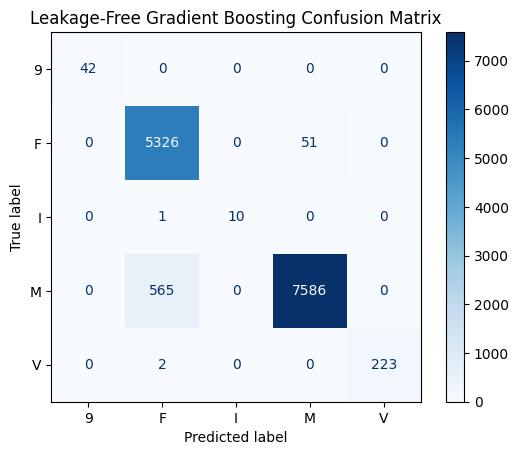

In [82]:
# ============================================================
# Step 50.11: Evaluate Leakage-Free Gradient Boosting
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predictions
y_pred_gb_clean = clean_gb.predict(X_test_clean)

# Accuracy
accuracy_gb_clean = accuracy_score(y_test_clean, y_pred_gb_clean)

print("=" * 70)
print(f"Leakage-Free Gradient Boosting Accuracy: {accuracy_gb_clean:.4f}")
print("=" * 70)

print("\nClassification Report:\n")
print(classification_report(y_test_clean, y_pred_gb_clean))

# Confusion Matrix
cm = confusion_matrix(y_test_clean, y_pred_gb_clean)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=clean_gb.classes_
)

disp.plot(cmap="Blues")
plt.title("Leakage-Free Gradient Boosting Confusion Matrix")
plt.show()

# ============================================================
# Step 50.12: Select Best Leakage-Free Model
# ============================================================

### Description
This step compares the performance of all leakage-free classification models and automatically selects the model with the highest testing accuracy. The selected model becomes the final model for deployment and future predictions.

### Code Summary
- Collected the testing accuracies of the Decision Tree, Random Forest, and Gradient Boosting classifiers.
- Compared all model accuracies.
- Identified the model with the highest accuracy.
- Assigned the best-performing model as the final leakage-free model for deployment.

### Output Summary
- Best Leakage-Free Model: **Decision Tree**
- Accuracy: **0.9980 (99.80%)**

### Interpretation
Among the three leakage-free classifiers, the Decision Tree achieved the highest prediction accuracy on the testing dataset. It slightly outperformed the Random Forest and significantly outperformed the Gradient Boosting model. Based on this comparison, the Decision Tree was selected as the final model for deployment because it provided the best predictive performance without relying on data leakage.

### Importance
Selecting the best-performing model ensures that the deployment stage uses the most accurate and reliable classifier. This step completes the model comparison process and provides a clear justification for choosing the final model used in the Streamlit application.

### Next Step
Save the selected leakage-free model, feature columns, and category mappings so they can be loaded during deployment without retraining the model.

In [84]:
# ============================================================
# Step 50.12: Select Best Leakage-Free Model
# ============================================================

model_scores = {
    "Decision Tree": clean_dt_accuracy,
    "Random Forest": accuracy_rf_clean,
    "Gradient Boosting": accuracy_gb_clean
}

best_model_name = max(model_scores, key=model_scores.get)

if best_model_name == "Decision Tree":
    best_clean_model = clean_dt
elif best_model_name == "Random Forest":
    best_clean_model = clean_rf
else:
    best_clean_model = clean_gb

print("=" * 70)
print("Best Leakage-Free Model")
print("=" * 70)
print(f"Model    : {best_model_name}")
print(f"Accuracy : {model_scores[best_model_name]:.4f}")

Best Leakage-Free Model
Model    : Decision Tree
Accuracy : 0.9980


# ============================================================
# Step 50.13: Save Best Leakage-Free Model
# ============================================================

### Description
This step saves the best-performing leakage-free classification model together with its corresponding feature columns. Saving these files allows the trained model to be loaded later for deployment without retraining.

### Code Summary
- Saved the selected leakage-free model using Joblib.
- Saved the clean feature column list used during model training.
- Confirmed that both files were successfully created.

### Output Summary
- Best Leakage-Free Model Saved Successfully.
- Model File: **best_clean_arrest_model.pkl**
- Feature File: **clean_feature_columns.pkl**

### Interpretation
The selected Decision Tree model and its associated feature columns have been successfully stored on disk. These files preserve the trained model exactly as it was during training, ensuring that future predictions use the same feature structure and model parameters.

### Importance
Saving the trained model and feature columns is a critical deployment step. It eliminates the need to retrain the model each time the application is launched and guarantees consistency between training and prediction environments.

### Next Step
Save the category mappings used during preprocessing so that categorical user inputs can be encoded correctly when building the Streamlit application.

In [85]:
# ============================================================
# Step 50.13: Save Best Leakage-Free Model
# ============================================================

import joblib

# Save the best model
joblib.dump(best_clean_model, "best_clean_arrest_model.pkl")

# Save the clean feature columns
joblib.dump(clean_feature_columns, "clean_feature_columns.pkl")

print("=" * 70)
print("Best Leakage-Free Model Saved Successfully")
print("=" * 70)
print("Model File: best_clean_arrest_model.pkl")
print("Feature File: clean_feature_columns.pkl")

Best Leakage-Free Model Saved Successfully
Model File: best_clean_arrest_model.pkl
Feature File: clean_feature_columns.pkl


# ============================================================
# Step 50.14: Save Category Mappings
# ============================================================

### Description
This step saves the category mappings used during model training. These mappings store all valid categorical values for the input features and ensure that user selections in the deployment application are encoded consistently with the training dataset.

### Code Summary
- Collected the unique values for each categorical feature used in the model.
- Stored the category mappings in a Python dictionary.
- Saved the dictionary using Joblib as a reusable file.
- Confirmed that the category mapping file was successfully created.

### Output Summary
- Category Mappings Saved Successfully.
- File: **category_mappings.pkl**

### Interpretation
The category mappings have been successfully saved and will be used during deployment to populate dropdown menus and correctly encode categorical inputs. This guarantees that the deployed application uses the same category definitions as the model was trained on.

### Importance
Saving category mappings is essential for maintaining consistency between the training environment and the deployed application. It prevents encoding errors, avoids unseen category issues, and ensures reliable predictions when users provide input through the Streamlit interface.

### Next Step
The leakage-free model development is now complete. The next phase is to build the Streamlit deployment application by loading the saved model, feature columns, and category mappings to enable real-time arrest law category predictions.

In [86]:
# ============================================================
# Step 50.14: Save Category Mappings
# ============================================================

import joblib

category_mappings = {
    "ARREST_BORO": sorted(df["ARREST_BORO"].dropna().unique()),
    "AGE_GROUP": sorted(df["AGE_GROUP"].dropna().unique()),
    "PERP_SEX": sorted(df["PERP_SEX"].dropna().unique()),
    "PERP_RACE": sorted(df["PERP_RACE"].dropna().unique()),
    "LAW_CAT_CD": sorted(df["LAW_CAT_CD"].dropna().unique()),
    "OFNS_DESC": sorted(df["OFNS_DESC"].dropna().unique()),
    "PD_DESC": sorted(df["PD_DESC"].dropna().unique()),
    "KY_CD": sorted(df["KY_CD"].dropna().unique()),
    "PD_CD": sorted(df["PD_CD"].dropna().unique())
}

joblib.dump(category_mappings, "category_mappings.pkl")

print("=" * 70)
print("Category Mappings Saved Successfully")
print("=" * 70)
print("File: category_mappings.pkl")

Category Mappings Saved Successfully
File: category_mappings.pkl
